# Thesis work

## imports

In [1]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from itables import show
import pprint

import itertools
from multiprocess import Pool
import multiprocess
from multiprocess import Manager
from threading import Thread

import os
import re
from datetime import datetime
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # or thread_map
import numpy as np
from scipy.interpolate import interp1d
# from scipy.optimize import UnivariateSpline
from scipy.interpolate import interp1d, UnivariateSpline
import matplotlib.pyplot as plt
from astropy.io import fits
from FitsClass import FITSFile as myfits
from ObservationClass import ObservationManager as obsm
from SimulationClass import Simulations as sc

import specs as specs
from CCF import CCFclass

obs = obsm()

# XSHOOTER data manipulations

## Stitching cleaned (from 2D images) normalized data 

In [ ]:
for star_name in specs.star_names[20:21]:
    star = obs.load_star_instance(star_name)
    try:
        star.stitch_cleaned_normalized_flux(overwrite=True)
    except: 
        continue

# Orginazing Observation Data

## X-SHOOTER 1D files

In [ ]:
obs = obsm()
obs.organize_star_files('../RawData')

## X-SHOOTER 2D files

In [ ]:
obs = obsm()
obs.organize_star_2D_images('../RawData')

## NRES 1D, 2D and raw together

In [ ]:
obs = obsm()
obs.organize_nres_files2('../RawData')

# Orginazing 2D star fits files

In [ ]:
obs = obsm()
obs.organize_star_2D_images(f'../RawData/archive')

In [ ]:
path = f'../RawData/archive/ADP.2020-11-13T12:33:07.692.fits'
fit = myfits(path)
data = fit.data
image_data = fits.getdata(path, ext=0)

In [ ]:
image_data

In [ ]:
fit.print_file_info()

In [ ]:
count = 0
for star_name in specs.star_names:
    print(f'Number {count}: is {star_name}')
    count += 1

# Load X-Shooter 2D images data

In [ ]:
# path = f'Data/Brey  70/epoch1/
obs = obsm()
star_name = specs.star_names[2]
star = obs.load_star_instance(star_name)
file = star.load_2D_observation(1,'UVB')
raw_data = file.raw_data

## Plot 2D image

In [ ]:
%matplotlib widget
star.plot_2D_image(4,'UVB',ValMax=600, ValMin=-600,norm = False,see_all=True)

In [ ]:
star.plot_2D_image(6,'UVB',ValMin=-600,ValMax=600)

In [ ]:
star.plot_2D_image(1,'VIS',ValMin=-600,ValMax=600)

In [ ]:
%matplotlib widget
star_name = specs.star_names[1]
star = obs.load_star_instance(star_name)
star.plot_2D_image(1,'NIR',ValMin=-600,ValMax=600)

In [ ]:
fits_file = star.load_2D_observation(1,band = 'VIS')
spectra_fits_file = star.load_observation(1,'VIS')
print(fits_file.dataheader)

In [ ]:
print(spectra_fits_file.dataheader)

# NRES data mainupulations

## cleaning normalized spectra from bad pixels

In [ ]:
%matplotlib widget
star_names = star_names = ['WR 52','WR17']
for star_name in star_names:
    star = obs.load_star_instance(star_name)
    star.clean_bad_pixels()

## Combining fluxes using SNR weighting, fixing with blaze function and saving

In [ ]:
%matplotlib widget
star_names = ['WR 52','WR17']
# star_names = ['WR 52']
star_names = ['WR17']
plt.clf()
for star_name in star_names:
    star = obs.load_star_instance(star_name)
    epochs = star.get_all_epoch_numbers()
    for epoch_num in epochs[:]:
        spectra = star.get_all_spectra_in_epoch(epoch_num)
        for spectrum_num in spectra[:]:
            wave, flux, SNR = star.get_stitched_spectra3(epoch_num,spectrum_num,direct_snr_method = True,subtract_sky=True,window_size = 20)
            # wave, flux, SNR = star.get_stitched_spectra(epoch_num,spectrum_num,subtract_sky=True)
            data = {'wavelength': wave, 'flux': flux, 'SNR':SNR}
            overwrite = True
            star.save_property('combined_flux',data,epoch_num=epoch_num,spectra_num=spectrum_num,overwrite=overwrite)

print('Done')

In [ ]:
params = {}
star_names = ['WR 52','WR17']
for star_name in star_names:
    star = obs.load_star_instance(star_name)
    epochs = star.get_all_epoch_numbers()
    for epoch_num in epochs:
        spectra = star.get_all_spectra_in_epoch(epoch_num)
        for spectrum_num in spectra:
            # params.append(star_name, epoch_num, spectrum_num)
            params['direct_snr_method'] = True

params = {'direct_snr_method': True}
method_name = 'get_stitched_spectra2'
obs.execute_method_on_stars(method_name,'combined_flux',stars = star_names,parallel=True)
# star.execute_method(method,params= params, epoch_nums = star.get_all_epoch_numbers(),spectra_nums=star.get_all_spectra_in_epoch(1),overwrite=True,parallel=True)

In [ ]:
%matplotlib widget
obs = obsm()
star_name = specs.star_names[6]
star = obs.load_star_instance(star_name)
normalized_flux_tmp = star.load_property('normalized_flux',6,'COMBINED')
interpolated_flux_tmp = star.load_property('interpolated_flux',6,'COMBINED')
anchor_points_tmp = star.load_property('norm_anchor_wavelengths',6,'COMBINED')
# anchor_points = anchor_points_tmp['norm_anchor_wavelengths']
flux = star.load_observation(6,'COMBINED').data['FLUX'][0]
wavelengths = normalized_flux_tmp['wavelengths']
normalized_flux = normalized_flux_tmp['normalized_flux']
interpolated_flux = interpolated_flux_tmp['interpolated_flux']
plt.plot(wavelengths,interpolated_flux,label = 'interpolation')
plt.plot(wavelengths,flux,label = 'flux')
for wave in anchor_points_tmp:
    plt.axvline(x = wave, color = 'b')
# plt.scatter(
plt.legend()
plt.show()

print(anchor_points_tmp)
# print(normalized_flux)
# print(interpolated_flux)

# Calculating RV compared to the first epoch

## For X-Shooter

In [2]:
obs = obsm()
star_names = specs.star_names
star_name = star_names[3]
print(f'We use {star_name}')
star = obs.load_star_instance(star_name)

We use HD  37248


### Testing Tomers CCF with a python library

In [ ]:
# %%
# ──────────────────────────────────────────────────────────────────────────────
#  Compare in-house TWO-PASS CCF with PyAstronomy's crosscorrRV + quadExtreme
# ──────────────────────────────────────────────────────────────────────────────
# If PyAstronomy is not yet installed, uncomment the next line:
# %pip install --quiet PyAstronomy

%matplotlib widget

from PyAstronomy import pyasl
import numpy as np
from datetime import datetime

star_names = specs.star_names

emission_lines = {
    'He II 4686':              [456., 480.],
    'C IV 5808-5812':          [570., 590.],
    # 'He II 655':               [649., 665.],
    # 'C IV-III 761-772':        [752., 790.],
    # 'C III 970':               [957., 988.],
    # 'C IV-III 1022-1012':      [1000., 1030.],
    # 'C III 1187':              [1176., 1200.],
    # 'idk1':                    [1715., 1755.],
    # 'idk2':                    [2050., 2110.]
}

run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

for star_name in star_names[0:3]:
    Fit_Range_in_fraction = 0.95
    if star_name == 'HD  38029':
        Fit_Range_in_fraction = 0.99

    star = obs.load_star_instance(star_name, to_print=False)

    # ── initial template (epoch 1) ────────────────────────────────────────────
    d0 = (star.load_property('cleaned_normalized_flux', 1, 'COMBINED')
          or
          star.load_property('normalized_flux',          1, 'COMBINED'))
    tpl_wave_all, tpl_flux_all = d0['wavelengths'], d0['normalized_flux']

    # ── gather every epoch’s spectrum ────────────────────────────────────────
    epoch_nums = star.get_all_epoch_numbers()
    obs_data   = []
    for ep in epoch_nums:
        d = (star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
             or
             star.load_property('normalized_flux',          ep, 'COMBINED'))
        obs_data.append((ep, d['wavelengths'], d['normalized_flux']))

    # ── loop over emission-line windows ──────────────────────────────────────
    for line_tag, rng in emission_lines.items():

        # Restrict template once for this window
        m_tpl          = (tpl_wave_all >= rng[0]) & (tpl_wave_all <= rng[1])
        # tpl_wave, tflx = tpl_wave_all[m_tpl], tpl_flux_all[m_tpl]
        tpl_wave, tflx = tpl_wave_all, tpl_flux_all

        # ────────────────────────────────────────────────────────────────────
        # (1) Your existing TWO-PASS CCF (unchanged)
        # ────────────────────────────────────────────────────────────────────
        # NB: `ep` here is just the last epoch number from the loop above
        CCF_base = CCFclass(
            PlotAll=False,
            CrossVeloMin=-400, CrossVeloMax=400,
            Fit_Range_in_fraction=Fit_Range_in_fraction,
            CrossCorRangeA=[rng],
            star_name=star_name,
            epoch=ep,
            line_tag=line_tag,
            run_ts=run_ts,
            nm=False
        )
        r1, r2, (tpl_wave, tflx) = CCF_base.double_ccf(
            [(w, f) for _, w, f in obs_data],
            tpl_wave, tflx,
            return_coadd=True
        )

        # ────────────────────────────────────────────────────────────────────
        # (2) PyAstronomy CCF + parabolic interpolation
        # ────────────────────────────────────────────────────────────────────
        pyastr_rvs, pyastr_rver = [], []

        for (ep, w, f) in obs_data:

            m_obs         = (w >= rng[0]) & (w <= rng[1])
            ow, oflx      = w[m_obs], f[m_obs]

            # Mean-centre both spectra (continuum already removed, but safe)
            oflx -= oflx.mean()
            tflx_mc = tflx - tflx.mean()
            # print(f'tflux mean is {tflx.mean()}')
            # print(f'tflx_mc is {tflx_mc}')

            # Discrete CCF
            rv_grid, ccf = pyasl.crosscorrRV(
                ow, oflx, tpl_wave, tflx_mc,
                rvmin=-400, rvmax=400, drv=1,skipedge=True  # km s⁻¹ grid
            )
            # print(f'ccf is {ccf}')

            # 3-point quadratic (parabolic) interpolation of the peak
            # ─── keep only the top 1 % of CCF values for the quadratic fit ──────────
            pct     = 99                                  # percentile to keep
            thresh  = np.percentile(ccf, pct)             # 99th-percentile value
            mask    = ccf >= thresh                       # boolean mask
            
            rv_fit  = rv_grid[mask]
            ccf_fit = ccf[mask]
            
            # quadExtreme needs the x-array in ascending order
            # order        = np.argsort(rv_fit)
            # rv_fit       = rv_fit [order]
            # ccf_fit      = ccf_fit[order]
            
            # fall back gracefully if too few points survive
            if rv_fit.size < 3:
                rv_fit, ccf_fit = rv_grid, ccf            # use all points instead
            
            # ─── parabolic peak based on the filtered set ───────────────────────────
            plt.plot(rv_fit,ccf_fit)
            plt.show()
            rv_peak, _ = pyasl.quadExtreme(rv_fit, ccf_fit, mode='max')
            # # Index of the discrete maximum
            # i_max = np.argmax(ccf)
            
            # # Protect against boundary cases
            # if i_max == 0 or i_max == len(ccf) - 1:
            #     raise RuntimeError("Peak lies on the CCF edge – enlarge RV range or use skipedge")
            
            # # Three points that define the parabola
            # x3 = rv_grid[i_max-1 : i_max+2]
            # y3 = ccf    [i_max-1 : i_max+2]
            
            # # y = a x² + b x + c
            # a, b, c_coef = np.polyfit(x3, y3, 2)
            
            # # High-resolution curve for the plot
            # x_fit = np.linspace(x3[0], x3[-1], 200)
            # y_fit = a * x_fit**2 + b * x_fit + c_coef
            # y_peak = a * rv_peak**2 + b * rv_peak + c_coef   # value at the refined peak
            
            # fig, ax = plt.subplots()
            # ax.plot(rv_grid, ccf,            lw=1,  label="CCF")
            # ax.plot(x_fit,  y_fit,   "r--",  lw=1.5, label="Parabolic fit")
            # ax.plot(rv_peak, y_peak, "ro",           label=f"Peak = {rv_peak:.2f} km/s")
            # ax.set_xlabel("RV  [km s⁻¹]")
            # ax.set_ylabel("Correlation")
            # ax.set_title(f"{star_name}  |  {line_tag}  |  epoch {ep:02d}")
            # ax.legend()
            # plt.show()
            pyastr_rvs.append(rv_peak)
            pyastr_rver.append(2.0 / np.sqrt(8.0))   # ~drv/√8 placeholder

            # ── instant side-by-side printout ────────────────────────────
            my_rv = r2[epoch_nums.index(ep)][0]
            print(f"{star_name} | {line_tag} | epoch {ep:02d}: "
                  f"in-house {my_rv:8.2f} km/s   PyAstr {rv_peak:8.2f} km/s")

        # ── OPTIONAL: save PyAstronomy RVs alongside existing ones ──────────
        # for idx, (ep, _, _) in enumerate(obs_data):
        #     entry = {'pyastro_RV': pyastr_rvs[idx],
        #              'pyastro_RV_err': pyastr_rver[idx]}
        #     RVs = star.load_property('RVs', ep, 'COMBINED') or {}
        #     RVs.setdefault(line_tag, {}).update(entry)
        #     star.save_property('RVs', RVs, ep,
        #                        overwrite=True, band='COMBINED')

        # ── your original per-epoch plotting (unchanged) ───────────────────
        # for (ep, w, f), (RV_val, RV_err) in zip(obs_data, r2):

        #     CCF_plot = CCFclass(
        #         PlotAll=True,
        #         CrossVeloMin=-400, CrossVeloMax=400,
        #         Fit_Range_in_fraction=Fit_Range_in_fraction,
        #         CrossCorRangeA=[rng],
        #         star_name=star_name,
        #         epoch=ep,
        #         line_tag=line_tag,
        #         savePlot=True,
        #         run_ts=run_ts
        #     )
        #     _ = CCF_plot.compute_RV(w, f, tpl_wave, tflx)


### Using Tomers CCF while generating the coadded template and using it directly in a list

#### First using CCF twice, first calculates the RVs using a co-added template and the second only for CCF graph savings

In [ ]:
skip_epochs = {'HD  38029': [5,6],
               'Brey  95a': [5,6],
               'Brey  83': [5,6],
               'MNM2014 LMC195-1':[4], # was cleaned but remained diluted
               'Brey  58a':[4,5,6], #relatively diluted and wpoch 5 gave very high RV
               'HD  32228': [5,6],
               'HD  32125': [2,7],
               'H2013 LMCe  584': [6],
               'HD  38448':[7] #epoch 7 has weird He II shape
                }

emission_lines = {
    'O V 3100-3175': [310., 317.5],
    'O IV 3350-3480': [335,348],
    'C IV 3650-3900': [365.,390],
    'He II 4686':  [456., 480.],
    'O VI 5210-5340': [521,533.5],
    'C IV 5350-5540': [535,554],
    'C IV 5808-5812': [570., 590],
    'C III 6700-6800': [666.5,684.],
    'C III 6970-7100': [697,714],
    # 'idk1': [1715,1755],
    # 'idk2': [2050,2110],
    # 'telurics1': [1340,1495],
    # 'telurics2': [1795,1985],
    'He I 17100-17630': [1710,1763],
    'Mystery 20500-21000': [2050,2100]
}
skip_emission_lines = { #epoch 0 means all epochs
    'HD  38448':{'C IV 5350-5540':[5],'He II 4686':[7]},
    'Brey  58a':{'O V 3100-3175':[0],'C IV 3650-3900':[5],'He I 17100-17630':[0]},
    'HD  32257':{'O V 3100-3175':[4]},
    'HD  269888':{'C IV 5350-5540':[6],'He I 17100-17630':[3]}, #epoch 6 in C IV has a big narrow line which screws with the CCF and also ep3 in He I
    'HD  36156':{'O V 3100-3175':[4,6]}, # eps 4,6 in O V big narrow line
    'RMC  140':{'O IV 3350-3480':[0],'O VI 5210-5340':[2,3],'He I 17100-17630':[0],'Mystery 20500-21000':[1]},
    'HD  32402':{'He I 17100-17630':[0]}, # in He I the narrow peaks ruin it
    'Brey  70a':{'O V 3100-3175':[0]}, # O V is too diluted
    'HD  269891':{'O VI 5210-5340':[0],'C III 6970-7100':[0]}
    }
# run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") #run time stamp

In [ ]:
print(run_ts)

In [ ]:
run_ts = '2025-09-15_03-12-03'

In [ ]:
%matplotlib widget
star_names = specs.star_names
c_kms = 299792.458  # speed of light in km/s

skip_epochs = {'HD  38029': [5,6],
               'Brey  95a': [5,6],
               'Brey  83': [5,6],
               'MNM2014 LMC195-1':[4], # was cleaned but remained diluted
               'Brey  58a':[4,5,6], #relatively diluted and wpoch 5 gave very high RV
               'HD  32228': [5,6],
               'HD  32125': [2,7],
               'H2013 LMCe  584': [6],
               'HD  38448':[7] #epoch 7 has weird He II shape
                }
skip_emission_lines = { #epoch 0 means all epochs
    'HD  38448':{'C IV 5350-5540':[5],'He II 4686':[7]},
    'Brey  58a':{'O V 3100-3175':[0],'C IV 3650-3900':[5],'He I 17100-17630':[0]},
    'HD  32257':{'O V 3100-3175':[4]},
    'HD  269888':{'C IV 5350-5540':[6],'He I 17100-17630':[3]}, #epoch 6 in C IV has a big narrow line which screws with the CCF and also ep3 in He I
    'HD  36156':{'O V 3100-3175':[4,6]}, # eps 4,6 in O V big narrow line
    'RMC  140':{'O IV 3350-3480':[0],'O VI 5210-5340':[2,3],'He I 17100-17630':[0],'Mystery 20500-21000':[1]},
    'HD  32402':{'He I 17100-17630':[0]}, # in He I the narrow peaks ruin it
    'Brey  70a':{'O V 3100-3175':[0]}, # O V is too diluted
    'HD  269891':{'O VI 5210-5340':[0],'C III 6970-7100':[0]}
    }

emission_lines = {
    'O V 3100-3175': [310., 317.5],
    'O IV 3350-3480': [335,348],
    'C IV 3650-3900': [365.,390],
    'He II 4686':  [456., 480.],
    'O VI 5210-5340': [521,533.5],
    'C IV 5350-5540': [535,554],
    'C IV 5808-5812': [570., 590],
    'C III 6700-6800': [666.5,684.],
    'C III 6970-7100': [697,714],
    # 'idk1': [1715,1755],
    # 'idk2': [2050,2110],
    # 'telurics1': [1340,1495],
    # 'telurics2': [1795,1985],
    'He I 17100-17630': [1710,1763],
    'Mystery 20500-21000': [2050,2100]
}
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") #run time stamp
CrossVelo = 2000


for star_name in star_names[24:]:
    if star_name == 'HD 269891':
        CrossVelo = 1000
    # Fit_Range_in_fraction=0.95
    # if star_name == 'HD  38029':
    #     Fit_Range_in_fraction=0.99
    print(star_name)
    star = obs.load_star_instance(star_name,to_print = True)

    # ---------- initial template (epoch 1) -----------------------------
    d0 = (star.load_property('cleaned_normalized_flux', 1, 'COMBINED')
          or
          star.load_property('normalized_flux',          1, 'COMBINED'))
    # fits_file = star.load_observation(1, band='VIS')
    # bary = fits_file.header['ESO QC VRAD BARYCOR']  # barycentric correction in km/s
    bary = 0
    # Shift observed wavelength to barycentric frame
    w_corrected = d0['wavelengths'] * (1 + bary / c_kms)
    tpl_wave, tpl_flux = w_corrected, d0['normalized_flux']

    # ---------- collect all epochs’ spectra ---------------------------
    epoch_nums = star.get_all_epoch_numbers()
    
    # Use template's wavelength grid as the common one for all interpolations
    common_wavegrid = tpl_wave
    
    obs_data = []
    for ep in epoch_nums:
        if star_name in skip_epochs:
            if ep in skip_epochs[star_name]:
                continue
        d = (star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
             or
             star.load_property('normalized_flux',          ep, 'COMBINED'))
        # fits_file = star.load_observation(ep, band='VIS')
        # bary = fits_file.header['ESO QC VRAD BARYCOR']
        bary = 0
        # # Shift observed wavelength to barycentric frame
        w_corr = d['wavelengths'] * (1 - bary / c_kms)
        f_corr = d['normalized_flux']

        # ---- clean NaNs / infs before interpolation ----
        mask = np.isfinite(w_corr) & np.isfinite(f_corr)
        w_corr = w_corr[mask]
        f_corr = f_corr[mask]
        
        if w_corr.size == 0:
            raise ValueError(f"All values are NaN/inf for epoch {ep}")

        # Interpolate flux onto the common wavelength grid
        interp_flux = interp1d(w_corr, f_corr,
                               kind='cubic', bounds_error=False, fill_value=1.0)(common_wavegrid)
    
        obs_data.append((ep, common_wavegrid, interp_flux))

    # ==================================================================
    # loop over emission‑line windows
    # ==================================================================
    for line_tag, rng in emission_lines.items():
        if line_tag == 'Mystery 20500-21000':
            if star_name == 'H2013 LMCe  584':
                rng = [2050,2120]
        if star_name in skip_emission_lines:
            if line_tag in skip_emission_lines[star_name]:
                # collect the epochs to skip for this star/line
                skip_eps = skip_emission_lines[star_name][line_tag]
        
                # make sure it's iterable (allow single int too)
                if isinstance(skip_eps, (int, np.integer)):
                    skip_eps = [skip_eps]
        
                # filter obs_data: keep only those not in skip_eps
                obs_data = [data for data in obs_data if data[0] not in skip_eps]
                
                            
        try:
            Fit_Range_in_fraction = specs.CCF_parabola_fraction[star_name][line_tag]
        except:
            Fit_Range_in_fraction = 0.95
        
        # -- run TWO‑PASS RV once (silent) -----------------------------
        CCF_base = CCFclass(
            PlotAll=False,
            CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
            Fit_Range_in_fraction=Fit_Range_in_fraction,
            CrossCorRangeA=[rng],
            star_name=star_name,
            epoch=ep,
            line_tag=line_tag,
            run_ts=run_ts,
            nm = False
        )
        r1, r2, (co_wave, co_flux) = CCF_base.double_ccf(
            [(w, f) for _, w, f in obs_data],
            tpl_wave, tpl_flux,
            return_coadd=True
        )
        print(f'Ended real calculation, now runs again for plots')

        # -- per‑epoch plotting with updated titles --------------------
        for (ep, w, f), (RV_val, RV_err) in zip(obs_data, r2):

            CCF_plot = CCFclass(
                PlotAll=False,                  # produce figures
                CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                Fit_Range_in_fraction=Fit_Range_in_fraction,
                CrossCorRangeA=[rng],
                star_name=star_name,
                epoch=ep,
                line_tag=line_tag,
                savePlot = True,
                run_ts=run_ts
            )
            # co_wave , co_flux = tpl_wave, tpl_flux
            # compute_RV only to generate plots (numbers already in r2)
            _ = CCF_plot.compute_RV(w, f, co_wave, co_flux)

            # -------- save RVs exactly as before ----------------------
            entry = {'full_RV': RV_val, 'full_RV_err': RV_err}

            # -------- save RVs ----------------------
            RVs = star.load_property('RVs', ep, 'COMBINED') or {}
            
            # check if this line/epoch is marked to skip
            to_skip = False
            if star_name in skip_emission_lines and line_tag in skip_emission_lines[star_name]:
                skip_eps = skip_emission_lines[star_name][line_tag]
                # normalize to list
                if isinstance(skip_eps, (int, np.integer)):
                    skip_eps = [skip_eps]
                if 0 in skip_eps or ep in skip_eps:   # 0 means all epochs for this line
                    to_skip = True
            
            if to_skip:
                # delete if already exists
                if line_tag in RVs:
                    del RVs[line_tag]
                    print(f"[skip] Removed {line_tag} from RVs for {star_name} (epoch {ep})")
            else:
                RVs[line_tag] = {'full_RV': RV_val, 'full_RV_err': RV_err}
            
            # save back
            star.save_property('RVs', RVs, ep, overwrite=True, band='COMBINED')



#### First using CCF twice, first calculates the RVs using a co-added template and the second only for CCF graph savings using JSON

##### old backup

In [ ]:
import json

# ---------- constants / helpers ----------
try:
    c_kms
except NameError:
    c_kms = 299792.458  # km/s

run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") #run time stamp

# Path to your per-star JSON created earlier
SETTINGS_PATH = "ccf_settings_with_global_lines.json"

# Load settings
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS["stars"]}
LINES_DEFAULT = SETTINGS["emission_lines_default"]
FIT_FRAC_DEFAULT = SETTINGS.get("fit_fraction_default", 0.95)

# Defaults (can also be moved to JSON: add "cross_velo": <int> per star if you want)
DEFAULT_CROSS_VELO = 2000

# Choose which stars to run (use JSON to be the source of truth)
stars_to_run = list(STAR_CFG.keys())
# Example: restrict to a slice like your earlier code
# stars_to_run = stars_to_run[23:24]

for star_name in stars_to_run:
    cfg = STAR_CFG.get(star_name, {})
    print(f"\n=== {star_name} ===")

    # Per-star settings
    perstar_lines = dict(LINES_DEFAULT)
    perstar_lines.update(cfg.get("emission_lines", {}))
    skip_eps_star = set(cfg.get("skip_epochs", []))
    skip_lines_star = cfg.get("skip_emission_lines", {})
    perstar_fit = cfg.get("fit_fraction", {})
    CrossVelo = cfg.get("cross_velo", DEFAULT_CROSS_VELO)

    # Ad-hoc override you had before (prefer putting this in JSON going forward)
    if star_name == "HD 269891":
        CrossVelo = 1000

    # ---------- Load star + build template from epoch 1 ----------
    star = obs.load_star_instance(star_name, to_print=True)
    d0 = (star.load_property("cleaned_normalized_flux", 1, "COMBINED")
          or star.load_property("normalized_flux", 1, "COMBINED"))
    if d0 is None:
        print(f"[warn] {star_name}: could not load epoch 1 template, skipping star.")
        continue

    # If available, you can read barycentric correction from headers; here 0 to match your snippet
    bary = 0.0
    tpl_wave = d0["wavelengths"] * (1 + bary / c_kms)
    tpl_flux = d0["normalized_flux"]

    # ---------- Gather all epochs (apply per-star skip_epochs here only) ----------
    all_epochs = star.get_all_epoch_numbers()
    epoch_nums = [ep for ep in all_epochs if ep not in skip_eps_star]
    if len(epoch_nums) == 0:
        print(f"[skip] {star_name}: no usable epochs after skip_epochs.")
        continue

    # Use template grid as common grid
    common_wavegrid = tpl_wave

    # Interpolate all epochs to common grid once; don't mutate this later
    obs_data_all = []
    for ep in epoch_nums:
        d = (star.load_property("cleaned_normalized_flux", ep, "COMBINED")
             or star.load_property("normalized_flux", ep, "COMBINED"))
        if d is None:
            print(f"[warn] {star_name}: epoch {ep} missing spectrum, skipping this epoch.")
            continue

        bary = 0.0
        w_corr = d["wavelengths"] * (1 - bary / c_kms)
        f_corr = d["normalized_flux"]

        mask = np.isfinite(w_corr) & np.isfinite(f_corr)
        w_corr = w_corr[mask]
        f_corr = f_corr[mask]
        if w_corr.size == 0:
            print(f"[warn] {star_name}: epoch {ep} has no finite values after cleaning, skip.")
            continue

        # Interpolate onto template grid
        interp_flux = interp1d(
            w_corr, f_corr, kind="cubic", bounds_error=False, fill_value=1.0
        )(common_wavegrid)

        obs_data_all.append((ep, common_wavegrid, interp_flux))

    if len(obs_data_all) == 0:
        print(f"[skip] {star_name}: no epochs with valid interpolated spectra.")
        continue

    # ==================================================================
    # Iterate per emission line (from JSON, PER STAR)
    # ==================================================================
    for line_tag, rng in perstar_lines.items():
        # rng is [lam_min, lam_max] in the same units as your spectra (looks like nm in your dicts)
        # If any ad-hoc special cases exist, prefer moving them into JSON for the relevant star/line.

        # Build a filtered copy of obs_data for this line using skip_emission_lines
        skip_eps_for_line = skip_lines_star.get(line_tag, [])
        if isinstance(skip_eps_for_line, (int, np.integer)):
            skip_eps_for_line = [skip_eps_for_line]

        if 0 in skip_eps_for_line:
            print(f"[skip] {star_name} | {line_tag}: configured to skip all epochs.")
            continue

        skip_set = set(skip_eps_for_line)
        obs_data_line = [t for t in obs_data_all if t[0] not in skip_set]
        if len(obs_data_line) == 0:
            print(f"[skip] {star_name} | {line_tag}: no epochs after per-line filtering.")
            continue

        # Fit range for this line: JSON per-line override -> root default
        fit_frac = perstar_fit.get(line_tag, FIT_FRAC_DEFAULT)

        # ---------------- First pass (silent) to get coadd + RVs ----------------
        CCF_base = CCFclass(
            PlotAll=False,
            CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
            Fit_Range_in_fraction=fit_frac,
            CrossCorRangeA=[rng],
            star_name=star_name,
            epoch=0,                     # important: not a stale ep
            line_tag=line_tag,
            run_ts=run_ts,
            nm=False
        )

        # double_ccf expects list of (w, f) tuples
        r1, r2, (co_wave, co_flux) = CCF_base.double_ccf(
            [(ep,w, f) for ep, w, f in obs_data_line],
            tpl_wave, tpl_flux,
            return_coadd=True
        )

        print(f"[{star_name} | {line_tag}] two-pass CCF done; plotting per-epoch...")

        # ---------------- Per-epoch plotting + save RVs ----------------
        for (ep, w, f), (RV_val, RV_err) in zip(obs_data_line, r2):
            CCF_plot = CCFclass(
                PlotAll=False,
                CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                Fit_Range_in_fraction=fit_frac,
                CrossCorRangeA=[rng],
                star_name=star_name,
                epoch=ep,
                line_tag=line_tag,
                savePlot=True,
                run_ts=run_ts
            )
            # Recompute only to generate diagnostic figures (numbers are already in r2)
            _ = CCF_plot.compute_RV(w, f, co_wave, co_flux)

            # Save RVs
            RVs = star.load_property("RVs", ep, "COMBINED") or {}
            RVs[line_tag] = {"full_RV": RV_val, "full_RV_err": RV_err}
            star.save_property("RVs", RVs, ep, overwrite=True, band="COMBINED")

##### new version

In [ ]:
import json
import numpy as np
from datetime import datetime
# Make sure to import your updated CCFclass
# from CCF import CCFclass 

%matplotlib widget

# ---------- constants / helpers ----------
try:
    c_kms
except NameError:
    c_kms = 299792.458  # km/s

run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") #run time stamp

# Path to your per-star JSON created earlier
SETTINGS_PATH = "ccf_settings_with_global_lines.json"

# Load settings
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS["stars"]}
LINES_DEFAULT = SETTINGS["emission_lines_default"]
FIT_FRAC_DEFAULT = SETTINGS.get("fit_fraction_default", 0.95)

# Defaults
DEFAULT_CROSS_VELO = 2000

# Choose which stars to run
stars_to_run = np.array(list(STAR_CFG.keys()))
# Example masking
star_nums = [0] 
mask = [True if num in star_nums else False for num in range(len(stars_to_run))] # corrected range length
stars_to_run = stars_to_run[mask]

for star_name in stars_to_run:
    try:
        cfg = STAR_CFG.get(star_name, {})
        print(f"\n=== {star_name} ===")
    
        # Per-star settings
        perstar_lines = dict(LINES_DEFAULT)
        perstar_lines.update(cfg.get("emission_lines", {}))
        
        skip_eps_star = set(cfg.get("skip_epochs", []))
        skip_lines_star = cfg.get("skip_emission_lines", {})
        
        # --- NEW: Load cleaning skip configuration ---
        skip_cleaning_cfg = cfg.get("skip_cleaning", {}) 
        
        perstar_fit = cfg.get("fit_fraction", {})
        CrossVelo = cfg.get("cross_velo", DEFAULT_CROSS_VELO)
    
        # Ad-hoc override
        if star_name == "HD 269891":
            CrossVelo = 1000
    
        # ---------- Load star + build template from epoch 1 ----------
        star = obs.load_star_instance(star_name, to_print=False)
        template_ep = 1
        if star_name == 'HD  32402':
            template_ep = 2
        d0 = (star.load_property("cleaned_normalized_flux", template_ep, "COMBINED")
              or star.load_property("normalized_flux", template_ep, "COMBINED"))
        if d0 is None:
            print(f"[warn] {star_name}: could not load epoch 1 template, skipping star.")
            continue
    
        bary = 0.0
        tpl_wave = d0["wavelengths"] * (1 + bary / c_kms)
        tpl_flux = d0["normalized_flux"]
    
        # ---------- Gather all epochs ----------
        all_epochs = star.get_all_epoch_numbers()
        epoch_nums = [ep for ep in all_epochs if ep not in skip_eps_star]
        if len(epoch_nums) == 0:
            print(f"[skip] {star_name}: no usable epochs after skip_epochs.")
            continue
    
        # Use template grid as common grid
        common_wavegrid = tpl_wave
    
        # Interpolate all epochs to common grid
        obs_data_all = []
        for ep in epoch_nums:
            d = (star.load_property("cleaned_normalized_flux", ep, "COMBINED")
                 or star.load_property("normalized_flux", ep, "COMBINED"))
            if d is None:
                print(f"[warn] {star_name}: epoch {ep} missing spectrum, skipping this epoch.")
                continue
    
            bary = 0.0
            w_corr = d["wavelengths"] * (1 - bary / c_kms)
            f_corr = d["normalized_flux"]
    
            mask = np.isfinite(w_corr) & np.isfinite(f_corr)
            w_corr = w_corr[mask]
            f_corr = f_corr[mask]
            if w_corr.size == 0:
                print(f"[warn] {star_name}: epoch {ep} has no finite values after cleaning, skip.")
                continue
    
            # Interpolate onto template grid
            interp_flux = interp1d(
                w_corr, f_corr, kind="cubic", bounds_error=False, fill_value=1.0
            )(common_wavegrid)
    
            obs_data_all.append((ep, common_wavegrid, interp_flux))
    
        if len(obs_data_all) == 0:
            print(f"[skip] {star_name}: no epochs with valid interpolated spectra.")
            continue
    
        # ==================================================================
        # Iterate per emission line
        # ==================================================================
        for line_tag, rng in perstar_lines.items():

            # Filter obs_data for this line using skip_emission_lines
            skip_eps_for_line = skip_lines_star.get(line_tag, [])
            if isinstance(skip_eps_for_line, (int, np.integer)):
                skip_eps_for_line = [skip_eps_for_line]
    
            if 0 in skip_eps_for_line:
                print(f"[skip] {star_name} | {line_tag}: configured to skip all epochs.")
                continue
    
            skip_set = set(skip_eps_for_line)
            obs_data_line = [t for t in obs_data_all if t[0] not in skip_set]
            if len(obs_data_line) == 0:
                print(f"[skip] {star_name} | {line_tag}: no epochs after per-line filtering.")
                continue
            
            # --- NEW: Determine cleaning skips for this line ---
            # Get list from JSON, default to empty
            clean_skip_list = skip_cleaning_cfg.get(line_tag, [])
            print(clean_skip_list)
            
            # Handle "epoch 0 means all epochs" logic
            skip_cleaning_set = set()
            if 0 in clean_skip_list:
                # Add ALL epoch numbers present in current data to the skip set
                for (ep, _, _) in obs_data_line:
                    skip_cleaning_set.add(ep)
            else:
                skip_cleaning_set = set(clean_skip_list)

            print(skip_cleaning_set)

            # Fit range for this line
            fit_frac = perstar_fit.get(line_tag, FIT_FRAC_DEFAULT)
    
            # ---------------- First pass (silent) to get coadd + RVs ----------------
            CCF_base = CCFclass(
                PlotAll=False,
                CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                Fit_Range_in_fraction=fit_frac,
                CrossCorRangeA=[rng],
                star_name=star_name,
                epoch=0,
                line_tag=line_tag,
                run_ts=run_ts,
                nm=False
            )
            
            # Call double_ccf with the new skip_clean_epochs argument
            r1, r2, (co_wave, co_flux), failed_idx, _ew_meta = CCF_base.double_ccf(
                obs_data_line, 
                tpl_wave, 
                tpl_flux, 
                return_coadd=True, 
                return_meta=True,
                skip_clean_epochs=skip_cleaning_set  # << Pass the set here
            )
            # plt.clf()
            # if line_tag == "C IV 3650-3900":
            #     plt.plot(co_wave,co_flux,label = 'coadded')
            #     plt.legend()
            #     plt.show()
            
            print(f"[{star_name} | {line_tag}] two-pass CCF done; plotting per-epoch...")
            
            # ---------------- Per-epoch plotting + save RVs ----------------
            for idx, ((ep, w, f), (RV_val, RV_err)) in enumerate(zip(obs_data_line, r2)):
                EW = _ew_meta[idx]['EW']
                sigEW = _ew_meta[idx]['sigma_EW']
                SNR = _ew_meta[idx]['SNR']
                detected = _ew_meta[idx]['detected']
                
                CCF_plot = CCFclass(
                    PlotAll=False,
                    CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                    Fit_Range_in_fraction=fit_frac,
                    CrossCorRangeA=[rng],
                    star_name=star_name,
                    epoch=ep,
                    line_tag=line_tag,
                    savePlot=True, #
                    run_ts=run_ts,
                    nm=False
                )
            
                # Recompute to generate diagnostic figures
                if (co_wave is not None) and (co_flux is not None):
                    # Determine if we should clean for this specific plot
                    should_clean_this_epoch = ep not in skip_cleaning_set
                    if not should_clean_this_epoch:
                        print(f"-----------------------{line_tag}----------------------")
                    _ = CCF_plot.compute_RV(
                        w, 
                        f, 
                        co_wave, 
                        co_flux,
                        clean=should_clean_this_epoch # << Pass explicit flag here
                    )
            
                # Save RVs
                RVs = star.load_property("RVs", ep, "COMBINED") or {}
                EWs = star.load_property("EWs", ep, "COMBINED") or {}
            
                RVs[line_tag] = {"full_RV": RV_val, "full_RV_err": RV_err}
                EWs[line_tag] = {"EW": EW, "sigma_EW": sigEW, "SNR": SNR, "detected": detected}
                # print(f"Ep {ep}: {EWs[line_tag]}")
            
                star.save_property("RVs", RVs, ep, overwrite=True, band="COMBINED")
                star.save_property("EWs", EWs, ep, overwrite=True, band='COMBINED')
                
    except Exception as e: 
        print(f"An unexpected error occurred: {e}")
        import traceback
        traceback.print_exc()
        print(f'---------------------Failed with star {star_name} emission line {line_tag}---------------------')

In [ ]:
import json
import multiprocessing
import importlib
import os
from datetime import datetime
from tqdm.notebook import tqdm

# 1. Reload module
import ccf_tasks
importlib.reload(ccf_tasks)

# 2. Setup Log File
LOG_FILE = "debug_parallel.log"
# Clear previous log
with open(LOG_FILE, "w") as f:
    f.write(f"--- Run started at {datetime.now()} ---\n")

print(f"logging to: {os.path.abspath(LOG_FILE)}")

# 3. Standard Setup
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS["stars"]}
stars_to_run = list(STAR_CFG.keys())

# 4. Create Task List (Now including LOG_FILE)
tasks = []
for star_name in stars_to_run:
    cfg = STAR_CFG.get(star_name, {})
    # Added LOG_FILE as the last argument
    tasks.append((star_name, cfg, SETTINGS, run_ts, LOG_FILE))

# 5. Run
if __name__ == "__main__":
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    with multiprocessing.Pool(processes=num_cores) as pool:
        results_iterator = pool.imap_unordered(ccf_tasks.worker_wrapper, tasks)
        
        for result in tqdm(results_iterator, total=len(tasks)):
            print(result)

#### second is going through all the RVs and saving an appropriate RV vs epochs graphs

##### old not json

In [ ]:
# --- NEW/CONFIRM IMPORTS (safe to repeat) ---
import re
from pathlib import Path
import matplotlib
import matplotlib.collections as mcoll

def _robust_ylim_from_visible(ax, x_min, x_max):
    """Compute robust y-limits from all visible artists within [x_min, x_max]."""
    yvals = []

    # 1) Lines (including errorbar lines)
    for ln in ax.lines:
        if not ln.get_visible():
            continue
        x = ln.get_xdata(orig=False)
        y = ln.get_ydata(orig=False)
        if x is None or y is None:
            continue
        m = (np.asarray(x) >= x_min) & (np.asarray(x) <= x_max)
        if np.any(m):
            yy = np.asarray(y)[m]
            yy = yy[np.isfinite(yy)]
            if yy.size:
                yvals.append(yy)

    # 2) Scatter points (PathCollection with offsets)
    for col in ax.collections:
        if not col.get_visible():
            continue
        # Skip non-PathCollection subclasses that don't expose offsets:
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is not None and len(offs):
                offs = np.asarray(offs)
                # Some collections store masked arrays:
                if np.ma.isMaskedArray(offs):
                    offs = offs.compressed().reshape(-1, 2) if offs.ndim == 1 else offs.filled(np.nan)
                if offs.ndim == 2 and offs.shape[1] >= 2:
                    xx = offs[:, 0]
                    yy = offs[:, 1]
                    m = (xx >= x_min) & (xx <= x_max) & np.isfinite(yy)
                    if np.any(m):
                        yvals.append(yy[m])

        # 3) Polygons from fill_between (PolyCollection with paths/vertices)
        if isinstance(col, mcoll.PolyCollection) and hasattr(col, "get_paths"):
            for p in col.get_paths():
                # vertices already in data coords for standard artists
                v = p.vertices
                if v is None or not len(v):
                    continue
                xx = v[:, 0]
                yy = v[:, 1]
                m = (xx >= x_min) & (xx <= x_max) & np.isfinite(yy)
                if np.any(m):
                    yvals.append(yy[m])

    if not yvals:
        # Fallback: let Matplotlib attempt, but still avoid symmetric ± small spans
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)
        y0, y1 = ax.get_ylim()
        if not np.isfinite([y0, y1]).all() or (y1 - y0) < 1e-3:
            y0, y1 = -0.05, 0.05
        return min(y0, y1), max(y0, y1)

    ycat = np.concatenate(yvals)
    ycat = ycat[np.isfinite(ycat)]
    if ycat.size == 0:
        return -0.05, 0.05

    q_lo, q_hi = np.nanpercentile(ycat, [1.0, 99.0])
    if not np.isfinite(q_lo) or not np.isfinite(q_hi) or (q_hi - q_lo) < 1e-3:
        med = np.nanmedian(ycat)
        span = max(np.nanstd(ycat), 5e-3)
        y_lo, y_hi = med - 3 * span, med + 3 * span
    else:
        pad = 0.10 * (q_hi - q_lo)
        y_lo, y_hi = q_lo - pad, q_hi + pad

    if y_hi <= y_lo:
        y_lo, y_hi = y_lo - 0.05, y_lo + 0.05
    return float(y_lo), float(y_hi)


# -----------------------------------------------
# 1. gather RVs and save RV plot + spectra overlay
#    (NO inline plotting; everything wrapped in plt.ioff())
# -----------------------------------------------
# run_ts = '2025-05-22_17-47-39'
for star_name in specs.star_names[23:24]:
    star = obs.load_star_instance(star_name)

    for line_tag in emission_lines:
        epochs, rv_vals, rv_errs = [], [], []

        for ep in star.get_all_epoch_numbers():
            if star_name in skip_epochs.keys() and ep in skip_epochs[star_name]:
                continue

            RVs = star.load_property('RVs', ep, 'COMBINED')
            if not RVs:
                continue

            entry = RVs.get(line_tag)
            if entry is None:
                continue
            if hasattr(entry, "item"):
                entry = entry.item()

            epochs.append(ep)
            rv_vals.append(entry.get('full_RV', np.nan))
            rv_errs.append(entry.get('full_RV_err', np.nan))

        if not epochs:
            print(f"{star_name} – {line_tag}: no stored RVs, skipping plots")
            continue

        order     = np.argsort(epochs)
        epochs    = np.array(epochs)[order]
        rv_vals   = np.array(rv_vals, dtype=float)[order]
        rv_errs   = np.array(rv_errs, dtype=float)[order]

        clean_star = re.sub(r"[^A-Za-z0-9_-]", "_", star_name)
        out_dir = Path('..') / 'output' / clean_star / 'CCF' / run_ts / line_tag
        out_dir.mkdir(parents=True, exist_ok=True)

        # ---------------- RV summary (non-interactive) ----------------
        with plt.ioff():
            fig, ax = plt.subplots()
            valid_mask = ~np.isnan(rv_errs)
            if np.any(valid_mask):
                ax.errorbar(epochs[valid_mask], rv_vals[valid_mask], yerr=rv_errs[valid_mask],
                            marker='o', linestyle='None', capsize=4, color='black', label='RV ± err')
            ax.set_xlabel('Epoch number')
            ax.set_ylabel('Radial velocity  [km s$^{-1}$]')
            ax.set_title(f'{star_name} – {line_tag}')
            ax.grid(True)
            ax.legend(loc='best')
            dest_rv = out_dir / 'RVs.png'
            fig.savefig(dest_rv, dpi=300, bbox_inches='tight')
            plt.close(fig)
        print(f"{star_name} – {line_tag}: summary plot written to {dest_rv}")

        # ---------------- Spectra overlay (non-interactive) ----------------
        if np.isfinite(rv_vals).sum() < 2:
            print(f"{star_name} – {line_tag}: <2 finite RVs; skipping spectra overlay")
            continue

        # wavelength window
        try:
            w1, w2 = emission_lines[line_tag]
            x_min, x_max = float(min(w1, w2)), float(max(w1, w2))
        except Exception:
            print(f"{star_name} – {line_tag}: no wavelength window; skipping spectra overlay")
            continue

        # models may not exist upstream
        try:
            _models = models
        except NameError:
            _models = None

        with plt.ioff():
            fig2, ax2 = plt.subplots()

        even_emission_line = True
        for l in range(2):
            star.plot_extreme_rv_spectra(
                emission_line=line_tag,
                emission_lines = emission_lines,
                to_plot=False,          # let it draw; we won’t show
                models=_models,
                correct_lmc=True,
                auto_annotate=True,
                even_emission_line=even_emission_line,
                save = True,
                ts = run_ts
            )
            even_emission_line = False



##### new with json

In [ ]:
# --- NEW/CONFIRM IMPORTS (safe to repeat) ---
import re, json
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll

# ---------- load JSON settings ----------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS.get("emission_lines_default", {})

def _get_star_names_from_json():
    return [s["star_name"] for s in SETTINGS.get("stars", [])]

def _get_star_cfg(name):
    return STAR_CFG.get(name, {})

def _get_skip_epochs(name):
    return set(_get_star_cfg(name).get("skip_epochs", []))

def _get_skip_lines(name):
    return set(_get_star_cfg(name).get("skip_emission_lines", []))

def _get_emission_lines_for_star(name):
    """
    Per-star emission-line windows = defaults + optional per-star overrides.
    If your JSON uses a different key for overrides, change it here.
    """
    override = _get_star_cfg(name).get("emission_lines_override", {})
    merged = dict(LINES_DEFAULT)
    merged.update(override)
    return merged  # {line_tag: [w1, w2], ...}

def _robust_ylim_from_visible(ax, x_min, x_max):
    """Compute robust y-limits from all visible artists within [x_min, x_max]."""
    yvals = []

    # 1) Lines (including errorbar lines)
    for ln in ax.lines:
        if not ln.get_visible():
            continue
        x = ln.get_xdata(orig=False)
        y = ln.get_ydata(orig=False)
        if x is None or y is None:
            continue
        m = (np.asarray(x) >= x_min) & (np.asarray(x) <= x_max)
        if np.any(m):
            yy = np.asarray(y)[m]
            yy = yy[np.isfinite(yy)]
            if yy.size:
                yvals.append(yy)

    # 2) Scatter points (PathCollection with offsets)
    for col in ax.collections:
        if not col.get_visible():
            continue
        if hasattr(col, "get_offsets"):
            offs = col.get_offsets()
            if offs is not None and len(offs):
                offs = np.asarray(offs)
                if np.ma.isMaskedArray(offs):
                    offs = offs.compressed().reshape(-1, 2) if offs.ndim == 1 else offs.filled(np.nan)
                if offs.ndim == 2 and offs.shape[1] >= 2:
                    xx = offs[:, 0]
                    yy = offs[:, 1]
                    m = (xx >= x_min) & (xx <= x_max) & np.isfinite(yy)
                    if np.any(m):
                        yvals.append(yy[m])

        # 3) Polygons from fill_between (PolyCollection with paths/vertices)
        if isinstance(col, mcoll.PolyCollection) and hasattr(col, "get_paths"):
            for p in col.get_paths():
                v = p.vertices
                if v is None or not len(v):
                    continue
                xx = v[:, 0]
                yy = v[:, 1]
                m = (xx >= x_min) & (xx <= x_max) & np.isfinite(yy)
                if np.any(m):
                    yvals.append(yy[m])

    if not yvals:
        # Fallback: let Matplotlib attempt, but still avoid symmetric ± small spans
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)
        y0, y1 = ax.get_ylim()
        if not np.isfinite([y0, y1]).all() or (y1 - y0) < 1e-3:
            y0, y1 = -0.05, 0.05
        return min(y0, y1), max(y0, y1)

    ycat = np.concatenate(yvals)
    ycat = ycat[np.isfinite(ycat)]
    if ycat.size == 0:
        return -0.05, 0.05

    q_lo, q_hi = np.nanpercentile(ycat, [1.0, 99.0])
    if not np.isfinite(q_lo) or not np.isfinite(q_hi) or (q_hi - q_lo) < 1e-3:
        med = np.nanmedian(ycat)
        span = max(np.nanstd(ycat), 5e-3)
        y_lo, y_hi = med - 3 * span, med + 3 * span
    else:
        pad = 0.10 * (q_hi - q_lo)
        y_lo, y_hi = q_lo - pad, q_hi + pad

    if y_hi <= y_lo:
        y_lo, y_hi = y_lo - 0.05, y_lo + 0.05
    return float(y_lo), float(y_hi)


# -----------------------------------------------
# 1. gather RVs and save RV plot + spectra overlay
#    (NO inline plotting; everything wrapped in plt.ioff())
# -----------------------------------------------
# run_ts = '2025-05-22_17-47-39'
# Path to your per-star JSON created earlier
SETTINGS_PATH = "ccf_settings_with_global_lines.json"

# Load settings
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS["stars"]}

# Choose which stars to run
stars_to_run = np.array(list(STAR_CFG.keys()))
star_nums = [0] 
mask = [True if num in star_nums else False for num in range(len(stars_to_run))] # corrected range length
# stars_to_run = stars_to_run[mask]

for star_name in stars_to_run:
    star = obs.load_star_instance(star_name)

    # JSON-driven configs for this star
    emission_lines = _get_emission_lines_for_star(star_name)  # dict {tag: [w1,w2]}
    skip_epochs = _get_skip_epochs(star_name)
    skip_emission_lines = _get_skip_lines(star_name)

    for line_tag in emission_lines:
        if line_tag in skip_emission_lines:
            continue

        epochs, rv_vals, rv_errs = [], [], []

        for ep in star.get_all_epoch_numbers():
            if ep in skip_epochs:
                continue

            RVs = star.load_property('RVs', ep, 'COMBINED')
            if not RVs:
                continue

            entry = RVs.get(line_tag)
            if entry is None:
                continue
            if hasattr(entry, "item"):
                entry = entry.item()

            epochs.append(ep)
            rv_vals.append(entry.get('full_RV', np.nan))
            rv_errs.append(entry.get('full_RV_err', np.nan))

        if not epochs:
            print(f"{star_name} – {line_tag}: no stored RVs, skipping plots")
            continue

        order     = np.argsort(epochs)
        epochs    = np.array(epochs)[order]
        rv_vals   = np.array(rv_vals, dtype=float)[order]
        rv_errs   = np.array(rv_errs, dtype=float)[order]

        # === NEW: if there are zero finite RVs at all, skip entirely ===
        if not np.isfinite(rv_vals).any():
            print(f"{star_name} – {line_tag}: no finite RVs at any epoch; skipping plots")
            continue

        clean_star = re.sub(r"[^A-Za-z0-9_-]", "_", star_name)
        out_dir = Path('..') / 'output' / clean_star / 'CCF' / run_ts / line_tag
        out_dir.mkdir(parents=True, exist_ok=True)

        # ---------------- RV summary (non-interactive) ----------------
        with plt.ioff():
            fig, ax = plt.subplots()
            valid_mask = ~np.isnan(rv_errs)
            if np.any(valid_mask):
                ax.errorbar(epochs[valid_mask], rv_vals[valid_mask], yerr=rv_errs[valid_mask],
                            marker='o', linestyle='None', capsize=4, color='black', label='RV ± err')
            ax.set_xlabel('Epoch number')
            ax.set_ylabel('Radial velocity  [km s$^{-1}$]')
            ax.set_title(f'{star_name} – {line_tag}')
            ax.grid(True)
            ax.legend(loc='best')
            dest_rv = out_dir / 'RVs.png'
            fig.savefig(dest_rv, dpi=300, bbox_inches='tight')
            plt.close(fig)
        print(f"{star_name} – {line_tag}: summary plot written to {dest_rv}")

        # ---------------- Spectra overlay (non-interactive) ----------------
        if np.isfinite(rv_vals).sum() < 2:
            print(f"{star_name} – {line_tag}: <2 finite RVs; skipping spectra overlay")
            continue

        # wavelength window
        try:
            w1, w2 = emission_lines[line_tag]
            x_min, x_max = float(min(w1, w2)), float(max(w1, w2))
        except Exception:
            print(f"{star_name} – {line_tag}: no wavelength window; skipping spectra overlay")
            continue

        # models may not exist upstream
        try:
            _models = models
        except NameError:
            _models = None

        with plt.ioff():
            fig2, ax2 = plt.subplots()

        even_emission_line = True
        for l in range(2):
            star.plot_extreme_rv_spectra(
                emission_line=line_tag,
                emission_lines = emission_lines,
                to_plot=False,          # let it draw; we won’t show
                models=_models,
                correct_lmc=True,
                auto_annotate=True,
                even_emission_line=even_emission_line,
                save = True,
                ts = run_ts
            )
            even_emission_line = False


#### Summary of binary fraction from RVs vs various emission lines

In [ ]:
# ======================================================================
#  Peak-to-peak RV scatter (log-y)  +  binary fraction per emission line
# ======================================================================
%matplotlib widget
import pandas as pd
from collections import defaultdict
from itertools import cycle
from matplotlib.ticker import MaxNLocator

# ----------------------------------------------------------------------
#  1.  Emission windows  (Å/10 → Å)  & centres
# ----------------------------------------------------------------------
# emission_lines = {
#     'N IV 3479-3484' : [335., 350.],
#     'N V 4603-4619'  : [456., 480.],
#     'He II 5411'     : [538., 553.5],
#     'C III 5696'     : [570., 590.],
# }
line_centre = {tag: 10 * np.mean(rng) for tag, rng in emission_lines.items()}
print(line_centre)
plot_only_emission_lines = True  # ← set to False to include all RV tags

# ----------------------------------------------------------------------
#  2.  Harvest RVs  (same as before, zero → eps for log scale)
# ----------------------------------------------------------------------
records, eps = [], 1e-3
contaminated_stars = {'Brey  83','HD  38029','Brey  95a','MNM2014 LMC195-1','Brey  58a','HD  32228','RMC 140'}

# for star_name in specs.star_names:
for star_name in contaminated_stars:
    star = obs.load_star_instance(star_name)
    epochs = star.get_all_epoch_numbers()
    per_tag = defaultdict(list)

    for ep in epochs:
        if star_name in skip_epochs:
                if ep in skip_epochs[star_name]:
                    continue
        rv_block = star.load_property('RVs', ep, band='COMBINED')
        if not isinstance(rv_block, dict):
            continue
        for tag, vals in rv_block.items():
            if plot_only_emission_lines and tag not in emission_lines:
                continue
            if isinstance(vals, np.ndarray) and vals.dtype == object and vals.size == 1:
                vals = vals.item()
            if not (isinstance(vals, dict) and 'full_RV' in vals):
               continue
            rv = vals['full_RV']
            if rv is None or np.isnan(rv):
                continue
            per_tag[tag].append(float(rv))

    for tag, rv_list in per_tag.items():
        if len(rv_list) < 2:
            continue
        dRV = np.ptp(rv_list) or eps
        records.append({
            'star': star_name,
            'emission': tag,
            'λ_Å': line_centre.get(tag, np.nan),
            'ΔRV_km_s': dRV,
        })

if not records:
    raise RuntimeError("No usable RV data found.")

df = pd.DataFrame(records)

# ----------------------------------------------------------------------
#  3.  Compute binary fraction per emission line
# ----------------------------------------------------------------------
threshold = 20                   # km/s
frac_dict = {}                   # tag -> fraction (0…1)
for tag, grp in df.groupby('emission'):
    stars_this_line = grp['star'].unique()
    binary_stars = grp.loc[grp['ΔRV_km_s'] > threshold, 'star'].unique()
    frac_dict[tag] = (len(binary_stars)+3) / (len(stars_this_line)+3) if len(stars_this_line) else 0

# ----------------------------------------------------------------------
#  4.  Plot
# ----------------------------------------------------------------------
star_names   = sorted(df['star'].unique())
colour_cycle = cycle(plt.cm.tab20.colors)
star2col     = {s: next(colour_cycle) for s in star_names}

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.set_yscale('log')

# scatter with text labels
for _, row in df.iterrows():
    x, y, star = row['λ_Å'], row['ΔRV_km_s'], row['star']
    ax.scatter(x, y, color=star2col[star], s=60, zorder=3)
    ax.text(x + 2, y * 1.05, star,
            fontsize=7, color=star2col[star],
            rotation=30, ha='left', va='bottom', zorder=4)

# dashed binary threshold
ax.axhline(threshold, ls='--', lw=1, color='black', zorder=1)

ax.set_xlabel('Central wavelength [Å]')
ax.set_ylabel('|ΔRV|  (peak-to-peak) [km s$^{-1}$]  (log scale)')
ax.set_title('Peak-to-peak radial velocity per emission line and star')
ax.grid(ls=':', which='both', zorder=0)

# star-colour legend
handles = [plt.Line2D([], [], ls='', marker='o',
                      color=star2col[s], label=s) for s in star_names]
ax.legend(handles=handles, title='Star',
          bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=7)

# ----------------------------------------------------------------------
#  5.  Annotate binary fraction above each emission column
# ----------------------------------------------------------------------
for tag, frac in frac_dict.items():
# for tag, frac in line_centre.items():
    # print(tag)
    x = line_centre[tag]
    # y-position: 1.8× the largest ΔRV in that column (or threshold)
    ymax = df.loc[df['emission'] == tag, 'ΔRV_km_s'].max()
    y_text = max(ymax, threshold) * 1.8
    ax.text(x, y_text, f"{frac*100:.0f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# adjust limits to fit fraction text nicely
y_lim = ax.get_ylim()
ax.xaxis.set_major_locator(MaxNLocator(nbins=20))
ax.set_ylim(y_lim[0], max(y_lim[1], max(df['ΔRV_km_s'])*3))

plt.tight_layout()
plt.show()


### RV vs star name w\ thershold decensding order

In [ ]:
# ======================================================================
#  New figure: Max peak-to-peak ΔRV per star (log₁₀ y, ordered, points)
#  with binary‐fraction annotation (including 3 known binaries)
# ======================================================================
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

# 1) Compute each star’s maximum ΔRV across all emission lines
ptp_per_star = df.groupby('star')['ΔRV_km_s'].max()

# 2) Sort descending so the first point is the star with the largest ΔRV
ptp_sorted = ptp_per_star.sort_values(ascending=False)

# 3) Prepare x locations and y values
stars  = list(ptp_sorted.index)
y_vals = np.array(ptp_sorted.values)
x_vals = np.array(range(len(stars)))

# 4) Define threshold and known binaries
threshold = 20  # km/s
known_binaries = ['StarA', 'StarB', 'StarC']  # ← replace with your 3 known binaries

# 5) Compute detected binaries above threshold
detected = [s for s, rv in ptp_sorted.items() if rv > threshold]

# 6) Combine detected + known, compute fraction
all_binaries    = set(detected) | set(known_binaries)
print(len(all_binaries))
binary_fraction = len(all_binaries) / (len(stars)+3) * 100

# 7) Create the scatter plot (y‐axis = log₁₀ ΔRV)
plt.figure(figsize=(8, 6))
plt.scatter(x_vals[y_vals <20], y_vals[y_vals <20], s=80, color='r', zorder=3)


plt.scatter(x_vals[y_vals >=20], y_vals[y_vals >=20], s=80, color='g', zorder=3)


# 8) Draw the detection threshold line
plt.axhline(threshold,
            linestyle='--',
            linewidth=1.5,
            color='r',
            label=f'Threshold = {threshold} km/s',
            zorder=2)
plt.yscale('log')
# 9) Annotate the binary fraction in the upper left (so it’s not hidden)
plt.text(0.5, 0.6,
         f"Binary fraction: {binary_fraction:.0f}%",
         transform=plt.gca().transAxes,
         ha='left', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7),
         zorder=4,size = 20)

# 10) Labels, title, and formatting
plt.ylabel('ΔRV [km/s]')
plt.xlabel('Star')
plt.title('Binary Classification')
plt.xticks(ticks=x_vals,
           labels=stars,
           rotation=45,
           ha='right')
plt.grid(axis='y', linestyle=':', zorder=0)

# 11) Move the legend so it doesn’t cover the annotation
plt.legend(loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.show()


### |$\Delta$ RV| chart of C IV of all stars

#### no RV rectengles

In [ ]:
# === ΔRV dashboard with f_bin row + log-gradient rainbow coloring toggle ===
# Assumes: specs.star_names, obs (ObservationManager), emission_lines (dict), skip_epochs (dict; can be {})

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, clear_output
import ipywidgets as widgets

# ---------------- CONFIG ----------------
CIV_KEY = 'Mystery 20500-21000'   # default sort anchor
THRESH_KMS = 20.0            # threshold for green/red
EXTRA_ABOVE = 3              # add 3 known >=20 km/s not present here
WRAP_COL_WIDTH = 12
WRAP_STAR_WIDTH = 14
BAR_FIGSIZE = (10, 6)

# ---------------- BUILD df (ΔRV per star per emission line) ----------------
def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get('full_RV', None)
        if hasattr(cell, "get"):
            return cell.get('full_RV', None)
    except Exception:
        pass
    return None

def _line_delta_rv_for_star(star, line_key):
    rv_vals = []
    for ep in star.get_all_epoch_numbers():
        if star.star_name in skip_epochs and ep in skip_epochs[star.star_name]:
            continue
        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            continue
        rv = _extract_full_rv(RVs[line_key])
        if rv is not None:
            rv_vals.append(rv)
    if rv_vals:
        return abs(max(rv_vals) - min(rv_vals))
    return np.nan

rows = []
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name}
    for lk in emission_lines.keys():  # preserve dict order
        row[f"dRV | {lk}"] = _line_delta_rv_for_star(star, lk)
    rows.append(row)

df = pd.DataFrame(rows)

# ---------------- Column order & headers ----------------
ordered_lines = list(emission_lines.keys())
ordered_cols = ["Star"] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]

civ_col = f"dRV | {CIV_KEY}"
if civ_col not in df.columns:
    raise RuntimeError(f"'{civ_col}' not found in df.")

df = df.sort_values(civ_col, ascending=False, na_position="last").reset_index(drop=True)

def wrap_header(colname: str) -> str:
    if colname == "Star":
        return "Star"
    friendly = colname.replace("dRV | ", "dRV\n")
    return "\n".join(textwrap.wrap(friendly, width=WRAP_COL_WIDTH, break_long_words=True))

header_map = {c: wrap_header(c) for c in ordered_cols}

def wrap_str(s, width):
    if pd.isna(s):
        return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

# ---------------- f_bin helpers ----------------
def fbin_text(series: pd.Series) -> str:
    valid = series.dropna()
    n_total = int(valid.size)
    if n_total == 0:
        return "f_bin: —"
    n_above = int((valid >= THRESH_KMS).sum())
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = (n_above_adj / n_total_adj) if n_total_adj > 0 else np.nan
    return f"f_bin: {n_above_adj}/{n_total_adj} = {frac_adj:.0%}"

# ---------------- Styling helpers ----------------
def color_by_threshold(v):
    try:
        if pd.isna(v):
            return ""
        return "color: green" if float(v) >= THRESH_KMS else "color: red"
    except Exception:
        return ""

def color_log_gradient_col(col: pd.Series):
    """
    Column-wise log gradient coloring (rainbow colormap).
    - Skips f_bin row (index 0) and NaNs.
    """
    data = pd.to_numeric(col.iloc[1:], errors="coerce")
    # use log scale
    data_log = np.log1p(data)  # log(1+x) to handle zeros safely
    vmin, vmax = np.nanmin(data_log), np.nanmax(data_log)
    rng = (vmax - vmin) if (vmax > vmin) else 1.0

    cmap = plt.cm.rainbow
    styles = []
    for i, val in enumerate(col):
        if i == 0:
            styles.append("")  # skip f_bin row
            continue
        try:
            if pd.isna(val):
                styles.append("")
                continue
            t = (np.log1p(float(val)) - vmin) / rng
            r, g, b, _ = cmap(t)
            styles.append(f"color: rgb({int(r*255)},{int(g*255)},{int(b*255)})")
        except Exception:
            styles.append("")
    return styles

# ---------------- RENDER ----------------
def render(sort_col: str, ascending: bool, use_gradient: bool):
    base = df.copy()
    base = base[[c for c in ordered_cols if c in base.columns]]
    base = base.sort_values(sort_col, ascending=ascending, na_position="last").reset_index(drop=True)

    # prepend f_bin row
    fbin_row = {"Star": "f_bin"}
    for col in base.columns:
        if col == "Star":
            continue
        fbin_row[col] = fbin_text(base[col])
    base_with = pd.concat([pd.DataFrame([fbin_row], columns=base.columns), base], ignore_index=True)

    # wrapped display
    df_display = base_with.copy()
    if df_display.shape[0] > 1:
        df_display.loc[1:, "Star"] = df_display.loc[1:, "Star"].apply(lambda s: wrap_str(s, WRAP_STAR_WIDTH))

    wrapped_cols = [header_map[c] for c in df_display.columns]
    df_display.columns = wrapped_cols
    numeric_wrapped_cols = [header_map[c] for c in ordered_cols if c != "Star" and header_map[c] in wrapped_cols]

    def bold_first_row(row):
        return ["font-weight: 600" if row.name == df_display.index[0] else "" for _ in row]

    styler = (
        df_display.style
        .set_properties(**{"white-space": "pre-wrap", "word-wrap": "break-word", "max-width": "12em"})
        .set_table_styles([{"selector": "th",
                            "props": [("white-space", "pre-wrap"),
                                      ("word-wrap", "break-word"),
                                      ("max-width", "12em")]}])
        .format(lambda v: f"{v:.1f}" if isinstance(v, (float, int)) else v)
        .apply(bold_first_row, axis=1)
    )

    if use_gradient:
        styler = styler.apply(color_log_gradient_col, axis=0, subset=numeric_wrapped_cols)
    else:
        styler = styler.map(color_by_threshold, subset=(df_display.index[1:], numeric_wrapped_cols))

    display(styler)

    # bar chart of active column (threshold colors)
    vals = base[sort_col].to_numpy()
    x = np.arange(len(base))
    colors = ["green" if (not pd.isna(v) and v >= THRESH_KMS) else "red" for v in vals]

    plt.figure(figsize=BAR_FIGSIZE)
    plt.bar(x, vals, color=colors)
    plt.axhline(THRESH_KMS, linestyle="--", linewidth=1)

    for xi, yi, c in zip(x, vals, colors):
        if pd.isna(yi): continue
        plt.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color=c)

    plt.xticks(x, [wrap_str(s, 10) for s in base["Star"]], rotation=0, ha="center")
    plt.ylabel("|ΔRV| (km/s)")
    line_label = sort_col.replace("dRV | ", "")
    plt.title(f"Peak-to-peak |ΔRV| for {line_label} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()

# ---------------- Interactive controls ----------------
state = {"sort_col": civ_col, "ascending": False, "gradient": False}
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{header_map[col]} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]:
            state["ascending"] = not state["ascending"]
        else:
            state["sort_col"] = col
            state["ascending"] = False
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
        update_buttons()
    return _handler

# gradient toggle
gradient_chk = widgets.Checkbox(value=False, description="Log-gradient rainbow coloring", indent=False)
def on_toggle(change):
    if change["name"] == "value":
        state["gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
gradient_chk.observe(on_toggle)

# header buttons
buttons = []
for col in ordered_cols:
    b = widgets.Button(
        description=header_map[col],
        tooltip=f"Sort by {header_map[col]} (click again to toggle asc/desc)",
        layout=widgets.Layout(width="auto")
    )
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls_bar = widgets.HBox([gradient_chk], layout=widgets.Layout(gap="12px"))
headers_bar = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls_bar)
display(headers_bar)
display(out)

with out:
    clear_output(wait=True)
    render(state["sort_col"], state["ascending"], state["gradient"])
update_buttons()


#### more detailed table Version1

In [ ]:
# === ΔRV dashboard with per-cell epoch strips + continuous lines + clean-star indicator + mean/std (JupyterLab-safe) ===
# Assumes: specs.star_names, obs, emission_lines, skip_epochs, skip_emission_lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, clear_output
import ipywidgets as widgets

# ---------------- CONFIG ----------------
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 20.0
EXTRA_ABOVE = 3
WRAP_COL_WIDTH = 12
WRAP_STAR_WIDTH = 14
BAR_FIGSIZE = (12, 6)
EPOCHS_TO_SHOW = 7

MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Epoch strip visuals (for continuity across columns)
EPOCH_STRIP_H = 6    # px height per epoch strip
EPOCH_STRIP_GAP = 2  # px vertical gap between strips

# ---------- helpers ----------
def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get('full_RV', None)
        if hasattr(cell, "get"):
            return cell.get('full_RV', None)
    except Exception:
        pass
    return None

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    if star_name in skip_epochs and ep in skip_epochs[star_name]:
        return True
    if star_name in skip_emission_lines and line_key in skip_emission_lines[star_name]:
        arr = np.atleast_1d(skip_emission_lines[star_name][line_key])
        if 0 in arr:  # 0 means all epochs for that line
            return True
        if ep in arr:
            return True
    return False

rv_epoch_cache = {}  # (star_name, line_key) -> list of (ep, rv, included)

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(star.star_name, line_key, ep):
            cache.append((ep, np.nan, False))
            continue
        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, False))
            continue
        rv = _extract_full_rv(RVs[line_key])
        if rv is None:
            cache.append((ep, np.nan, False))
            continue
        rv = float(rv)
        rv_vals.append(rv)
        cache.append((ep, rv, True))
    rv_epoch_cache[(star.star_name, line_key)] = cache
    return abs(max(rv_vals) - min(rv_vals)) if rv_vals else np.nan

def _is_clean_star(star):
    """Clean star if ALL epochs have cleaned_normalized_flux in COMBINED."""
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None:
                return True
        return False
    except Exception:
        return False

# Build df
rows = []
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name, "Clean": "✓" if _is_clean_star(star) else ""}
    for lk in emission_lines.keys():  # preserve dict order
        row[f"dRV | {lk}"] = _line_delta_rv_for_star(star, lk)
    # mean / std across available dRV columns (ignore NaNs)
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

df = pd.DataFrame(rows)

ordered_lines = list(emission_lines.keys())
# Include mean/std right after Clean
ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]

civ_col = f"dRV | {CIV_KEY}"
if civ_col in df.columns:
    df = df.sort_values(civ_col, ascending=False, na_position="last").reset_index(drop=True)

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL):
        return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"),
                                   width=WRAP_COL_WIDTH, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

def fbin_text(series: pd.Series) -> str:
    valid = series.dropna()
    n_total = int(valid.size)
    if n_total == 0: return "f_bin: —"
    n_above = int((valid >= THRESH_KMS).sum())
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj if n_total_adj > 0 else np.nan
    return f"f_bin: {n_above_adj}/{n_total_adj} = {frac_adj:.0%}"

# ---------- epoch strip rendering (HTML) ----------
# Renders 7 full-width horizontal strips (one per epoch).
# Included epoch -> orange (min=max epochs colored red/blue).
# Not included -> transparent, so the line "breaks" in that column.
def _epoch_blocks_html_for_cell(star_name: str, line_key: str, epochs_to_show: int = 7) -> str:
    per_epoch = rv_epoch_cache.get((star_name, line_key), [])
    rv_by_ep = {ep: rv for ep, rv, inc in per_epoch if np.isfinite(rv) and inc}
    inc_by_ep = {ep: inc for ep, rv, inc in per_epoch}

    min_ep = max_ep = None
    if rv_by_ep:
        items = list(rv_by_ep.items())
        min_ep = min(items, key=lambda t: t[1])[0]
        max_ep = max(items, key=lambda t: t[1])[0]

    rows_html = []
    for ep in range(1, epochs_to_show + 1):
        included = bool(inc_by_ep.get(ep, False) and np.isfinite(rv_by_ep.get(ep, np.nan)))
        bg = "transparent"
        if included:
            bg = "orange"
            if ep == min_ep: bg = "blue"
            elif ep == max_ep: bg = "red"
        rows_html.append(
            f"<div style='width:100%;height:{EPOCH_STRIP_H}px;margin:{EPOCH_STRIP_GAP//2}px 0;background:{bg};'></div>"
        )

    return (
        f"<div style='display:flex;flex-direction:column;align-items:stretch;line-height:1;width:100%;'>"
        + "".join(rows_html) +
        "</div>"
    )

def _html_cell_with_epochs(value, star_name: str, line_key: str) -> str:
    num = "" if pd.isna(value) else f"{float(value):.1f}"
    html = _epoch_blocks_html_for_cell(star_name, line_key, epochs_to_show=EPOCHS_TO_SHOW)
    return (
        f"<div style='display:flex;flex-direction:column;align-items:center;gap:2px;'>"
        f"<div>{num}</div>{html}</div>"
    )

# ---------- log rainbow text gradient (high → red, low → blue) ----------
def color_log_rainbow_text_col(col: pd.Series):
    try:
        vals = pd.to_numeric(col.iloc[1:], errors="coerce")
    except Exception:
        return [""] * len(col)
    if vals.notna().sum() == 0:
        return [""] * len(col)

    data_log = np.log1p(vals)  # safe for zeros
    vmin, vmax = np.nanmin(data_log), np.nanmax(data_log)
    rng = vmax - vmin if vmax > vmin else 1.0
    cmap = plt.cm.rainbow

    styles = [""]
    for v in vals:
        if not np.isfinite(v):
            styles.append("")
            continue
        t = (np.log1p(float(v)) - vmin) / rng
        t = np.clip(t, 0.0, 1.0)   # full rainbow scale: low→blue, high→red
        r, g, b, _ = cmap(t)
        styles.append(f"color: rgb({int(r*255)},{int(g*255)},{int(b*255)})")
    return styles

# ---------------- RENDER ----------------
def render(sort_col: str, ascending: bool, use_gradient: bool):
    base = df.copy()
    base = base[ordered_cols]
    # Prefer CIV, else Mean ΔRV, else first numeric column
    sort_col_candidates = [c for c in [civ_col, MEAN_COL] if c in base.columns]
    sort_col_use = sort_col if sort_col in base.columns else (sort_col_candidates[0] if sort_col_candidates else base.columns[2])
    base = base.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)

    # f_bin row
    fbin_row = {col: "" for col in base.columns}
    fbin_row["Star"] = "f_bin"
    fbin_row["Clean"] = ""
    for col in base.columns:
        # Only compute f_bin per emission line columns
        if col.startswith("dRV | "):
            fbin_row[col] = fbin_text(base[col])
    base_with = pd.concat([pd.DataFrame([fbin_row], columns=base.columns), base], ignore_index=True)

    # build display with epoch strips in each dRV cell
    df_display = base_with.copy()
    if df_display.shape[0] > 1:
        df_display.loc[1:, "Star"] = df_display.loc[1:, "Star"].apply(lambda s: wrap_str(s, WRAP_STAR_WIDTH))

    for col in [c for c in df_display.columns if c not in ("Star", "Clean", MEAN_COL, STD_COL)]:
        if not col.startswith("dRV | "):
            continue
        line_key = col.replace("dRV | ", "")
        for i in range(1, len(df_display)):
            star_name = base_with.at[i, "Star"]
            val = base_with.at[i, col]
            df_display.at[i, col] = _html_cell_with_epochs(val, star_name, line_key)

    header_map_local = {c: wrap_header(c) for c in df_display.columns}
    df_display.columns = [header_map_local[c] for c in df_display.columns]
    numeric_wrapped_cols = [header_map_local[c] for c in base.columns if c not in ("Star", "Clean")]

    def bold_first_row(row):
        return ["font-weight: 600" if row.name == df_display.index[0] else "" for _ in row]

    # ---- Styler with table stitching CSS ----
    styler = (
        df_display.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                            ("border-spacing", "0")]},
            {"selector": "td", "props": [("padding", "2px 4px"),
                                         ("border", "none"),
                                         ("vertical-align", "middle")]},
            {"selector": "th", "props": [("white-space", "pre-wrap"),
                                         ("word-wrap", "break-word"),
                                         ("max-width", "12em"),
                                         ("border", "none"),
                                         ("vertical-align", "bottom")]},
        ])
        .set_properties(**{"white-space": "pre-wrap",
                           "word-wrap": "break-word",
                           "max-width": "16em",
                           "text-align": "center"})
        .format(na_rep="", subset=numeric_wrapped_cols)   # JupyterLab-safe (no escape=False)
        .apply(bold_first_row, axis=1)
    )

    if use_gradient:
        # apply log-rainbow text gradient per numeric column (includes Mean/Std and all dRV cols)
        for wrapped_col in numeric_wrapped_cols:
            # reverse lookup original col name
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(
                lambda s, oc=orig_col: color_log_rainbow_text_col(base_with[oc]),
                axis=0, subset=[wrapped_col]
            )
    else:
        # threshold coloring using underlying NUMERIC values; skip f_bin row
        def thr_styles_for_col(colname):
            if colname in (MEAN_COL, STD_COL):
                # Optional: color mean/std too; here we do it for Mean only, leave Std neutral.
                if colname == STD_COL:
                    return [""] * len(base_with)
            data = base_with[colname].copy()
            styles = []
            styles.append("")  # row 0 (f_bin)
            for i in range(1, len(base_with)):
                v = data.iat[i]
                if pd.isna(v):
                    styles.append("")
                else:
                    styles.append("color: green" if float(v) >= THRESH_KMS else "color: red")
            return styles

        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(lambda s, oc=orig_col: thr_styles_for_col(oc), axis=0, subset=[wrapped_col])

    display(styler)

    # bar chart (threshold-colored for readability)
    vals = base[sort_col_use].to_numpy()
    x = np.arange(len(base))
    colors = ["green" if (pd.notna(v) and v >= THRESH_KMS) else "red" for v in vals]
    plt.figure(figsize=BAR_FIGSIZE)
    plt.bar(x, vals, color=colors)
    plt.axhline(THRESH_KMS, linestyle="--", linewidth=1)
    for xi, yi, c in zip(x, vals, colors):
        if pd.isna(yi): continue
        plt.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color=c)
    plt.xticks(x, [wrap_str(s, 10) for s in base["Star"]], rotation=0, ha="center")
    plt.ylabel("|ΔRV| (km/s)")
    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()

# ---------------- Interactive controls ----------------
# Default sort: CIV if present else Mean ΔRV else first numeric
default_sort = civ_col if civ_col in df.columns else (MEAN_COL if MEAN_COL in df.columns else (ordered_cols[2] if len(ordered_cols) > 2 else "Star"))
state = {"sort_col": default_sort, "ascending": False, "gradient": True}
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]:
            state["ascending"] = not state["ascending"]
        else:
            state["sort_col"] = col
            state["ascending"] = False
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
        update_buttons()
    return _handler

gradient_chk = widgets.Checkbox(value=True, description="Log rainbow text gradient", indent=False)
def on_toggle(change):
    if change["name"] == "value":
        state["gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
gradient_chk.observe(on_toggle)

buttons = []
for col in ordered_cols:
    b = widgets.Button(
        description=wrap_header(col),
        tooltip=f"Sort by {wrap_header(col)} (click again to toggle asc/desc)",
        layout=widgets.Layout(width="auto")
    )
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls_bar = widgets.HBox([gradient_chk], layout=widgets.Layout(gap="12px"))
headers_bar = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls_bar)
display(headers_bar)
display(out)

with out:
    clear_output(wait=True)
    render(state["sort_col"], state["ascending"], state["gradient"])
update_buttons()


#### more detailed table version2

#### old lists structure

In [ ]:
# === ΔRV dashboard with per-cell epoch strips + continuous lines + clean-star indicator + mean/std (JupyterLab-safe) ===
# Assumes: specs.star_names, obs, emission_lines, skip_epochs, skip_emission_lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, clear_output
from IPython.display import HTML as _HTML, display as _ipydisplay
import ipywidgets as widgets
import html as _html

# ---------------- CONFIG ----------------
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 20.0
EXTRA_ABOVE = 3
WRAP_COL_WIDTH = 12
WRAP_STAR_WIDTH = 14
BAR_FIGSIZE = (12, 6)
EPOCHS_TO_SHOW = 7
# NEW: per-star global RV range (across all epochs & all lines)
star_rv_minmax = {}  # star_name -> (rv_min, rv_max)
_TOOLTIP_CSS_INJECTED = False
_LOG10_FLOOR = 1e-3 


MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Debug printing for missing uncertainties
DEBUG_MISSING_ERR = True
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")

# Epoch strip visuals
EPOCH_STRIP_H = 6
EPOCH_STRIP_GAP = 2

# ---------- helpers ----------
def _inject_epoch_tooltip_css():
    """CSS for a single floating tooltip rendered in <body> (not clipped by cells)."""
    global _TOOLTIP_CSS_INJECTED
    if _TOOLTIP_CSS_INJECTED:
        return
    css = """
    <style>
      .ep-block { position: relative; width:100%; height:VAR_Hpx; margin:VAR_Mpx 0; } /* strips */
      /* one global floating tooltip */
      #ep-float-tip {
          position: fixed;
          top: 0; left: 0;
          transform: translate(8px, -50%);
          background: rgba(0,0,0,0.85);
          color: #fff;
          padding: 4px 6px;
          border-radius: 4px;
          font-size: 11px;
          line-height: 1.15;
          white-space: nowrap;
          z-index: 999999;
          pointer-events: none;
          display: none;
          max-width: 50vw;
          overflow: hidden;
          text-overflow: ellipsis;
      }
    </style>
    """
    css = css.replace("VAR_H", str(EPOCH_STRIP_H)).replace("VAR_M", str(EPOCH_STRIP_GAP//2))
    _ipydisplay(_HTML(css))
    _TOOLTIP_CSS_INJECTED = True


def _inject_epoch_tooltip_js():
    """Attach floating tooltip that follows the cursor and auto-flips left/right."""
    js = r"""
    <script>
    (function(){
      function ensureTipEl(){
        let el = document.getElementById('ep-float-tip');
        if(!el){
          el = document.createElement('div');
          el.id = 'ep-float-tip';
          document.body.appendChild(el);
        }
        return el;
      }

      function showTip(text){
        const tip = ensureTipEl();
        tip.textContent = text;
        tip.style.display = 'block';
      }

      function hideTip(){
        const tip = document.getElementById('ep-float-tip');
        if (tip) tip.style.display = 'none';
      }

      function moveTip(ev){
        const tip = document.getElementById('ep-float-tip');
        if (!tip || tip.style.display === 'none') return;

        const vw = window.innerWidth || 1024;
        const vh = window.innerHeight || 768;

        // Measure tip width/height (force visibility first)
        tip.style.visibility = 'hidden';
        tip.style.left = '0px'; tip.style.top = '0px';
        tip.style.transform = 'translate(0,0)';
        tip.style.display = 'block';
        const tw = tip.offsetWidth, th = tip.offsetHeight;
        tip.style.visibility = 'visible';

        // Default: to the right of cursor
        const margin = 10;
        let x = ev.clientX + margin;
        let y = ev.clientY;

        // If it would overflow right, place to the LEFT of cursor
        if (x + tw > vw - 8) x = ev.clientX - tw - margin;

        // Clamp to viewport edges
        x = Math.max(8, Math.min(vw - 8 - tw, x));
        y = Math.max(8 + th/2, Math.min(vh - 8 - th/2, y));

        tip.style.left = x + 'px';
        tip.style.top  = y + 'px';
        tip.style.transform = 'translate(0,-50%)';
      }

      window.attachEpochFloatingTooltips = function(){
        const blocks = document.querySelectorAll('.ep-block');
        blocks.forEach(block => {
          const txt = block.getAttribute('data-tip') || '';
          block.onmouseenter = (ev) => { showTip(txt); moveTip(ev); };
          block.onmousemove  = (ev) => { moveTip(ev); };
          block.onmouseleave = ()    => { hideTip(); };
        });
      };

      window.addEventListener('resize', () => {
        const tip = document.getElementById('ep-float-tip');
        if (tip && tip.style.display !== 'none') tip.style.display = 'none';
      });
    })();
    </script>
    """
    _ipydisplay(_HTML(js))

def _scale01(value, vmin, vmax, log10=True):
    """Normalize `value` to [0,1] using given min/max. If log10=True, scale in log10 space."""
    if not (np.isfinite(value) and np.isfinite(vmin) and np.isfinite(vmax)):
        return np.nan
    if vmax <= vmin:
        return 0.5  # degenerate range → neutral mid
    if log10:
        v  = np.log10(max(float(value), _LOG10_FLOOR))
        a  = np.log10(max(float(vmin),  _LOG10_FLOOR))
        b  = np.log10(max(float(vmax),  _LOG10_FLOOR))
        if not (np.isfinite(a) and np.isfinite(b)) or b <= a:
            return 0.5
        return (v - a) / (b - a)
    # linear
    return (float(value) - float(vmin)) / (float(vmax) - float(vmin))

def _blue_red_rgb_from_unit(t: float) -> str:
    """Map t in [0,1] to blue→red (linear in t)."""
    t = float(np.clip(t, 0.0, 1.0))
    r = int(255 * t)
    g = 0
    b = int(255 * (1.0 - t))
    return f"rgb({r},{g},{b})"

def _unit_from_star_rv(rv: float, s_min: float, s_max: float, log_scaled: bool = True) -> float:
    """Return normalized position of rv in the star’s range, optionally log-scaled."""
    if not (np.isfinite(s_min) and np.isfinite(s_max) and s_max > s_min and np.isfinite(rv)):
        return np.nan
    if not log_scaled:
        return (rv - s_min) / (s_max - s_min)
    # log-scale by span only (keeps 0 at the star’s min)
    span = s_max - s_min
    return np.log1p(rv - s_min) / np.log1p(span)


def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get('full_RV', None)
        if hasattr(cell, "get"):
            return cell.get('full_RV', None)
    except Exception:
        pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None:
                    return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None:
                        return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None:
                    return float(val)
    except Exception:
        pass
    return np.nan

def _why_no_error(cell):
    """Human-friendly reason why an RV error couldn't be obtained from a cell."""
    try:
        if cell is None:
            return "no RV record for this epoch/line (cell is None)"
        if not isinstance(cell, dict):
            return f"RV record not a dict (type={type(cell).__name__}); no known error fields"
        keys = list(cell.keys())
        has_any_known_key = any(k in cell for k in KNOWN_ERR_KEYS)
        if not has_any_known_key:
            return f"no known error keys; available keys: {keys}"
        nan_keys = [k for k in KNOWN_ERR_KEYS if k in cell and (cell[k] is None or not np.isfinite(float(cell[k]) if isinstance(cell[k], (int,float)) else np.nan))]
        if nan_keys:
            return f"error field(s) present but not finite: {nan_keys}"
        return "unknown format for error field(s)"
    except Exception as e:
        return f"exception while inspecting error: {e}"

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    if star_name in skip_epochs and ep in skip_epochs[star_name]:
        return True
    if star_name in skip_emission_lines and line_key in skip_emission_lines[star_name]:
        arr = np.atleast_1d(skip_emission_lines[star_name][line_key])
        if 0 in arr:  # 0 means all epochs for that line
            return True
        if ep in arr:
            return True
    return False

# cache now stores (ep, rv, err, included)
rv_epoch_cache = {}  # (star_name, line_key) -> list of (ep, rv, err, included)
# propagated peak-to-peak uncertainty per (star, line)
drverr_map = {}      # (star_name, line_key) -> sigma_A

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    sname = star.star_name

    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, np.nan, False))
            if DEBUG_MISSING_ERR and (RVs is None or line_key not in (RVs or {})):
                print(f"[{sname} | {line_key}] Epoch {ep}: no RV entry for this line.")
            continue

        cell = RVs[line_key]
        rv = _extract_full_rv(cell)
        if rv is None:
            cache.append((ep, np.nan, np.nan, False))
            if DEBUG_MISSING_ERR:
                print(f"[{sname} | {line_key}] Epoch {ep}: has RV record but lacks 'full_RV' value.")
            continue

        rv = float(rv)
        err = _extract_full_rv_err(cell)
        if not np.isfinite(err):
            if DEBUG_MISSING_ERR:
                reason = _why_no_error(cell)
                print(f"[{sname} | {line_key}] Epoch {ep}: missing RV error → {reason}")
        rv_vals.append((ep, rv, err))
        cache.append((ep, rv, err, True))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(rv_vals) == 0:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    # identify min/max epochs by measured RV
    ep_min, rv_min, err_min = min(rv_vals, key=lambda t: t[1])
    ep_max, rv_max, err_max = max(rv_vals, key=lambda t: t[1])

    dRV = abs(rv_max - rv_min)

    # analytic uncertainty: σ_A = sqrt(σ_m^2 + σ_n^2)
    if np.isfinite(err_min) and np.isfinite(err_max):
        sigma_A = float(np.sqrt(err_min**2 + err_max**2))
    else:
        sigma_A = np.nan
        if DEBUG_MISSING_ERR:
            print(f"[{sname} | {line_key}] Unable to propagate |ΔRV| uncertainty: "
                  f"extrema errors not both finite (ep_min={ep_min}, err_min={err_min}; "
                  f"ep_max={ep_max}, err_max={err_max}).")

    drverr_map[(sname, line_key)] = sigma_A
    return dRV

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None:
                return True
        return False
    except Exception:
        return False

# -------------------- NEW: 4σ significance gate -------------------- #
def _is_significant_binary(star_name: str, line_key: str, drv_val: float) -> bool:
    """Return True iff (1) dRV >= THRESH_KMS and (2) (dRV - THRESH_KMS) >= 4*sigma_A."""
    if not (pd.notna(drv_val) and np.isfinite(drv_val)):
        return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A):
        return False
    return (float(drv_val) >= THRESH_KMS) and ((float(drv_val) - THRESH_KMS) >= 4.0 * float(sigma_A))
# ------------------------------------------------------------------- #

def _blue_red_rgb_from_unit(t: float) -> str:
    """
    Map t in [0,1] to a blue→red gradient (linear):
      0 → blue (0,0,255)
      1 → red  (255,0,0)
    """
    t = float(np.clip(t, 0.0, 1.0))
    r = int(255 * t)
    g = 0
    b = int(255 * (1.0 - t))
    return f"rgb({r},{g},{b})"


# Build df
rows = []
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name, "Clean": "✓" if _is_clean_star(star) else ""}
    for lk in emission_lines.keys():  # preserve dict order
        row[f"dRV | {lk}"] = _line_delta_rv_for_star(star, lk)
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

def _compute_star_rv_minmax():
    """Fill star_rv_minmax with the min/max RV for each star across all lines/epochs (included only)."""
    star_rv_minmax.clear()
    tmp = {}
    for (sname, lkey), entries in rv_epoch_cache.items():
        for ep, rv, err, inc in entries:
            if inc and np.isfinite(rv):
                tmp.setdefault(sname, []).append(float(rv))
    for s, vals in tmp.items():
        star_rv_minmax[s] = (float(np.nanmin(vals)), float(np.nanmax(vals))) if len(vals) else (np.nan, np.nan)


df = pd.DataFrame(rows)

_compute_star_rv_minmax()
_inject_epoch_tooltip_css()
_inject_epoch_tooltip_js()

ordered_lines = list(emission_lines.keys())
ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]

civ_col = f"dRV | {CIV_KEY}"
if civ_col in df.columns:
    df = df.sort_values(civ_col, ascending=False, na_position="last").reset_index(drop=True)

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL):
        return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"),
                                   width=WRAP_COL_WIDTH, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

# -------------------- UPDATED: f_bin uses 4σ significance -------------------- #
def fbin_text_for_col(base_with: pd.DataFrame, colname: str) -> str:
    if colname not in base_with.columns or not colname.startswith("dRV | "):
        return "f_bin: —"
    line_key = colname.replace("dRV | ", "")

    vals = base_with[colname]

    # Denominator: stars that actually returned a finite peak-to-peak dRV for this line
    idx_with_drv = []
    for i in range(0, len(base_with)):  # skip f_bin row (0)
        v = vals.iat[i]
        try:
            if pd.notna(v) and np.isfinite(float(v)):
                idx_with_drv.append(i)
        except Exception:
            pass

    n_total = len(idx_with_drv)
    if n_total == 0:
        return "f_bin: —"

    # Numerator: among those, count stars meeting your 4σ-above-20 km/s rule
    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval):
            n_above += 1

    # small-sample adjustment unchanged
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj if n_total_adj > 0 else np.nan
    return f"f_bin: {n_above_adj}/{n_total_adj} = {frac_adj:.0%}"


# --------------------------------------------------------------------------- #

# ---------- epoch strip rendering (HTML) ----------
def _epoch_blocks_html_for_cell(star_name: str, line_key: str, epochs_to_show: int = 7,
                                use_epoch_gradient: bool = True,
                                log_scaled: bool = True) -> str:
    per_epoch = rv_epoch_cache.get((star_name, line_key), [])
    rv_by_ep = {ep: rv for ep, rv, err, inc in per_epoch if inc and np.isfinite(rv)}
    inc_by_ep = {ep: inc for ep, rv, err, inc in per_epoch}

    # identify extrema among INCLUDED epochs for this line
    min_ep = max_ep = None
    if rv_by_ep:
        items = list(rv_by_ep.items())
        min_ep = min(items, key=lambda t: t[1])[0]
        max_ep = max(items, key=lambda t: t[1])[0]

    # per-star scale
    s_min, s_max = star_rv_minmax.get(star_name, (np.nan, np.nan))

    # frame colors for extrema
    BLUE_FRAME = "#27F5E7"   # min
    RED_FRAME  = "#F788D2"   # max

    rows_html = []
    for ep in range(1, epochs_to_show + 1):
        included = bool(inc_by_ep.get(ep, False) and np.isfinite(rv_by_ep.get(ep, np.nan)))

        bg = "transparent"
        border_css = "border:1px solid transparent;"  # default invisible border (keeps height stable)
        tip = f"{star_name} | {line_key} | epoch {ep}: "

        if included:
            rv = float(rv_by_ep[ep])
            tip += f"RV = {rv:.2f} km/s"
            if use_epoch_gradient:
                # log10 scaling across this star's min/max RV
                t = _scale01(rv, s_min, s_max, log10=True)
                bg = _blue_red_rgb_from_unit(t) if np.isfinite(t) else "purple"

                # add rectangular highlight for min/max epochs
                if ep == min_ep:
                    border_css = f"border:2px solid {BLUE_FRAME};"
                    tip += " (min)"
                elif ep == max_ep:
                    border_css = f"border:2px solid {RED_FRAME};"
                    tip += " (max)"
            else:
                # legacy markers (no gradient)
                bg = "orange"
                if ep == min_ep:
                    bg = "blue";  tip += " (min)"
                elif ep == max_ep:
                    bg = "red";   tip += " (max)"
        else:
            tip += "no RV (excluded/missing)"

        tip = _html.escape(tip, quote=True)
        rows_html.append(
            f"<div class='ep-block' data-tip='{tip}' "
            f"style='background:{bg};{border_css}'></div>"
        )

    return (
        f"<div style='display:flex;flex-direction:column;align-items:stretch;line-height:1;width:100%;'>"
        + "".join(rows_html) +
        "</div>"
    )



def _html_cell_with_epochs(value, star_name: str, line_key: str,
                           use_epoch_gradient: bool = True, log_scaled: bool = True) -> str:
    if pd.isna(value):
        num = ""
    else:
        err = drverr_map.get((star_name, line_key), np.nan)
        num = f"{float(value):.1f} ± {err:.1f}" if np.isfinite(err) else f"{float(value):.1f}"
    html = _epoch_blocks_html_for_cell(star_name, line_key,
                                       epochs_to_show=EPOCHS_TO_SHOW,
                                       use_epoch_gradient=use_epoch_gradient,
                                       log_scaled=log_scaled)
    return (
        f"<div style='display:flex;flex-direction:column;align-items:center;gap:2px;'>"
        f"<div>{num}</div>{html}</div>"
    )



# ---------- log rainbow text gradient (high → red, low → blue) ----------
def color_log_rainbow_text_col(col: pd.Series):
    try:
        vals = pd.to_numeric(col.iloc[1:], errors="coerce")
    except Exception:
        return [""] * len(col)
    if vals.notna().sum() == 0:
        return [""] * len(col)

    data_log = np.log1p(vals)
    vmin, vmax = np.nanmin(data_log), np.nanmax(data_log)
    rng = vmax - vmin if vmax > vmin else 1.0
    cmap = plt.cm.rainbow

    styles = [""]
    for v in vals:
        if not np.isfinite(v):
            styles.append("")
            continue
        t = (np.log1p(float(v)) - vmin) / rng
        t = np.clip(t, 0.0, 1.0)
        r, g, b, _ = cmap(t)
        styles.append(f"color: rgb({int(r*255)},{int(g*255)},{int(b*255)})")
    return styles

# ---------------- RENDER ----------------
def render(sort_col: str, ascending: bool, use_gradient: bool):
    base = df.copy()
    base = base[ordered_cols]
    sort_col_candidates = [c for c in [civ_col, MEAN_COL] if c in base.columns]
    sort_col_use = sort_col if sort_col in base.columns else (sort_col_candidates[0] if sort_col_candidates else base.columns[2])
    base = base.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)

    # f_bin row
    fbin_row = {col: "" for col in base.columns}
    fbin_row["Star"] = "f_bin"
    fbin_row["Clean"] = ""
    # -------------------- UPDATED callsite to use 4σ-aware fbin -------------------- #
    for col in base.columns:
        if col.startswith("dRV | "):
            fbin_row[col] = fbin_text_for_col(base, col)
    # ------------------------------------------------------------------------------- #
    base_with = pd.concat([pd.DataFrame([fbin_row], columns=base.columns), base], ignore_index=True)

    # build display with epoch strips and value±error in each dRV cell
    df_display = base_with.copy()
    if df_display.shape[0] > 1:
        df_display.loc[1:, "Star"] = df_display.loc[1:, "Star"].apply(lambda s: wrap_str(s, WRAP_STAR_WIDTH))

    for col in [c for c in df_display.columns if c not in ("Star", "Clean", MEAN_COL, STD_COL)]:
        if not col.startswith("dRV | "):
            continue
        line_key = col.replace("dRV | ", "")
        for i in range(1, len(df_display)):
            star_name = base_with.at[i, "Star"]
            val = base_with.at[i, col]
            df_display.at[i, col] = _html_cell_with_epochs(
            val, star_name, line_key, use_epoch_gradient=state["epoch_gradient"]
        )

    header_map_local = {c: wrap_header(c) for c in df_display.columns}
    df_display.columns = [header_map_local[c] for c in df_display.columns]
    numeric_wrapped_cols = [header_map_local[c] for c in base.columns if c not in ("Star", "Clean")]

    def bold_first_row(row):
        return ["font-weight: 600" if row.name == df_display.index[0] else "" for _ in row]

    styler = (
        df_display.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                            ("border-spacing", "0")]},
            {"selector": "td", "props": [("padding", "2px 4px"),
                                         ("border", "none"),
                                         ("vertical-align", "middle")]},
            {"selector": "th", "props": [("white-space", "pre-wrap"),
                                         ("word-wrap", "break-word"),
                                         ("max-width", "12em"),
                                         ("border", "none"),
                                         ("vertical-align", "bottom")]},
        ])
        .set_properties(**{"white-space": "pre-wrap",
                           "word-wrap": "break-word",
                           "max-width": "16em",
                           "text-align": "center"})
        .format(na_rep="", subset=numeric_wrapped_cols)
        .apply(bold_first_row, axis=1)
    )

    if use_gradient:
        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(
                lambda s, oc=orig_col: color_log_rainbow_text_col(base_with[oc]),
                axis=0, subset=[wrapped_col]
            )
    else:
        # -------------------- UPDATED: per-cell color requires 4σ significance -------------------- #
        def thr_styles_for_col(colname):
            if colname in (MEAN_COL, STD_COL):
                if colname == STD_COL:
                    return [""] * len(base_with)
            data = base_with[colname].copy()
            styles = []
            styles.append("")
            if not colname.startswith("dRV | "):
                # keep existing simple threshold coloring for non-dRV cols (MEAN/STD handled above)
                for i in range(1, len(base_with)):
                    v = data.iat[i]
                    if pd.isna(v):
                        styles.append("")
                    else:
                        styles.append("color: green" if float(v) >= THRESH_KMS else "color: red")
                return styles

            line_key = colname.replace("dRV | ", "")
            for i in range(1, len(base_with)):
                v = data.iat[i]
                if pd.isna(v):
                    styles.append("")
                else:
                    star_name = base_with.at[i, "Star"]
                    styles.append("color: green" if _is_significant_binary(star_name, line_key, float(v)) else "color: red")
            return styles
        # ------------------------------------------------------------------------------------------- #

        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(lambda s, oc=orig_col: thr_styles_for_col(oc), axis=0, subset=[wrapped_col])

    display(styler)

    # -------------------- UPDATED: bar colors use 4σ significance when plotting a dRV column -------------------- #
    vals = base[sort_col_use].to_numpy()
    x = np.arange(len(base))

    if isinstance(sort_col_use, str) and sort_col_use.startswith("dRV | "):
        line_key_bar = sort_col_use.replace("dRV | ", "")
        colors = []
        for i in range(len(base)):
            star_name = base.at[i, "Star"]
            val = vals[i]
            if pd.isna(val):
                colors.append("red")
            else:
                colors.append("green" if _is_significant_binary(star_name, line_key_bar, float(val)) else "red")
    else:
        colors = ["green" if (pd.notna(v) and v >= THRESH_KMS) else "red" for v in vals]

    plt.figure(figsize=BAR_FIGSIZE)
    plt.bar(x, vals, color=colors)
    plt.axhline(THRESH_KMS, linestyle="--", linewidth=1)
    for xi, yi, c in zip(x, vals, colors):
        if pd.isna(yi): continue
        plt.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color=c)
    plt.xticks(x, [wrap_str(s, 10) for s in base["Star"]], rotation=0, ha="center")
    plt.ylabel("|ΔRV| (km/s)")
    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()
    _ipydisplay(_HTML("<script>if (window.attachEpochFloatingTooltips){window.attachEpochFloatingTooltips();}</script>"))
    # ------------------------------------------------------------------------------------------------------------ #

# ---------------- Interactive controls ----------------
default_sort = civ_col if civ_col in df.columns else (MEAN_COL if MEAN_COL in df.columns else (ordered_cols[2] if len(ordered_cols) > 2 else "Star"))
state = {"sort_col": default_sort, "ascending": False, "gradient": True,"epoch_gradient": True}
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]:
            state["ascending"] = not state["ascending"]
        else:
            state["sort_col"] = col
            state["ascending"] = False
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
        update_buttons()
    return _handler

gradient_chk = widgets.Checkbox(value=True, description="Log rainbow text gradient", indent=False)
def on_toggle(change):
    if change["name"] == "value":
        state["gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
gradient_chk.observe(on_toggle)

epoch_gradient_chk = widgets.Checkbox(value=True, description="Epoch blue↔red gradient (per star)", indent=False)
def on_toggle_epoch(change):
    if change["name"] == "value":
        state["epoch_gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
epoch_gradient_chk.observe(on_toggle_epoch)

buttons = []
for col in ordered_cols:
    b = widgets.Button(
        description=wrap_header(col),
        tooltip=f"Sort by {wrap_header(col)} (click again to toggle asc/desc)",
        layout=widgets.Layout(width="auto")
    )
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls_bar = widgets.HBox([gradient_chk, epoch_gradient_chk], layout=widgets.Layout(gap="12px"))
headers_bar = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls_bar)
display(headers_bar)
display(out)

with out:
    clear_output(wait=True)
    render(state["sort_col"], state["ascending"], state["gradient"])
update_buttons()


#### new JSON stracture

In [4]:
# === ΔRV dashboard (JSON-driven skips + default line list) ===
# Now assumes:
#   - specs.star_names, obs (unchanged)
#   - JSON file: /mnt/data/ccf_settings_with_global_lines.json
#     with keys: emission_lines_default, fit_fraction_default, stars[*].{star_name,skip_epochs,skip_emission_lines,fit_fraction?}
#
# The dashboard reads RVs you've already saved and displays:
#   - per-epoch strips with min/max rectangles
#   - |ΔRV| per line, Mean/Std, f_bin row with 4σ significance
#
# It does NOT need per-star ranges here (only line names), so we use the JSON's default line list.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, clear_output
from IPython.display import HTML as _HTML, display as _ipydisplay
import ipywidgets as widgets
import html as _html

# ---------------- LOAD SETTINGS FROM JSON ----------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS["emission_lines_default"]  # dict of {line_key: [lam_min, lam_max]}
FIT_FRAC_DEFAULT = SETTINGS.get("fit_fraction_default", 0.95)

# ---------------- CONFIG ----------------
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 45.5
EXTRA_ABOVE = 3
WRAP_COL_WIDTH = 12
WRAP_STAR_WIDTH = 14
BAR_FIGSIZE = (12, 6)
EPOCHS_TO_SHOW = 7
# NEW: per-star global RV range (across all epochs & all lines)
star_rv_minmax = {}  # star_name -> (rv_min, rv_max)
_TOOLTIP_CSS_INJECTED = False
_LOG10_FLOOR = 1e-3 

MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Debug printing for missing uncertainties
DEBUG_MISSING_ERR = True
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")

# Epoch strip visuals
EPOCH_STRIP_H = 6
EPOCH_STRIP_GAP = 2

# Messages we attach when RV is missing
epoch_ew_msg = {}       # (star_name, line_key, epoch) -> "failed EW test" | "passed EW test ??"
drv_fallback_text = {}  # (star_name, line_key) -> cell-level message when dRV is NaN
# NEW: per-star signed-log10 RV range across all epochs & lines
star_log_minmax = {}  # star_name -> (t_min, t_max) where t = sign(RV)*log10(|RV|)
epoch_ew_data = {}      # (star_name, line_key, epoch) -> {"EW": float/NaN, "sigma_EW": float/NaN, "SNR": float/NaN, "detected": bool/None}

# NEW (requested): threshold & storage for EW-failure fractions
FAIL_FRAC_THRESH = 0.40
ew_fail_stats = {}  # (star_name, line_key) -> (n_fail, n_considered, frac_fail)
# Hide-epoch map for >40% EW failure (unless override checkbox is ON)
hide_epochs_for_cell = {}  # (star_name, line_key) -> bool



# ---------- helpers ----------
def _inject_epoch_tooltip_css():
    """CSS for a single floating tooltip rendered in <body> (not clipped by cells)."""
    global _TOOLTIP_CSS_INJECTED
    if _TOOLTIP_CSS_INJECTED:
        return
    css = """
    <style>
      .ep-block { position: relative; width:100%; height:VAR_Hpx; margin:VAR_Mpx 0; } /* strips */
      /* one global floating tooltip */
      #ep-float-tip {
          position: fixed;
          top: 0; left: 0;
          transform: translate(8px, -50%);
          background: rgba(0,0,0,0.85);
          color: #fff;
          padding: 4px 6px;
          border-radius: 4px;
          font-size: 11px;
          line-height: 1.15;
          white-space: nowrap;
          z-index: 999999;
          pointer-events: none;
          display: none;
          max-width: 50vw;
          overflow: hidden;
          text-overflow: ellipsis;
      }
    </style>
    """
    css = css.replace("VAR_H", str(EPOCH_STRIP_H)).replace("VAR_M", str(EPOCH_STRIP_GAP//2))
    _ipydisplay(_HTML(css))
    _TOOLTIP_CSS_INJECTED = True


def _inject_epoch_tooltip_js():
    """Attach floating tooltip that follows the cursor and auto-flips left/right."""
    js = r"""
    <script>
    (function(){
      function ensureTipEl(){
        let el = document.getElementById('ep-float-tip');
        if(!el){
          el = document.createElement('div');
          el.id = 'ep-float-tip';
          document.body.appendChild(el);
        }
        return el;
      }

      function showTip(text){
        const tip = ensureTipEl();
        tip.textContent = text;
        tip.style.display = 'block';
      }

      function hideTip(){
        const tip = document.getElementById('ep-float-tip');
        if (tip) tip.style.display = 'none';
      }

      function moveTip(ev){
        const tip = document.getElementById('ep-float-tip');
        if (!tip || tip.style.display === 'none') return;

        const vw = window.innerWidth || 1024;
        const vh = window.innerHeight || 768;

        // Measure tip width/height (force visibility first)
        tip.style.visibility = 'hidden';
        tip.style.left = '0px'; tip.style.top = '0px';
        tip.style.transform = 'translate(0,0)';
        tip.style.display = 'block';
        const tw = tip.offsetWidth, th = tip.offsetHeight;
        tip.style.visibility = 'visible';

        // Default: to the right of cursor
        const margin = 10;
        let x = ev.clientX + margin;
        let y = ev.clientY;

        // If it would overflow right, place to the LEFT of cursor
        if (x + tw > vw - 8) x = ev.clientX - tw - margin;

        // Clamp to viewport edges
        x = Math.max(8, Math.min(vw - 8 - tw, x));
        y = Math.max(8 + th/2, Math.min(vh - 8 - th/2, y));

        tip.style.left = x + 'px';
        tip.style.top  = y + 'px';
        tip.style.transform = 'translate(0,-50%)';
      }

      window.attachEpochFloatingTooltips = function(){
        const blocks = document.querySelectorAll('.ep-block');
        blocks.forEach(block => {
          const txt = block.getAttribute('data-tip') || '';
          block.onmouseenter = (ev) => { showTip(txt); moveTip(ev); };
          block.onmousemove  = (ev) => { moveTip(ev); };
          block.onmouseleave = ()    => { hideTip(); };
        });
      };

      window.addEventListener('resize', () => {
        const tip = document.getElementById('ep-float-tip');
        if (tip && tip.style.display !== 'none') tip.style.display = 'none';
      });
    })();
    </script>
    """
    _ipydisplay(_HTML(js))


def _ew_record_for(star, epoch_num, line_key):
    """
    Load EWs like RVs and return a dict with EW fields for this line_key.
    Uses rec.item().get(...) exactly as required.
    Returns dict or None if missing.
    """
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception:
        return None
    if EWs is None:
        return None

    try:
        rec = EWs.get(line_key)
    except Exception:
        return None
    if rec is None:
        return None

    # REQUIRED: unwrap via .item()
    try:
        rec_dict = rec.item()
    except Exception:
        return None
    if not isinstance(rec_dict, dict):
        return None

    def _to_float(x):
        try:
            return float(x)
        except Exception:
            return np.nan

    return {
        "EW": _to_float(rec_dict.get("EW")),
        "sigma_EW": _to_float(rec_dict.get("sigma_EW")),
        "SNR": _to_float(rec_dict.get("SNR")),
        "detected": rec_dict.get("detected")
    }



def _signed_log10_strict(x: float) -> float:
    """Exactly: sign(x) * log10(|x|). If x == 0 → 0. No floors, no clamps."""
    if not np.isfinite(x):
        return np.nan
    if x == 0:
        return 0.0
    return (-np.log10(abs(float(x)))) if x < 0 else np.log10(abs(float(x)))

def _signed_log10p(x: float) -> float:
    """Return sign(x) * log10(1 + |x|). Example: 1000 -> +3,  -1000 -> -3,  0 -> 0."""
    if not np.isfinite(x):
        return np.nan
    ax = abs(float(x))
    return (1.0 if x >= 0 else -1.0) * np.log10(1.0 + ax)

def _normalize01(val: float, vmin: float, vmax: float) -> float:
    """Map val linearly to [0,1] given vmin..vmax, with safe fallbacks."""
    if not (np.isfinite(val) and np.isfinite(vmin) and np.isfinite(vmax)):
        return np.nan
    if vmax <= vmin:
        return 0.5
    return (val - vmin) / (vmax - vmin)


def _ew_detected_for(star, epoch_num, line_key):
    """
    Load EWs like RVs and return the boolean under 'detected' for this line_key.
    Returns True/False or None if EWs or the line record is missing.
    """
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception:
        EWs = None
    if not EWs:
        return None
    rec = EWs.get(line_key)
    if not rec:
        return None
    # per your note: this is a plain bool
    return rec.item().get('detected')


def _scale01(value, vmin, vmax, log10=True):
    """Normalize `value` to [0,1] using given min/max. If log10=True, scale in log10 space."""
    if not (np.isfinite(value) and np.isfinite(vmin) and np.isfinite(vmax)):
        return np.nan
    if vmax <= vmin:
        return 0.5  # degenerate range → neutral mid
    if log10:
        v  = np.log10(max(float(value), _LOG10_FLOOR))
        a  = np.log10(max(float(vmin),  _LOG10_FLOOR))
        b  = np.log10(max(float(vmax),  _LOG10_FLOOR))
        if not (np.isfinite(a) and np.isfinite(b)) or b <= a:
            return 0.5
        return (v - a) / (b - a)
    # linear
    return (float(value) - float(vmin)) / (float(vmax) - float(vmin))

def _blue_red_rgb_from_unit(t: float) -> str:
    """Map t in [0,1] to blue→red (linear in t)."""
    t = float(np.clip(t, 0.0, 1.0))
    r = int(255 * t)
    g = 0
    b = int(255 * (1.0 - t))
    return f"rgb({r},{g},{b})"

def _unit_from_star_rv(rv: float, s_min: float, s_max: float, log_scaled: bool = True) -> float:
    """Return normalized position of rv in the star’s range, optionally log-scaled."""
    if not (np.isfinite(s_min) and np.isfinite(s_max) and s_max > s_min and np.isfinite(rv)):
        return np.nan
    if not log_scaled:
        return (rv - s_min) / (s_max - s_min)
    span = s_max - s_min
    return np.log1p(rv - s_min) / np.log1p(span)

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get('full_RV', None)
        if hasattr(cell, "get"):
            return cell.get('full_RV', None)
    except Exception:
        pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None:
                    return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None:
                        return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None:
                    return float(val)
    except Exception:
        pass
    return np.nan

# ---- JSON-aware skip checks ----
def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    # per-star skip_epochs
    if ep in set(cfg.get("skip_epochs", [])):
        return True
    # per-line skips
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)):
            skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps:  # 0 means skip all epochs for this line
            return True
    return False

# cache now stores (ep, rv, err, included)
rv_epoch_cache = {}  # (star_name, line_key) -> list of (ep, rv, err, included)
# propagated peak-to-peak uncertainty per (star, line)
drverr_map = {}      # (star_name, line_key) -> sigma_A

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    sname = star.star_name
    ew_detect_list = []  # collect EW booleans whenever RV is missing

    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        # NEW: load EW record once for this epoch/line (for tooltips + detection reuse)
        ewrec = _ew_record_for(star, ep, line_key)
        if ewrec is not None:
            epoch_ew_data[(sname, line_key, ep)] = ewrec
        det_val = (ewrec.get("detected") if isinstance(ewrec, dict) else None)

        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, np.nan, False))
            if DEBUG_MISSING_ERR and (RVs is None or line_key not in (RVs or {})):
                print(f"[{sname} | {line_key}] Epoch {ep}: no RV entry for this line.")
            # use EW detection for message only when RV is missing
            if det_val is not None:
                ew_detect_list.append(det_val)
                epoch_ew_msg[(sname, line_key, ep)] = "passed EW test ??" if det_val else "failed EW test"
            continue

        cell = RVs[line_key]
        rv = _extract_full_rv(cell)

        # If rv is None → use EW detection for message (and no numeric RV in cache)
        if rv is None:
            if det_val is not None:
                ew_detect_list.append(det_val)
                epoch_ew_msg[(sname, line_key, ep)] = "passed EW test ??" if det_val else "failed EW test"
            cache.append((ep, np.nan, np.nan, False))
            if DEBUG_MISSING_ERR:
                print(f"[{sname} | {line_key}] Epoch {ep}: 'full_RV' is None → EW detected={det_val}.")
            continue

        # Otherwise convert to float as usual
        try:
            rv = float(rv)
        except Exception:
            if det_val is not None:
                ew_detect_list.append(det_val)
                epoch_ew_msg[(sname, line_key, ep)] = "passed EW test ??" if det_val else "failed EW test"
            cache.append((ep, np.nan, np.nan, False))
            if DEBUG_MISSING_ERR:
                print(f"[{sname} | {line_key}] Epoch {ep}: RV not float-able → EW detected={det_val}.")
            continue

        err = _extract_full_rv_err(cell)
        if not np.isfinite(err):
            if DEBUG_MISSING_ERR:
                reason = _why_no_error(cell)
                print(f"[{sname} | {line_key}] Epoch {ep}: missing RV error → {reason}")
        rv_vals.append((ep, rv, err))
        cache.append((ep, rv, err, True))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(rv_vals) == 0:
        # No numeric RVs at all → decide a cell-level label from EW
        msg = ""
        if len(ew_detect_list) > 0:
            msg = "passed EW test ??" if any(ew_detect_list) else "failed EW test"
        drv_fallback_text[(sname, line_key)] = msg or ""
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    # min/max across included epochs
    ep_min, rv_min, err_min = min(rv_vals, key=lambda t: t[1])
    ep_max, rv_max, err_max = max(rv_vals, key=lambda t: t[1])
    dRV = abs(rv_max - rv_min)

    # propagate uncertainty
    if np.isfinite(err_min) and np.isfinite(err_max):
        sigma_A = float(np.sqrt(err_min**2 + err_max**2))
    else:
        sigma_A = np.nan
        if DEBUG_MISSING_ERR:
            print(f"[{sname} | {line_key}] Unable to propagate |ΔRV| uncertainty: "
                  f"extrema errors not both finite (ep_min={ep_min}, err_min={err_min}; "
                  f"ep_max={ep_max}, err_max={err_max}).")

    drverr_map[(sname, line_key)] = sigma_A
    drv_fallback_text[(sname, line_key)] = ""  # clear if we do have RVs
    return dRV



def _why_no_error(cell):
    """Human-friendly reason why an RV error couldn't be obtained from a cell."""
    try:
        if cell is None:
            return "no RV record for this epoch/line (cell is None)"
        if not isinstance(cell, dict):
            return f"RV record not a dict (type={type(cell).__name__}); no known error fields"
        keys = list(cell.keys())
        has_any_known_key = any(k in cell for k in KNOWN_ERR_KEYS)
        if not has_any_known_key:
            return f"no known error keys; available keys: {keys}"
        nan_keys = [k for k in KNOWN_ERR_KEYS if k in cell and (cell[k] is None or not np.isfinite(float(cell[k]) if isinstance(cell[k], (int,float)) else np.nan))]
        if nan_keys:
            return f"error field(s) present but not finite: {nan_keys}"
        return "unknown format for error field(s)"
    except Exception as e:
        return f"exception while inspecting error: {e}"

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None:
                return True
        return False
    except Exception:
        return False

# -------------------- 4σ significance gate -------------------- #
def _is_significant_binary(star_name: str, line_key: str, drv_val: float) -> bool:
    """Return True iff (1) dRV >= THRESH_KMS and (2) dRV >= 4*sigma_A."""
    if not (pd.notna(drv_val) and np.isfinite(drv_val)):
        return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A):
        return False
    return (float(drv_val) >= THRESH_KMS) and (float(drv_val) >= 4.0 * float(sigma_A))
# ------------------------------------------------------------------- #

# NEW (requested): compute EW-failure stats per (star, line)
def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            continue
        considered.append(ep)
        rec = epoch_ew_data.get((sname, line_key, ep))
        if isinstance(rec, dict):
            det = rec.get("detected")
            if det is False:
                failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

# Build df
rows = []
# Use JSON default line names for a consistent set of columns across stars
ordered_lines = list(LINES_DEFAULT.keys())

for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name, "Clean": "✓" if _is_clean_star(star) else ""}
    for lk in ordered_lines:  # consistent column order
        # compute dRV (fills rv_epoch_cache & epoch_ew_data)
        dval = _line_delta_rv_for_star(star, lk)
        # compute & store EW-failure stats for later masking
        ew_fail_stats[(star_name, lk)] = _compute_ew_fail_stats(star, lk)
        row[f"dRV | {lk}"] = dval
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

def _compute_star_rv_minmax():
    """Fill star_rv_minmax with the min/max RV for each star across all lines/epochs (included only)."""
    star_rv_minmax.clear()
    tmp = {}
    for (sname, lkey), entries in rv_epoch_cache.items():
        for ep, rv, err, inc in entries:
            if inc and np.isfinite(rv):
                tmp.setdefault(sname, []).append(float(rv))
    for s, vals in tmp.items():
        star_rv_minmax[s] = (float(np.nanmin(vals)), float(np.nanmax(vals))) if len(vals) else (np.nan, np.nan)

def _compute_star_log_minmax():
    """Fill star_log_minmax with min/max of signed-log10 RV for each star over all lines/epochs (included only)."""
    star_log_minmax.clear()
    tmp = {}
    for (sname, lkey), entries in rv_epoch_cache.items():
        for ep, rv, err, inc in entries:
            if inc and np.isfinite(rv):
                t = _signed_log10_strict(rv)
                if np.isfinite(t):
                    tmp.setdefault(sname, []).append(float(t))
    for s, tvals in tmp.items():
        if len(tvals):
            star_log_minmax[s] = (float(np.nanmin(tvals)), float(np.nanmax(tvals)))
        else:
            star_log_minmax[s] = (np.nan, np.nan)


df = pd.DataFrame(rows)

_inject_epoch_tooltip_css()
_inject_epoch_tooltip_js()
_compute_star_rv_minmax()
_compute_star_log_minmax()  # NEW


ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
civ_col = f"dRV | {CIV_KEY}"
if civ_col in df.columns:
    df = df.sort_values(civ_col, ascending=False, na_position="last").reset_index(drop=True)

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL):
        return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"),
                                   width=WRAP_COL_WIDTH, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

# -------------------- f_bin uses 4σ significance -------------------- #
def fbin_text_for_col(base_with: pd.DataFrame, colname: str) -> str:
    if colname not in base_with.columns or not colname.startswith("dRV | "):
        return "f_bin: —"
    line_key = colname.replace("dRV | ", "")
    vals = base_with[colname]

    idx_with_drv = []
    for i in range(0, len(base_with)):
        star_name = base_with.at[i, "Star"]
        if not isinstance(star_name, str) or star_name == "f_bin":
            continue
        # Exclude stars with >40% EW failures from the fraction (denominator & numerator),
        # regardless of override.
        _, _, frac = ew_fail_stats.get((star_name, line_key), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH:
            continue
        try:
            v = vals.iat[i]
            if pd.notna(v) and np.isfinite(float(v)):
                idx_with_drv.append(i)
        except Exception:
            pass

    n_total = len(idx_with_drv)
    if n_total == 0:
        return "f_bin: —"

    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval):
            n_above += 1

    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj if n_total_adj > 0 else np.nan
    return f"f_bin: {n_above_adj}/{n_total_adj} = {frac_adj:.0%}"




def _fmt_ew_tooltip(ep_):
    """Return ' ; EW=val+-err' (or n/a where missing) for the hover tooltip."""
    rec = epoch_ew_data.get((star_name, line_key, ep_))
    if not isinstance(rec, dict):
        return ""
    EW = rec.get("EW", np.nan)
    SE = rec.get("sigma_EW", np.nan)

    if np.isfinite(EW) and np.isfinite(SE):
        return f" ; EW={EW:.3f}±{SE:.3f}"
    elif np.isfinite(EW) and not np.isfinite(SE):
        return f" ; EW={EW:.3f}±n/a"
    elif (not np.isfinite(EW)) and np.isfinite(SE):
        return f" ; EW=n/a±{SE:.3f}"
    else:
        return " ; EW=n/a"
        
# ---------- epoch strip rendering (HTML) ----------

def _epoch_blocks_html_for_cell(star_name: str, line_key: str, epochs_to_show: int = 7,
                                use_epoch_gradient: bool = True,
                                log_scaled: bool = True) -> str:
    # Safety: if the visual-mask dict doesn't exist yet, treat as no mask
    try:
        mask_visual = bool(over40_visual_mask.get((star_name, line_key), False))
    except NameError:
        mask_visual = False

    per_epoch = rv_epoch_cache.get((star_name, line_key), [])
    rv_by_ep   = {ep: rv  for ep, rv, err, inc in per_epoch if inc and np.isfinite(rv)}
    err_by_ep  = {ep: err for ep, rv, err, inc in per_epoch if inc and np.isfinite(rv)}  # NEW
    inc_by_ep  = {ep: inc for ep, rv, err, inc in per_epoch}

    # extrema among included epochs
    min_ep = max_ep = None
    if rv_by_ep:
        items = list(rv_by_ep.items())
        min_ep = min(items, key=lambda t: t[1])[0]
        max_ep = max(items, key=lambda t: t[1])[0]

    BLUE_FRAME = "#27F5E7"
    RED_FRAME  = "#F788D2"

    def _fmt_ew_tooltip_local(ep_):
        # Use the updated EW formatter above, but keep scope-safe.
        rec = epoch_ew_data.get((star_name, line_key, ep_))
        if not isinstance(rec, dict):
            return ""
        EW = rec.get("EW", np.nan)
        SE = rec.get("sigma_EW", np.nan)
        if np.isfinite(EW) and np.isfinite(SE):
            return f" ; EW={EW:.3f}±{SE:.3f}"
        elif np.isfinite(EW) and not np.isfinite(SE):
            return f" ; EW={EW:.3f}±n/a"
        elif (not np.isfinite(EW)) and np.isfinite(SE):
            return f" ; EW=n/a±{SE:.3f}"
        else:
            return " ; EW=n/a"

    rows_html = []
    for ep in range(1, epochs_to_show + 1):
        included = bool(inc_by_ep.get(ep, False) and np.isfinite(rv_by_ep.get(ep, np.nan)))
        bg = "transparent"
        border_css = "border:1px solid transparent;"
        tip = f"{star_name} | {line_key} | epoch {ep}: "

        if included:
            rv  = float(rv_by_ep[ep])
            err = float(err_by_ep.get(ep, np.nan))
            if np.isfinite(err):
                tip += f"RV = {rv:.2f}±{err:.2f} km/s"
            else:
                tip += f"RV = {rv:.2f} km/s"

            # Visuals: same as before
            if not mask_visual:
                if use_epoch_gradient:
                    t = _signed_log10_strict(rv)
                    tmin, tmax = star_log_minmax.get(star_name, (np.nan, np.nan))
                    if np.isfinite(t) and np.isfinite(tmin) and np.isfinite(tmax) and (tmax > tmin):
                        u = (t - tmin) / (tmax - tmin)
                        u = float(np.clip(u, 0.0, 1.0))
                        bg = _blue_red_rgb_from_unit(u)
                    else:
                        bg = "purple"
                    if ep == min_ep:
                        border_css = f"border:2px solid {BLUE_FRAME}"
                    elif ep == max_ep:
                        border_css = f"border:2px solid {RED_FRAME}"
                else:
                    bg = "orange"
                    if ep == min_ep:
                        bg = "blue"
                    elif ep == max_ep:
                        bg = "red"

            # Append EW info in the new "+-" style
            tip += _fmt_ew_tooltip_local(ep)
        else:
            # excluded/missing
            msg = epoch_ew_msg.get((star_name, line_key, ep))
            tip += (msg if msg else "no RV (excluded/missing)")
            tip += _fmt_ew_tooltip_local(ep)

        tip = _html.escape(tip, quote=True)
        rows_html.append(
            f"<div class='ep-block' data-tip='{tip}' style='background:{bg};{border_css}'></div>"
        )

    return (
        f"<div style='display:flex;flex-direction:column;align-items:stretch;line-height:1;width:100%;'>"
        + "".join(rows_html) +
        "</div>"
    )

def _html_cell_with_epochs(value, star_name: str, line_key: str,
                           use_epoch_gradient: bool = True, log_scaled: bool = True) -> str:
    # If value is NaN we show the per-cell fallback text (e.g., "86% EW fail"),
    # but we ALWAYS render the epoch strips so you can hover and see tooltips.
    if pd.isna(value):
        num = drv_fallback_text.get((star_name, line_key), "")
    else:
        err = drverr_map.get((star_name, line_key), np.nan)
        num = f"{float(value):.1f} ± {err:.1f}" if np.isfinite(err) else f"{float(value):.1f}"

    html = _epoch_blocks_html_for_cell(star_name, line_key,
                                       epochs_to_show=EPOCHS_TO_SHOW,
                                       use_epoch_gradient=use_epoch_gradient,
                                       log_scaled=log_scaled)
    return (
        f"<div style='display:flex;flex-direction:column;align-items:center;gap:2px;'>"
        f"<div>{_html.escape(str(num)) if isinstance(num, str) else num}</div>{html}</div>"
    )

# ---------- log rainbow text gradient (high → red, low → blue) ----------
def color_log_rainbow_text_col(col: pd.Series):
    try:
        vals = pd.to_numeric(col.iloc[1:], errors="coerce")
    except Exception:
        return [""] * len(col)
    if vals.notna().sum() == 0:
        return [""] * len(col)

    data_log = np.log1p(vals)
    vmin, vmax = np.nanmin(data_log), np.nanmax(data_log)
    rng = vmax - vmin if vmax > vmin else 1.0
    cmap = plt.cm.rainbow

    styles = [""]
    for v in vals:
        if not np.isfinite(v):
            styles.append("")
            continue
        t = (np.log1p(float(v)) - vmin) / rng
        t = np.clip(t, 0.0, 1.0)
        r, g, b, _ = cmap(t)
        styles.append(f"color: rgb({int(r*255)},{int(g*255)},{int(b*255)})")
    return styles

# ---------------- RENDER ----------------
def render(sort_col: str, ascending: bool, use_gradient: bool):
    base = df.copy()
    base = base[ordered_cols]

    # Ensure the visual-mask dict exists and reset it each render
    global over40_visual_mask
    try:
        over40_visual_mask
    except NameError:
        over40_visual_mask = {}
    over40_visual_mask.clear()

    masked = base.copy()

    # Replace the numeric text with "XX% EW fail" when >40%, and set visual mask flag.
    # (Strips are never hidden; the mask only makes included epochs look transparent.)
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin":
                continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))

            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                percent = int(round(100.0 * frac))
                drv_fallback_text[(sname, line_key)] = f"{percent}% EW fail"
                if not state.get("force_show_low_detection", False):
                    # swap the number to the text (via NaN → fallback); mark for visual masking
                    masked.at[i, col] = np.nan
                    over40_visual_mask[(sname, line_key)] = True
                else:
                    # override ON → show number and normal colors
                    over40_visual_mask[(sname, line_key)] = False
            else:
                over40_visual_mask[(sname, line_key)] = False

    # sort using what’s actually displayed
    sort_col_candidates = [c for c in [f"dRV | {CIV_KEY}", MEAN_COL] if c in masked.columns]
    sort_col_use = sort_col if sort_col in masked.columns else (sort_col_candidates[0] if sort_col_candidates else masked.columns[2])
    masked = masked.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)

    # f_bin row (excludes >40% EW-fail stars via fbin_text_for_col)
    fbin_row = {col: "" for col in masked.columns}
    fbin_row["Star"] = "f_bin"
    fbin_row["Clean"] = ""
    for col in masked.columns:
        if col.startswith("dRV | "):
            fbin_row[col] = fbin_text_for_col(masked, col)
    base_with = pd.concat([pd.DataFrame([fbin_row], columns=masked.columns), masked], ignore_index=True)

    # display with epoch strips and value±error in each dRV cell
    df_display = base_with.copy()
    if df_display.shape[0] > 1:
        df_display.loc[1:, "Star"] = df_display.loc[1:, "Star"].apply(lambda s: wrap_str(s, WRAP_STAR_WIDTH))

    for col in [c for c in df_display.columns if c not in ("Star", "Clean", MEAN_COL, STD_COL)]:
        if not col.startswith("dRV | "):
            continue
        line_key = col.replace("dRV | ", "")
        for i in range(1, len(df_display)):
            star_name = base_with.at[i, "Star"]
            val = base_with.at[i, col]
            df_display.at[i, col] = _html_cell_with_epochs(
                val, star_name, line_key, use_epoch_gradient=state["epoch_gradient"]
            )

    header_map_local = {c: wrap_header(c) for c in df_display.columns}
    df_display.columns = [header_map_local[c] for c in df_display.columns]
    numeric_wrapped_cols = [header_map_local[c] for c in masked.columns if c not in ("Star", "Clean")]

    def bold_first_row(row):
        return ["font-weight: 600" if row.name == df_display.index[0] else "" for _ in row]

    styler = (
        df_display.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                            ("border-spacing", "0")]},
            {"selector": "td", "props": [("padding", "2px 4px"),
                                         ("border", "none"),
                                         ("vertical-align", "middle")]},
            {"selector": "th", "props": [("white-space", "pre-wrap"),
                                         ("word-wrap", "break-word"),
                                         ("max-width", "12em"),
                                         ("border", "none"),
                                         ("vertical-align", "bottom")]},
        ])
        .set_properties(**{"white-space": "pre-wrap",
                           "word-wrap": "break-word",
                           "max-width": "16em",
                           "text-align": "center"})
        .format(na_rep="", subset=numeric_wrapped_cols)
        .apply(bold_first_row, axis=1)
    )

    if use_gradient:
        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(
                lambda s, oc=orig_col: color_log_rainbow_text_col(base_with[oc]),
                axis=0, subset=[wrapped_col]
            )
    else:
        # threshold styles (4σ-aware for dRV columns)
        def thr_styles_for_col(colname):
            if colname in (MEAN_COL, STD_COL):
                if colname == STD_COL:
                    return [""] * len(base_with)
            data = base_with[colname].copy()
            styles = []
            styles.append("")
            if not colname.startswith("dRV | "):
                for i in range(1, len(base_with)):
                    v = data.iat[i]
                    if pd.isna(v):
                        styles.append("")
                    else:
                        styles.append("color: green" if float(v) >= THRESH_KMS else "color: red")
                return styles

            line_key = colname.replace("dRV | ", "")
            for i in range(1, len(base_with)):
                v = data.iat[i]
                if pd.isna(v):
                    styles.append("")
                else:
                    star_name = base_with.at[i, "Star"]
                    styles.append("color: green" if _is_significant_binary(star_name, line_key, float(v)) else "color: red")
            return styles

        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(lambda s, oc=orig_col: thr_styles_for_col(oc), axis=0, subset=[wrapped_col])

    display(styler)

    # bar plot under table (4σ-aware colors for dRV columns)
    vals = masked[sort_col_use].to_numpy()
    x = np.arange(len(masked))

    if isinstance(sort_col_use, str) and sort_col_use.startswith("dRV | "):
        line_key_bar = sort_col_use.replace("dRV | ", "")
        colors = []
        for i in range(len(masked)):
            star_name = masked.at[i, "Star"]
            val = vals[i]
            if pd.isna(val):
                colors.append("red")
            else:
                colors.append("green" if _is_significant_binary(star_name, line_key_bar, float(val)) else "red")
    else:
        colors = ["green" if (pd.notna(v) and v >= THRESH_KMS) else "red" for v in vals]

    plt.figure(figsize=BAR_FIGSIZE)
    plt.bar(x, vals, color=colors)
    plt.axhline(THRESH_KMS, linestyle="--", linewidth=1)
    for xi, yi, c in zip(x, vals, colors):
        if pd.isna(yi): continue
        plt.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color=c)
    plt.xticks(x, [wrap_str(s, 10) for s in masked["Star"]], rotation=0, ha="center")
    plt.ylabel("|ΔRV| (km/s)")
    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()
    _ipydisplay(_HTML("<script>if (window.attachEpochFloatingTooltips){window.attachEpochFloatingTooltips();}</script>"))

# ---------------- Interactive controls ----------------
default_sort = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in df.columns else (MEAN_COL if MEAN_COL in df.columns else "Star")
state = {"sort_col": default_sort, "ascending": False, "gradient": True, "epoch_gradient": True,
         "force_show_low_detection": False}  # NEW state key
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]:
            state["ascending"] = not state["ascending"]
        else:
            state["sort_col"] = col
            state["ascending"] = False
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
        update_buttons()
    return _handler

gradient_chk = widgets.Checkbox(value=True, description="Log rainbow text gradient", indent=False)
def on_toggle(change):
    if change["name"] == "value":
        state["gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
gradient_chk.observe(on_toggle)

epoch_gradient_chk = widgets.Checkbox(value=True, description="Epoch blue↔red gradient (per star)", indent=False)
def on_toggle_epoch(change):
    if change["name"] == "value":
        state["epoch_gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
epoch_gradient_chk.observe(on_toggle_epoch)

# NEW (requested): force show even if >40% EW failures
show_low_detect_chk = widgets.Checkbox(value=False, description="Show even if >40% EW failures", indent=False)
def on_toggle_low_detect(change):
    if change["name"] == "value":
        state["force_show_low_detection"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
show_low_detect_chk.observe(on_toggle_low_detect)

buttons = []
ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
for col in ordered_cols:
    b = widgets.Button(
        description=wrap_header(col),
        tooltip=f"Sort by {wrap_header(col)} (click again to toggle asc/desc)",
        layout=widgets.Layout(width="auto")
    )
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls_bar = widgets.HBox([gradient_chk, epoch_gradient_chk, show_low_detect_chk], layout=widgets.Layout(gap="12px"))
headers_bar = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls_bar)
display(headers_bar)
display(out)

with out:
    clear_output(wait=True)
    render(state["sort_col"], state["ascending"], state["gradient"])
update_buttons()


[Brey  70 | O V 3100-3175] Epoch 1: 'full_RV' is None → EW detected=False.
[Brey  70 | O V 3100-3175] Epoch 2: 'full_RV' is None → EW detected=False.
[Brey  70 | O V 3100-3175] Epoch 3: 'full_RV' is None → EW detected=False.
[Brey  70 | O V 3100-3175] Epoch 4: 'full_RV' is None → EW detected=False.
[Brey  70 | O V 3100-3175] Epoch 5: 'full_RV' is None → EW detected=False.
[Brey  70 | O V 3100-3175] Epoch 6: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 1: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 2: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 3: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 4: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 5: 'full_RV' is None → EW detected=False.
[Brey  70 | He II 5412 & C IV 5471] Epoch 6: 'full_RV' is None → EW detected=False.
[Brey  70 | C III 6700-6800] Epoch 1: 'full_RV

Output()

### temp

In [ ]:
# === ΔRV dashboard (JSON-driven skips + default line list) ===
# Now assumes:
#   - specs.star_names, obs (unchanged)
#   - JSON file: /mnt/data/ccf_settings_with_global_lines.json
#     with keys: emission_lines_default, fit_fraction_default, stars[*].{star_name,skip_epochs,skip_emission_lines,fit_fraction?}
#
# The dashboard reads RVs you've already saved and displays:
#   - per-epoch strips with min/max rectangles
#   - |ΔRV| per line, Mean/Std, f_bin row with 4σ significance
#
# It does NOT need per-star ranges here (only line names), so we use the JSON's default line list.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, clear_output
from IPython.display import HTML as _HTML, display as _ipydisplay
import ipywidgets as widgets
import html as _html

# ---------------- LOAD SETTINGS FROM JSON ----------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS["emission_lines_default"]  # dict of {line_key: [lam_min, lam_max]}
FIT_FRAC_DEFAULT = SETTINGS.get("fit_fraction_default", 0.95)

# ---------------- CONFIG ----------------
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 10.0
EXTRA_ABOVE = 3
WRAP_COL_WIDTH = 12
WRAP_STAR_WIDTH = 14
BAR_FIGSIZE = (12, 6)
EPOCHS_TO_SHOW = 7
# NEW: per-star global RV range (across all epochs & all lines)
star_rv_minmax = {}  # star_name -> (rv_min, rv_max)
_TOOLTIP_CSS_INJECTED = False
_LOG10_FLOOR = 1e-3 

MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Debug printing for missing uncertainties
DEBUG_MISSING_ERR = True
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")

# Epoch strip visuals
EPOCH_STRIP_H = 6
EPOCH_STRIP_GAP = 2

# Messages we attach when RV is missing
epoch_ew_msg = {}       # (star_name, line_key, epoch) -> "failed EW test" | "passed EW test ??"
drv_fallback_text = {}  # (star_name, line_key) -> cell-level message when dRV is NaN
# NEW: per-star signed-log10 RV range across all epochs & lines
star_log_minmax = {}  # star_name -> (t_min, t_max) where t = sign(RV)*log10(|RV|)
epoch_ew_data = {}      # (star_name, line_key, epoch) -> {"EW": float/NaN, "sigma_EW": float/NaN, "SNR": float/NaN, "detected": bool/None}

# NEW (requested): threshold & storage for EW-failure fractions
FAIL_FRAC_THRESH = 0.40
ew_fail_stats = {}  # (star_name, line_key) -> (n_fail, n_considered, frac_fail)
# Hide-epoch map for >40% EW failure (unless override checkbox is ON)
hide_epochs_for_cell = {}  # (star_name, line_key) -> bool



# ---------- helpers ----------
def _inject_epoch_tooltip_css():
    """CSS for a single floating tooltip rendered in <body> (not clipped by cells)."""
    global _TOOLTIP_CSS_INJECTED
    if _TOOLTIP_CSS_INJECTED:
        return
    css = """
    <style>
      .ep-block { position: relative; width:100%; height:VAR_Hpx; margin:VAR_Mpx 0; } /* strips */
      /* one global floating tooltip */
      #ep-float-tip {
          position: fixed;
          top: 0; left: 0;
          transform: translate(8px, -50%);
          background: rgba(0,0,0,0.85);
          color: #fff;
          padding: 4px 6px;
          border-radius: 4px;
          font-size: 11px;
          line-height: 1.15;
          white-space: nowrap;
          z-index: 999999;
          pointer-events: none;
          display: none;
          max-width: 50vw;
          overflow: hidden;
          text-overflow: ellipsis;
      }
    </style>
    """
    css = css.replace("VAR_H", str(EPOCH_STRIP_H)).replace("VAR_M", str(EPOCH_STRIP_GAP//2))
    _ipydisplay(_HTML(css))
    _TOOLTIP_CSS_INJECTED = True


def _inject_epoch_tooltip_js():
    """Attach floating tooltip that follows the cursor and auto-flips left/right."""
    js = r"""
    <script>
    (function(){
      function ensureTipEl(){
        let el = document.getElementById('ep-float-tip');
        if(!el){
          el = document.createElement('div');
          el.id = 'ep-float-tip';
          document.body.appendChild(el);
        }
        return el;
      }

      function showTip(text){
        const tip = ensureTipEl();
        tip.textContent = text;
        tip.style.display = 'block';
      }

      function hideTip(){
        const tip = document.getElementById('ep-float-tip');
        if (tip) tip.style.display = 'none';
      }

      function moveTip(ev){
        const tip = document.getElementById('ep-float-tip');
        if (!tip || tip.style.display === 'none') return;

        const vw = window.innerWidth || 1024;
        const vh = window.innerHeight || 768;

        // Measure tip width/height (force visibility first)
        tip.style.visibility = 'hidden';
        tip.style.left = '0px'; tip.style.top = '0px';
        tip.style.transform = 'translate(0,0)';
        tip.style.display = 'block';
        const tw = tip.offsetWidth, th = tip.offsetHeight;
        tip.style.visibility = 'visible';

        // Default: to the right of cursor
        const margin = 10;
        let x = ev.clientX + margin;
        let y = ev.clientY;

        // If it would overflow right, place to the LEFT of cursor
        if (x + tw > vw - 8) x = ev.clientX - tw - margin;

        // Clamp to viewport edges
        x = Math.max(8, Math.min(vw - 8 - tw, x));
        y = Math.max(8 + th/2, Math.min(vh - 8 - th/2, y));

        tip.style.left = x + 'px';
        tip.style.top  = y + 'px';
        tip.style.transform = 'translate(0,-50%)';
      }

      window.attachEpochFloatingTooltips = function(){
        const blocks = document.querySelectorAll('.ep-block');
        blocks.forEach(block => {
          const txt = block.getAttribute('data-tip') || '';
          block.onmouseenter = (ev) => { showTip(txt); moveTip(ev); };
          block.onmousemove  = (ev) => { moveTip(ev); };
          block.onmouseleave = ()    => { hideTip(); };
        });
      };

      window.addEventListener('resize', () => {
        const tip = document.getElementById('ep-float-tip');
        if (tip && tip.style.display !== 'none') tip.style.display = 'none';
      });
    })();
    </script>
    """
    _ipydisplay(_HTML(js))


def _ew_record_for(star, epoch_num, line_key):
    """
    Load EWs like RVs and return a dict with EW fields for this line_key.
    Uses rec.item().get(...) exactly as required.
    Returns dict or None if missing.
    """
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception:
        return None
    if EWs is None:
        return None

    try:
        rec = EWs.get(line_key)
    except Exception:
        return None
    if rec is None:
        return None

    # REQUIRED: unwrap via .item()
    try:
        rec_dict = rec.item()
    except Exception:
        return None
    if not isinstance(rec_dict, dict):
        return None

    def _to_float(x):
        try:
            return float(x)
        except Exception:
            return np.nan

    return {
        "EW": _to_float(rec_dict.get("EW")),
        "sigma_EW": _to_float(rec_dict.get("sigma_EW")),
        "SNR": _to_float(rec_dict.get("SNR")),
        "detected": rec_dict.get("detected")
    }



def _signed_log10_strict(x: float) -> float:
    """Exactly: sign(x) * log10(|x|). If x == 0 → 0. No floors, no clamps."""
    if not np.isfinite(x):
        return np.nan
    if x == 0:
        return 0.0
    return (-np.log10(abs(float(x)))) if x < 0 else np.log10(abs(float(x)))

def _signed_log10p(x: float) -> float:
    """Return sign(x) * log10(1 + |x|). Example: 1000 -> +3,  -1000 -> -3,  0 -> 0."""
    if not np.isfinite(x):
        return np.nan
    ax = abs(float(x))
    return (1.0 if x >= 0 else -1.0) * np.log10(1.0 + ax)

def _normalize01(val: float, vmin: float, vmax: float) -> float:
    """Map val linearly to [0,1] given vmin..vmax, with safe fallbacks."""
    if not (np.isfinite(val) and np.isfinite(vmin) and np.isfinite(vmax)):
        return np.nan
    if vmax <= vmin:
        return 0.5
    return (val - vmin) / (vmax - vmin)


def _ew_detected_for(star, epoch_num, line_key):
    """
    Load EWs like RVs and return the boolean under 'detected' for this line_key.
    Returns True/False or None if EWs or the line record is missing.
    """
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception:
        EWs = None
    if not EWs:
        return None
    rec = EWs.get(line_key)
    if not rec:
        return None
    # per your note: this is a plain bool
    return rec.item().get('detected')


def _scale01(value, vmin, vmax, log10=True):
    """Normalize `value` to [0,1] using given min/max. If log10=True, scale in log10 space."""
    if not (np.isfinite(value) and np.isfinite(vmin) and np.isfinite(vmax)):
        return np.nan
    if vmax <= vmin:
        return 0.5  # degenerate range → neutral mid
    if log10:
        v  = np.log10(max(float(value), _LOG10_FLOOR))
        a  = np.log10(max(float(vmin),  _LOG10_FLOOR))
        b  = np.log10(max(float(vmax),  _LOG10_FLOOR))
        if not (np.isfinite(a) and np.isfinite(b)) or b <= a:
            return 0.5
        return (v - a) / (b - a)
    # linear
    return (float(value) - float(vmin)) / (float(vmax) - float(vmin))

def _blue_red_rgb_from_unit(t: float) -> str:
    """Map t in [0,1] to blue→red (linear in t)."""
    t = float(np.clip(t, 0.0, 1.0))
    r = int(255 * t)
    g = 0
    b = int(255 * (1.0 - t))
    return f"rgb({r},{g},{b})"

def _unit_from_star_rv(rv: float, s_min: float, s_max: float, log_scaled: bool = True) -> float:
    """Return normalized position of rv in the star’s range, optionally log-scaled."""
    if not (np.isfinite(s_min) and np.isfinite(s_max) and s_max > s_min and np.isfinite(rv)):
        return np.nan
    if not log_scaled:
        return (rv - s_min) / (s_max - s_min)
    span = s_max - s_min
    return np.log1p(rv - s_min) / np.log1p(span)

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get('full_RV', None)
        if hasattr(cell, "get"):
            return cell.get('full_RV', None)
    except Exception:
        pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None:
                    return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None:
                        return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None:
                    return float(val)
    except Exception:
        pass
    return np.nan

# ---- JSON-aware skip checks ----
def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    # per-star skip_epochs
    if ep in set(cfg.get("skip_epochs", [])):
        return True
    # per-line skips
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)):
            skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps:  # 0 means skip all epochs for this line
            return True
    return False

# cache now stores (ep, rv, err, included)
rv_epoch_cache = {}  # (star_name, line_key) -> list of (ep, rv, err, included)
# propagated peak-to-peak uncertainty per (star, line)
drverr_map = {}      # (star_name, line_key) -> sigma_A

def _line_delta_rv_for_star(star, line_key):
    sname = star.star_name
    valid_data = [] 
    
    # 1. Gather all valid Epoch data
    cache = []
    for ep in star.get_all_epoch_numbers():
        # Handle skipping
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        # Load RV, Error, EW
        RVs = star.load_property('RVs', ep, 'COMBINED')
        ewrec = _ew_record_for(star, ep, line_key)
        if ewrec: epoch_ew_data[(sname, line_key, ep)] = ewrec

        cell = RVs.get(line_key) if RVs else None
        rv = _extract_full_rv(cell)
        err = _extract_full_rv_err(cell)

        if rv is not None and np.isfinite(rv) and np.isfinite(err):
            valid_data.append((ep, float(rv), float(err)))
            cache.append((ep, float(rv), float(err), True))
        else:
            # Fallback text logic
            if ewrec:
                msg = "passed EW test ??" if ewrec.get("detected") else "failed EW test"
                epoch_ew_msg[(sname, line_key, ep)] = msg
                if not drv_fallback_text.get((sname, line_key)):
                    drv_fallback_text[(sname, line_key)] = msg
            cache.append((ep, np.nan, np.nan, False))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(valid_data) < 2:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    # 2. Compare All Pairs & Sort by Magnitude (High -> Low)
    candidates = []
    for (epA, rvA, errA), (epB, rvB, errB) in itertools.combinations(valid_data, 2):
        dRV = abs(rvA - rvB)
        sigma = np.sqrt(errA**2 + errB**2)
        candidates.append({"dRV": dRV, "sigma": sigma})
    
    # Sort descending by dRV (Magnitude)
    candidates.sort(key=lambda x: x["dRV"], reverse=True)

    # 3. Find first "Valid" Binary starting from max magnitude
    # Default selection: The absolute maximum dRV (even if it fails tests)
    selected = candidates[0]

    for c in candidates:
        # Stop checking if we drop below the velocity threshold
        if c["dRV"] < THRESH_KMS:
            break
            
        # Check significance: dRV > 4 * sigma
        if (c["dRV"] - 4 * c["sigma"]) > 0:
            selected = c
            break # Found the largest dRV that is statistically significant

    drverr_map[(sname, line_key)] = selected["sigma"]
    return selected["dRV"]



def _why_no_error(cell):
    """Human-friendly reason why an RV error couldn't be obtained from a cell."""
    try:
        if cell is None:
            return "no RV record for this epoch/line (cell is None)"
        if not isinstance(cell, dict):
            return f"RV record not a dict (type={type(cell).__name__}); no known error fields"
        keys = list(cell.keys())
        has_any_known_key = any(k in cell for k in KNOWN_ERR_KEYS)
        if not has_any_known_key:
            return f"no known error keys; available keys: {keys}"
        nan_keys = [k for k in KNOWN_ERR_KEYS if k in cell and (cell[k] is None or not np.isfinite(float(cell[k]) if isinstance(cell[k], (int,float)) else np.nan))]
        if nan_keys:
            return f"error field(s) present but not finite: {nan_keys}"
        return "unknown format for error field(s)"
    except Exception as e:
        return f"exception while inspecting error: {e}"

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None:
                return True
        return False
    except Exception:
        return False

# -------------------- 4σ significance gate -------------------- #
def _is_significant_binary(star_name: str, line_key: str, drv_val: float) -> bool:
    """Return True iff (1) dRV >= THRESH_KMS and (2) dRV >= 4*sigma_A."""
    if not (pd.notna(drv_val) and np.isfinite(drv_val)):
        return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A):
        return False
    return (float(drv_val) >= THRESH_KMS) and (float(drv_val) >= 4.0 * float(sigma_A))
# ------------------------------------------------------------------- #

# NEW (requested): compute EW-failure stats per (star, line)
def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            continue
        considered.append(ep)
        rec = epoch_ew_data.get((sname, line_key, ep))
        if isinstance(rec, dict):
            det = rec.get("detected")
            if det is False:
                failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

# Build df
rows = []
# Use JSON default line names for a consistent set of columns across stars
ordered_lines = list(LINES_DEFAULT.keys())

for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name, "Clean": "✓" if _is_clean_star(star) else ""}
    for lk in ordered_lines:  # consistent column order
        # compute dRV (fills rv_epoch_cache & epoch_ew_data)
        dval = _line_delta_rv_for_star(star, lk)
        # compute & store EW-failure stats for later masking
        ew_fail_stats[(star_name, lk)] = _compute_ew_fail_stats(star, lk)
        row[f"dRV | {lk}"] = dval
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

def _compute_star_rv_minmax():
    """Fill star_rv_minmax with the min/max RV for each star across all lines/epochs (included only)."""
    star_rv_minmax.clear()
    tmp = {}
    for (sname, lkey), entries in rv_epoch_cache.items():
        for ep, rv, err, inc in entries:
            if inc and np.isfinite(rv):
                tmp.setdefault(sname, []).append(float(rv))
    for s, vals in tmp.items():
        star_rv_minmax[s] = (float(np.nanmin(vals)), float(np.nanmax(vals))) if len(vals) else (np.nan, np.nan)

def _compute_star_log_minmax():
    """Fill star_log_minmax with min/max of signed-log10 RV for each star over all lines/epochs (included only)."""
    star_log_minmax.clear()
    tmp = {}
    for (sname, lkey), entries in rv_epoch_cache.items():
        for ep, rv, err, inc in entries:
            if inc and np.isfinite(rv):
                t = _signed_log10_strict(rv)
                if np.isfinite(t):
                    tmp.setdefault(sname, []).append(float(t))
    for s, tvals in tmp.items():
        if len(tvals):
            star_log_minmax[s] = (float(np.nanmin(tvals)), float(np.nanmax(tvals)))
        else:
            star_log_minmax[s] = (np.nan, np.nan)


df = pd.DataFrame(rows)

_inject_epoch_tooltip_css()
_inject_epoch_tooltip_js()
_compute_star_rv_minmax()
_compute_star_log_minmax()  # NEW


ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
civ_col = f"dRV | {CIV_KEY}"
if civ_col in df.columns:
    df = df.sort_values(civ_col, ascending=False, na_position="last").reset_index(drop=True)

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL):
        return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"),
                                   width=WRAP_COL_WIDTH, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

# -------------------- f_bin uses 4σ significance -------------------- #
def fbin_text_for_col(base_with: pd.DataFrame, colname: str) -> str:
    if colname not in base_with.columns or not colname.startswith("dRV | "):
        return "f_bin: —"
    line_key = colname.replace("dRV | ", "")
    vals = base_with[colname]

    idx_with_drv = []
    for i in range(0, len(base_with)):
        star_name = base_with.at[i, "Star"]
        if not isinstance(star_name, str) or star_name == "f_bin":
            continue
        # Exclude stars with >40% EW failures from the fraction (denominator & numerator),
        # regardless of override.
        _, _, frac = ew_fail_stats.get((star_name, line_key), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH:
            continue
        try:
            v = vals.iat[i]
            if pd.notna(v) and np.isfinite(float(v)):
                idx_with_drv.append(i)
        except Exception:
            pass

    n_total = len(idx_with_drv)
    if n_total == 0:
        return "f_bin: —"

    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval):
            n_above += 1

    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj if n_total_adj > 0 else np.nan
    return f"f_bin: {n_above_adj}/{n_total_adj} = {frac_adj:.0%}"




def _fmt_ew_tooltip(ep_):
    """Return ' ; EW=val+-err' (or n/a where missing) for the hover tooltip."""
    rec = epoch_ew_data.get((star_name, line_key, ep_))
    if not isinstance(rec, dict):
        return ""
    EW = rec.get("EW", np.nan)
    SE = rec.get("sigma_EW", np.nan)

    if np.isfinite(EW) and np.isfinite(SE):
        return f" ; EW={EW:.3f}±{SE:.3f}"
    elif np.isfinite(EW) and not np.isfinite(SE):
        return f" ; EW={EW:.3f}±n/a"
    elif (not np.isfinite(EW)) and np.isfinite(SE):
        return f" ; EW=n/a±{SE:.3f}"
    else:
        return " ; EW=n/a"
        
# ---------- epoch strip rendering (HTML) ----------

def _epoch_blocks_html_for_cell(star_name: str, line_key: str, epochs_to_show: int = 7,
                                use_epoch_gradient: bool = True,
                                log_scaled: bool = True) -> str:
    # Safety: if the visual-mask dict doesn't exist yet, treat as no mask
    try:
        mask_visual = bool(over40_visual_mask.get((star_name, line_key), False))
    except NameError:
        mask_visual = False

    per_epoch = rv_epoch_cache.get((star_name, line_key), [])
    rv_by_ep   = {ep: rv  for ep, rv, err, inc in per_epoch if inc and np.isfinite(rv)}
    err_by_ep  = {ep: err for ep, rv, err, inc in per_epoch if inc and np.isfinite(rv)}  # NEW
    inc_by_ep  = {ep: inc for ep, rv, err, inc in per_epoch}

    # extrema among included epochs
    min_ep = max_ep = None
    if rv_by_ep:
        items = list(rv_by_ep.items())
        min_ep = min(items, key=lambda t: t[1])[0]
        max_ep = max(items, key=lambda t: t[1])[0]

    BLUE_FRAME = "#27F5E7"
    RED_FRAME  = "#F788D2"

    def _fmt_ew_tooltip_local(ep_):
        # Use the updated EW formatter above, but keep scope-safe.
        rec = epoch_ew_data.get((star_name, line_key, ep_))
        if not isinstance(rec, dict):
            return ""
        EW = rec.get("EW", np.nan)
        SE = rec.get("sigma_EW", np.nan)
        if np.isfinite(EW) and np.isfinite(SE):
            return f" ; EW={EW:.3f}±{SE:.3f}"
        elif np.isfinite(EW) and not np.isfinite(SE):
            return f" ; EW={EW:.3f}±n/a"
        elif (not np.isfinite(EW)) and np.isfinite(SE):
            return f" ; EW=n/a±{SE:.3f}"
        else:
            return " ; EW=n/a"

    rows_html = []
    for ep in range(1, epochs_to_show + 1):
        included = bool(inc_by_ep.get(ep, False) and np.isfinite(rv_by_ep.get(ep, np.nan)))
        bg = "transparent"
        border_css = "border:1px solid transparent;"
        tip = f"{star_name} | {line_key} | epoch {ep}: "

        if included:
            rv  = float(rv_by_ep[ep])
            err = float(err_by_ep.get(ep, np.nan))
            if np.isfinite(err):
                tip += f"RV = {rv:.2f}±{err:.2f} km/s"
            else:
                tip += f"RV = {rv:.2f} km/s"

            # Visuals: same as before
            if not mask_visual:
                if use_epoch_gradient:
                    t = _signed_log10_strict(rv)
                    tmin, tmax = star_log_minmax.get(star_name, (np.nan, np.nan))
                    if np.isfinite(t) and np.isfinite(tmin) and np.isfinite(tmax) and (tmax > tmin):
                        u = (t - tmin) / (tmax - tmin)
                        u = float(np.clip(u, 0.0, 1.0))
                        bg = _blue_red_rgb_from_unit(u)
                    else:
                        bg = "purple"
                    if ep == min_ep:
                        border_css = f"border:2px solid {BLUE_FRAME}"
                    elif ep == max_ep:
                        border_css = f"border:2px solid {RED_FRAME}"
                else:
                    bg = "orange"
                    if ep == min_ep:
                        bg = "blue"
                    elif ep == max_ep:
                        bg = "red"

            # Append EW info in the new "+-" style
            tip += _fmt_ew_tooltip_local(ep)
        else:
            # excluded/missing
            msg = epoch_ew_msg.get((star_name, line_key, ep))
            tip += (msg if msg else "no RV (excluded/missing)")
            tip += _fmt_ew_tooltip_local(ep)

        tip = _html.escape(tip, quote=True)
        rows_html.append(
            f"<div class='ep-block' data-tip='{tip}' style='background:{bg};{border_css}'></div>"
        )

    return (
        f"<div style='display:flex;flex-direction:column;align-items:stretch;line-height:1;width:100%;'>"
        + "".join(rows_html) +
        "</div>"
    )

def _html_cell_with_epochs(value, star_name: str, line_key: str,
                           use_epoch_gradient: bool = True, log_scaled: bool = True) -> str:
    # If value is NaN we show the per-cell fallback text (e.g., "86% EW fail"),
    # but we ALWAYS render the epoch strips so you can hover and see tooltips.
    if pd.isna(value):
        num = drv_fallback_text.get((star_name, line_key), "")
    else:
        err = drverr_map.get((star_name, line_key), np.nan)
        num = f"{float(value):.1f} ± {err:.1f}" if np.isfinite(err) else f"{float(value):.1f}"

    html = _epoch_blocks_html_for_cell(star_name, line_key,
                                       epochs_to_show=EPOCHS_TO_SHOW,
                                       use_epoch_gradient=use_epoch_gradient,
                                       log_scaled=log_scaled)
    return (
        f"<div style='display:flex;flex-direction:column;align-items:center;gap:2px;'>"
        f"<div>{_html.escape(str(num)) if isinstance(num, str) else num}</div>{html}</div>"
    )

# ---------- log rainbow text gradient (high → red, low → blue) ----------
def color_log_rainbow_text_col(col: pd.Series):
    try:
        vals = pd.to_numeric(col.iloc[1:], errors="coerce")
    except Exception:
        return [""] * len(col)
    if vals.notna().sum() == 0:
        return [""] * len(col)

    data_log = np.log1p(vals)
    vmin, vmax = np.nanmin(data_log), np.nanmax(data_log)
    rng = vmax - vmin if vmax > vmin else 1.0
    cmap = plt.cm.rainbow

    styles = [""]
    for v in vals:
        if not np.isfinite(v):
            styles.append("")
            continue
        t = (np.log1p(float(v)) - vmin) / rng
        t = np.clip(t, 0.0, 1.0)
        r, g, b, _ = cmap(t)
        styles.append(f"color: rgb({int(r*255)},{int(g*255)},{int(b*255)})")
    return styles

# ---------------- RENDER ----------------
def render(sort_col: str, ascending: bool, use_gradient: bool):
    base = df.copy()
    base = base[ordered_cols]

    # Ensure the visual-mask dict exists and reset it each render
    global over40_visual_mask
    try:
        over40_visual_mask
    except NameError:
        over40_visual_mask = {}
    over40_visual_mask.clear()

    masked = base.copy()

    # Replace the numeric text with "XX% EW fail" when >40%, and set visual mask flag.
    # (Strips are never hidden; the mask only makes included epochs look transparent.)
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin":
                continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))

            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                percent = int(round(100.0 * frac))
                drv_fallback_text[(sname, line_key)] = f"{percent}% EW fail"
                if not state.get("force_show_low_detection", False):
                    # swap the number to the text (via NaN → fallback); mark for visual masking
                    masked.at[i, col] = np.nan
                    over40_visual_mask[(sname, line_key)] = True
                else:
                    # override ON → show number and normal colors
                    over40_visual_mask[(sname, line_key)] = False
            else:
                over40_visual_mask[(sname, line_key)] = False

    # sort using what’s actually displayed
    sort_col_candidates = [c for c in [f"dRV | {CIV_KEY}", MEAN_COL] if c in masked.columns]
    sort_col_use = sort_col if sort_col in masked.columns else (sort_col_candidates[0] if sort_col_candidates else masked.columns[2])
    masked = masked.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)

    # f_bin row (excludes >40% EW-fail stars via fbin_text_for_col)
    fbin_row = {col: "" for col in masked.columns}
    fbin_row["Star"] = "f_bin"
    fbin_row["Clean"] = ""
    for col in masked.columns:
        if col.startswith("dRV | "):
            fbin_row[col] = fbin_text_for_col(masked, col)
    base_with = pd.concat([pd.DataFrame([fbin_row], columns=masked.columns), masked], ignore_index=True)

    # display with epoch strips and value±error in each dRV cell
    df_display = base_with.copy()
    if df_display.shape[0] > 1:
        df_display.loc[1:, "Star"] = df_display.loc[1:, "Star"].apply(lambda s: wrap_str(s, WRAP_STAR_WIDTH))

    for col in [c for c in df_display.columns if c not in ("Star", "Clean", MEAN_COL, STD_COL)]:
        if not col.startswith("dRV | "):
            continue
        line_key = col.replace("dRV | ", "")
        for i in range(1, len(df_display)):
            star_name = base_with.at[i, "Star"]
            val = base_with.at[i, col]
            df_display.at[i, col] = _html_cell_with_epochs(
                val, star_name, line_key, use_epoch_gradient=state["epoch_gradient"]
            )

    header_map_local = {c: wrap_header(c) for c in df_display.columns}
    df_display.columns = [header_map_local[c] for c in df_display.columns]
    numeric_wrapped_cols = [header_map_local[c] for c in masked.columns if c not in ("Star", "Clean")]

    def bold_first_row(row):
        return ["font-weight: 600" if row.name == df_display.index[0] else "" for _ in row]

    styler = (
        df_display.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                            ("border-spacing", "0")]},
            {"selector": "td", "props": [("padding", "2px 4px"),
                                         ("border", "none"),
                                         ("vertical-align", "middle")]},
            {"selector": "th", "props": [("white-space", "pre-wrap"),
                                         ("word-wrap", "break-word"),
                                         ("max-width", "12em"),
                                         ("border", "none"),
                                         ("vertical-align", "bottom")]},
        ])
        .set_properties(**{"white-space": "pre-wrap",
                           "word-wrap": "break-word",
                           "max-width": "16em",
                           "text-align": "center"})
        .format(na_rep="", subset=numeric_wrapped_cols)
        .apply(bold_first_row, axis=1)
    )

    if use_gradient:
        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(
                lambda s, oc=orig_col: color_log_rainbow_text_col(base_with[oc]),
                axis=0, subset=[wrapped_col]
            )
    else:
        # threshold styles (4σ-aware for dRV columns)
        def thr_styles_for_col(colname):
            if colname in (MEAN_COL, STD_COL):
                if colname == STD_COL:
                    return [""] * len(base_with)
            data = base_with[colname].copy()
            styles = []
            styles.append("")
            if not colname.startswith("dRV | "):
                for i in range(1, len(base_with)):
                    v = data.iat[i]
                    if pd.isna(v):
                        styles.append("")
                    else:
                        styles.append("color: green" if float(v) >= THRESH_KMS else "color: red")
                return styles

            line_key = colname.replace("dRV | ", "")
            for i in range(1, len(base_with)):
                v = data.iat[i]
                if pd.isna(v):
                    styles.append("")
                else:
                    star_name = base_with.at[i, "Star"]
                    styles.append("color: green" if _is_significant_binary(star_name, line_key, float(v)) else "color: red")
            return styles

        for wrapped_col in numeric_wrapped_cols:
            orig_col = None
            for k, v in header_map_local.items():
                if v == wrapped_col:
                    orig_col = k
                    break
            if orig_col is None:
                continue
            styler = styler.apply(lambda s, oc=orig_col: thr_styles_for_col(oc), axis=0, subset=[wrapped_col])

    display(styler)

    # bar plot under table (4σ-aware colors for dRV columns)
    vals = masked[sort_col_use].to_numpy()
    x = np.arange(len(masked))

    if isinstance(sort_col_use, str) and sort_col_use.startswith("dRV | "):
        line_key_bar = sort_col_use.replace("dRV | ", "")
        colors = []
        for i in range(len(masked)):
            star_name = masked.at[i, "Star"]
            val = vals[i]
            if pd.isna(val):
                colors.append("red")
            else:
                colors.append("green" if _is_significant_binary(star_name, line_key_bar, float(val)) else "red")
    else:
        colors = ["green" if (pd.notna(v) and v >= THRESH_KMS) else "red" for v in vals]

    plt.figure(figsize=BAR_FIGSIZE)
    plt.bar(x, vals, color=colors)
    plt.axhline(THRESH_KMS, linestyle="--", linewidth=1)
    for xi, yi, c in zip(x, vals, colors):
        if pd.isna(yi): continue
        plt.text(xi, yi, f"{yi:.1f}", ha="center", va="bottom", fontsize=9, color=c)
    plt.xticks(x, [wrap_str(s, 10) for s in masked["Star"]], rotation=0, ha="center")
    plt.ylabel("|ΔRV| (km/s)")
    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()
    _ipydisplay(_HTML("<script>if (window.attachEpochFloatingTooltips){window.attachEpochFloatingTooltips();}</script>"))

# ---------------- Interactive controls ----------------
default_sort = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in df.columns else (MEAN_COL if MEAN_COL in df.columns else "Star")
state = {"sort_col": default_sort, "ascending": False, "gradient": True, "epoch_gradient": True,
         "force_show_low_detection": False}  # NEW state key
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]:
            state["ascending"] = not state["ascending"]
        else:
            state["sort_col"] = col
            state["ascending"] = False
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
        update_buttons()
    return _handler

gradient_chk = widgets.Checkbox(value=True, description="Log rainbow text gradient", indent=False)
def on_toggle(change):
    if change["name"] == "value":
        state["gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
gradient_chk.observe(on_toggle)

epoch_gradient_chk = widgets.Checkbox(value=True, description="Epoch blue↔red gradient (per star)", indent=False)
def on_toggle_epoch(change):
    if change["name"] == "value":
        state["epoch_gradient"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
epoch_gradient_chk.observe(on_toggle_epoch)

# NEW (requested): force show even if >40% EW failures
show_low_detect_chk = widgets.Checkbox(value=False, description="Show even if >40% EW failures", indent=False)
def on_toggle_low_detect(change):
    if change["name"] == "value":
        state["force_show_low_detection"] = bool(change["new"])
        with out:
            clear_output(wait=True)
            render(state["sort_col"], state["ascending"], state["gradient"])
show_low_detect_chk.observe(on_toggle_low_detect)

buttons = []
ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
for col in ordered_cols:
    b = widgets.Button(
        description=wrap_header(col),
        tooltip=f"Sort by {wrap_header(col)} (click again to toggle asc/desc)",
        layout=widgets.Layout(width="auto")
    )
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls_bar = widgets.HBox([gradient_chk, epoch_gradient_chk, show_low_detect_chk], layout=widgets.Layout(gap="12px"))
headers_bar = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls_bar)
display(headers_bar)
display(out)

with out:
    clear_output(wait=True)
    render(state["sort_col"], state["ascending"], state["gradient"])
update_buttons()


## for NRES

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Define the two emission line ranges in flipped order:
# (Now, Emission2 (4600–4740 Å) comes first and Emission1 (5740–5920 Å) second)
emission_ranges = {
    "Emission2 (4600-4740 Å)": [[4600, 4740]],
    "Emission1 (5740-5920 Å)": [[5740, 5920]]
}

# Define the two stars
star_names = ['WR 52', 'WR17']
CrossVelo = 700
Fit_Range_in_fraction=0.95

# Dictionary to store per-epoch RV standard deviations for each star and emission range.
# Structure: RVs_results[star_name][emission_label] = {'round1_stds': {epoch:std, ...}, 'round2_stds': {epoch:std, ...}}
RVs_results = {}

# Loop over each star
for star_name in star_names:
    star = obs.load_star_instance(star_name)
    print(f'working on star {star_name}')
    epoch_nums = star.get_all_epoch_numbers()
    RVs_results[star_name] = {}
    
    # Loop over each emission-line range
    for line_tag, cross_range in emission_ranges.items():
        # Create a CCF instance for this emission-line region.
        
        # Build a list of observations (each as a tuple: (wavelength, flux))
        # Also group the observations by epoch to compute per-epoch statistics later.
        obs_list = []
        epoch_obs = {}  # key: epoch number, value: list of observation tuples
        for epoch_num in epoch_nums:
            specta_nums = star.get_all_spectra_in_epoch(epoch_num)
            epoch_obs[epoch_num] = []
            for specta_num in specta_nums:
                CCF_obj = CCFclass(
                    PlotAll=False,
                    CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                    Fit_Range_in_fraction=Fit_Range_in_fraction,
                    CrossCorRangeA=[cross_range],
                    star_name=star_name,
                    spectrum = spectrum,
                    epoch=epoch_num,
                    line_tag=line_tag,
                    run_ts=run_ts,
                    nm = False
                )
                clean_norm_data = star.load_property('clean_normalized_flux', epoch_num, specta_num)
                wave_tmp = clean_norm_data['wavelengths']
                flux_tmp = clean_norm_data['normalized_flux']
                obs_list.append((wave_tmp, flux_tmp))
                epoch_obs[epoch_num].append((wave_tmp, flux_tmp))
        
        # Use the first observation as the initial template.
        tpl_wave = obs_list[0][0]
        tpl_flux = obs_list[0][1]
        
        # Run double CCF:
        #  - First iteration uses the initial template (first observation's flux)
        #  - Second iteration uses the coadded spectrum as the new template.
        results_round1, results_round2 = CCF_obj.double_ccf(obs_list=obs_list,
                                                             tpl_wave=tpl_wave,
                                                             tpl_flux=tpl_flux)
        
        # Now, split the results per epoch.
        round1_by_epoch = {}
        round2_by_epoch = {}
        idx = 0
        for epoch_num in epoch_nums:
            n_spec = len(epoch_obs[epoch_num])
            round1_by_epoch[epoch_num] = [results_round1[i][0] for i in range(idx, idx+n_spec)]
            round2_by_epoch[epoch_num] = [results_round2[i][0] for i in range(idx, idx+n_spec)]
            idx += n_spec
        
        # Compute the standard deviation of the RVs per epoch for each iteration.
        stds_round1 = {epoch: np.std(round1_by_epoch[epoch]) for epoch in epoch_nums}
        stds_round2 = {epoch: np.std(round2_by_epoch[epoch]) for epoch in epoch_nums}
        
        # Save the per-epoch standard deviations into the results dictionary.
        RVs_results[star_name][emission_label] = {
            'round1_stds': stds_round1,
            'round2_stds': stds_round2
        }

# ---- PLOTTING ----
# We produce one plot where:
#   - Solid lines represent the first iteration (using the first observation as the template).
#   - Dashed lines represent the second iteration (using the coadded template).
fig, ax = plt.subplots(figsize=(10, 6))

for star_name in star_names:
    for emission_label in emission_ranges.keys():
        epochs = sorted(list(RVs_results[star_name][emission_label]['round1_stds'].keys()))
        stds1 = [RVs_results[star_name][emission_label]['round1_stds'][epoch] for epoch in epochs]
        stds2 = [RVs_results[star_name][emission_label]['round2_stds'][epoch] for epoch in epochs]
        mean1 = np.round(np.mean(stds1),2)
        mean2 = np.round(np.mean(stds2),2)
        print(f'mean for RV STDs is {mean1} km/s')
        print(f'mean for RV STDs is {mean2} km/s')
        
        # Plot first iteration (solid)
        line1, = ax.plot(epochs, stds1, marker='o', linestyle='-', 
                         label=f"{star_name}, {emission_label} (1st)")
        # Plot second iteration (dashed), using the same color as line1.
        ax.plot(epochs, stds2, marker='o', linestyle='--', color=line1.get_color(),
                label=f"{star_name}, {emission_label} (2nd)")

ax.set_title('RV Standard Deviations per Epoch\n(Comparison for Two Stars & Two Emission Lines)')
ax.set_xlabel('Epoch Number')
ax.set_ylabel('RV Standard Deviation [km/s]')
ax.legend()
ax.grid(True)
plt.show()


In [ ]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.interpolate import interp1d

# -------------------- CONFIG --------------------
star_names = ['WR 52', 'WR17']  # adjust as needed
# Emission windows in Å. Accepts either [λmin,λmax] or [[λmin,λmax]]
emission_ranges = {
    "Emission2 (4600-4740 Å)": [4600.0, 4740.0],
    "Emission1 (5740-5920 Å)": [5740.0, 5920.0],
}
CrossVelo = 700
Fit_Range_in_fraction = 0.95
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
c_kms = 299792.458

# Optional skips per star/epoch/spectrum
skip_epochs = {}        # e.g., {'WR 52': [2]}
skip_spectra = {}       # e.g., {'WR 52': {3: [1,4]}}

# -------------------- MAIN ----------------------
for star_name in star_names:
    print(f"\n=== {star_name} ===")
    star = obs.load_star_instance(star_name, to_print=False)

    # ---------- gather all (epoch, spectrum) ----------
    obs_meta = []   # [(epoch, spectrum)]
    raw_list = []   # [(wave_A, flux)]
    for ep in star.get_all_epoch_numbers():
        if star_name in skip_epochs and ep in skip_epochs[star_name]:
            continue
        spectra_nums = star.get_all_spectra_in_epoch(ep)
        for sp in spectra_nums:
            if star_name in skip_spectra and ep in skip_spectra[star_name]:
                if sp in skip_spectra[star_name][ep]:
                    continue

            d = (star.load_property('clean_normalized_flux', ep, sp)
                 or star.load_property('normalized_flux',    ep, sp)
                 or star.load_property('cleaned_normalized_flux', ep, sp))
            if d is None:
                continue

            wA = np.asarray(d['wavelengths'], dtype=float)   # Å for NRES
            f  = np.asarray(d['normalized_flux'], dtype=float)
            s  = np.argsort(wA)
            wA = wA[s]; f = f[s]

            # Barycentric hook if you have it (km/s) — set to 0 otherwise.
            bary = 0.0
            wA = wA * (1.0 + bary / c_kms)

            obs_meta.append((ep, sp))
            raw_list.append((wA, f))

    if not raw_list:
        print("No observations found; skipping star.")
        continue

    # ---------- initial template = first usable spectrum ----------
    tpl_wave = raw_list[0][0]
    tpl_flux = raw_list[0][1]

    # common wavelength grid for all spectra (match X-Shooter style)
    common_wavegrid = tpl_wave

    # regrid all spectra to the template grid
    obs_data = []   # [(ep, sp, wave_common, flux_interp)]
    for (wA, f), (ep, sp) in zip(raw_list, obs_meta):
        interp_flux = interp1d(wA, f, kind='cubic', bounds_error=False, fill_value=1.0)(common_wavegrid)
        obs_data.append((ep, sp, common_wavegrid, interp_flux))

    # ===============================================================
    # loop over emission-line windows: two-pass CCF, then plots only
    # ===============================================================
    for line_tag, rng in emission_ranges.items():
        # Ensure CrossCorRangeA has shape (n_ranges, 2)
        if isinstance(rng[0], (list, tuple, np.ndarray)):
            CrossCorRangeA = rng
        else:
            CrossCorRangeA = [rng]

        # -- run TWO-PASS RV once (silent) -----------------------------
        CCF_base = CCFclass(
            PlotAll=False,
            CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
            Fit_Range_in_fraction=Fit_Range_in_fraction,
            CrossCorRangeA=CrossCorRangeA,
            star_name=star_name,
            epoch=obs_meta[0][0],        # bookkeeping
            spectrum=obs_meta[0][1],     # bookkeeping
            line_tag=line_tag,
            run_ts=run_ts,
            nm=False                      # Å mode for NRES
        )
        r1, r2, (co_wave, co_flux) = CCF_base.double_ccf(
            [(w, f) for _, _, w, f in obs_data],
            tpl_wave, tpl_flux,
            return_coadd=True
        )
        print(f"Finished two-pass CCF for {line_tag}; regenerating per-spectrum plots...")

        # -- per-spectrum plotting ONLY; save RVs per (epoch,spectrum) ----
        for ((ep, sp, w, f), (RV_val, RV_err)) in zip(obs_data, r2):
            CCF_plot = CCFclass(
                PlotAll=False,                  # produce figures (saved below)
                CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                Fit_Range_in_fraction=Fit_Range_in_fraction,
                CrossCorRangeA=CrossCorRangeA,
                star_name=star_name,
                epoch=ep,
                spectrum=sp,                    # ← include spectrum number in titles/files
                line_tag=line_tag,
                savePlot=True,                  # ← save plots
                run_ts=run_ts,
                nm=False
            )
            # compute_RV is called ONLY to generate plots; numbers come from r2
            _ = CCF_plot.compute_RV(w, f, co_wave, co_flux)

            # save RVs at (epoch, spectrum), no band in NRES
            entry = {'full_RV': float(RV_val), 'full_RV_err': float(RV_err)}
            RVs = star.load_property('RVs', ep, sp) or {}
            RVs[line_tag] = entry
            star.save_property('RVs', RVs, ep, sp, overwrite=True)

        print(f"Saved RVs & plots for {star_name} — {line_tag}")


In [ ]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.interpolate import interp1d

# ---- config ----
star_names = ['WR 52', 'WR17']   # edit as needed
emission_lines = {
    "He II (4600-4740 Å)": [4610.0, 4700.0],
    "C IV (5740-5920 Å)": [5740.0, 5920.0],
}
CrossVelo = 700
Fit_Range_in_fraction = 0.95
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
c_kms = 299792.458

# optionally skip specific (epoch, spectrum) pairs
skip_map = {
    # 'WR 52': {2: [1, 3]},   # example: skip spectra 1 and 3 in epoch 2
    # 'WR17' : {1: 'ALL'},    # example: skip entire epoch 1
}

for star_name in star_names[1:]:
    print(f"\n=== {star_name} ===")
    star = obs.load_star_instance(star_name, to_print=False)
    epoch_nums = star.get_all_epoch_numbers()

    # ---------- gather all observations (epoch,spectrum) ----------
    # Build a flat list of observations and remember their meta so we can save back per spectrum.
    obs_list = []          # [(wave_A, flux)]
    obs_meta = []          # [(epoch, spectrum)]
    for epoch_num in epoch_nums:
        spectra_nums = star.get_all_spectra_in_epoch(epoch_num)
        for spectrum_num in spectra_nums:
            # respect skips
            # if star_name in skip_map:
            #     sk = skip_map[star_name]
            #     if epoch_num in sk and (sk[epoch_num] == 'ALL' or spectrum_num in sk[epoch_num]):
            #         continue

            # NRES data are keyed by (epoch, spectrum, data_type) — no bands
            d = (star.load_property('clean_normalized_flux', epoch_num, spectrum_num)
                 or star.load_property('normalized_flux',    epoch_num, spectrum_num)
                 or star.load_property('cleaned_normalized_flux', epoch_num, spectrum_num))
            if d is None:
                continue

            wave_A = np.asarray(d['wavelengths'], dtype=float)    # assumed Å already for NRES
            flux   = np.asarray(d['normalized_flux'], dtype=float)

            # sort just in case
            s = np.argsort(wave_A)
            wave_A = wave_A[s]
            flux   = flux[s]

            # (hook for barycentric correction if you have it in headers)
            # fits = star.load_observation(epoch_num, spectrum=spectrum_num)
            # bary = fits.header.get('BARYCOR', 0.0)  # km/s
            bary = 0.0
            wave_A = wave_A * (1.0 + bary / c_kms)

            obs_list.append((wave_A, flux))
            obs_meta.append((epoch_num, spectrum_num))

    if not obs_list:
        print("No observations found; skipping star.")
        continue

    # ---------- template & common grid ----------
    template_wave = obs_list[0][0]
    template_flux = obs_list[0][1]
    common_wavegrid = template_wave

    # Regrid all spectra to the template grid
    obs_data = []  # [(epoch, spectrum, wave_common, flux_interp)]
    for (wave_A, flux), (epoch_num, spectrum_num) in zip(obs_list, obs_meta):
        interp_flux = interp1d(wave_A, flux, kind='cubic', bounds_error=False, fill_value=1.0)(common_wavegrid)
        obs_data.append((epoch_num, spectrum_num, common_wavegrid, interp_flux))

    # ==================================================================
    # loop over emission-line windows
    # ==================================================================
    for line_tag, rng in emission_lines.items():
        # -- run TWO-PASS CCF once (silent) --
        CCF_base = CCFclass(
            PlotAll=False,
            CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
            Fit_Range_in_fraction=Fit_Range_in_fraction,
            CrossCorRangeA=[rng],
            star_name=star_name,
            epoch=obs_meta[0][0],   # bookkeeping only
            line_tag=line_tag,
            run_ts=run_ts,
            nm=False               # Å mode
        )

        r1, r2, (co_wave, co_flux) = CCF_base.double_ccf(
            [(w, f) for _, _, w, f in obs_data],
            template_wave, template_flux,
            return_coadd=True
        )
        print(f'Ended real calculation for {line_tag}, now runs again for plots')

        # -- per-spectrum plotting + save RVs (keyed by epoch & spectrum) --
        for ((epoch_num, spectrum_num, w, f), (RV_val, RV_err)) in zip(obs_data, r2):
            CCF_plot = CCFclass(
                PlotAll=False,                  # figures saved inside if savePlot=True
                CrossVeloMin=-CrossVelo, CrossVeloMax=CrossVelo,
                Fit_Range_in_fraction=Fit_Range_in_fraction,
                CrossCorRangeA=[rng],
                star_name=star_name,
                epoch=epoch_num,
                spectrum=spectrum_num,
                line_tag=line_tag,
                savePlot=True,
                run_ts=run_ts,
                nm=False
            )
            _ = CCF_plot.compute_RV(w, f, co_wave, co_flux)

            entry = {'full_RV': float(RV_val), 'full_RV_err': float(RV_err)}
            RVs = star.load_property('RVs', epoch_num, spectrum_num) or {}
            RVs[line_tag] = entry
            # save with (epoch, spectrum) — no band
            star.save_property('RVs', RVs, epoch_num, spectrum_num, overwrite=True)

        print(f"Done {star_name} — {line_tag}")

print("\nAll requested NRES RVs recomputed and saved under 'RVs' per (epoch, spectrum).")


In [ ]:
# -----------------------------------------------
# 1) Gather RVs stored per (epoch, spectrum) and aggregate per epoch
# -----------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import re

# reuse prior run_ts if it exists; otherwise create one
try:
    run_ts
except NameError:
    run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

for star_name in star_names:
    star = obs.load_star_instance(star_name)

    for line_tag in emission_lines:
        epochs, rv_means, rv_errs = [], [], []

        for ep in star.get_all_epoch_numbers():
            # if star_name in skip_epochs and ep in skip_epochs[star_name]:
            #     continue

            # collect all spectra for this epoch
            spectra_nums = star.get_all_spectra_in_epoch(ep)

            # gather RVs for this line_tag across spectra in this epoch
            per_spec_rv = []
            per_spec_err = []
            for sp in spectra_nums:
                RVs = star.load_property('RVs', ep, sp)
                if not RVs:
                    continue
                raw = RVs.get(line_tag)
                if raw is None:
                    continue
                try:
                    entry = raw.item()  # sometimes stored as 0-d np.object
                except Exception:
                    entry = raw

                try:
                    rv_val = float(entry.get('full_RV'))
                except Exception:
                    continue
                try:
                    rv_err = float(entry.get('full_RV_err'))
                except Exception:
                    rv_err = np.nan

                per_spec_rv.append(rv_val)
                per_spec_err.append(rv_err)

            # if no spectra had RVs for this epoch -> skip it
            if not per_spec_rv:
                continue

            per_spec_rv = np.asarray(per_spec_rv, dtype=float)
            per_spec_err = np.asarray(per_spec_err, dtype=float)

            # aggregate to one RV per epoch:
            #  - if we have finite errors, use inverse-variance weighted mean
            #  - else fall back to simple mean; use sample std as error
            finite_err = np.isfinite(per_spec_err) & (per_spec_err > 0)
            if finite_err.any():
                w = 1.0 / per_spec_err[finite_err]**2
                rv_mean = np.sum(w * per_spec_rv[finite_err]) / np.sum(w)
                rv_err  = np.sqrt(1.0 / np.sum(w))
                # optional: if there's visible scatter beyond formal errs,
                # you could inflate rv_err using sample std; keeping it clean here.
            else:
                rv_mean = np.mean(per_spec_rv)
                rv_err  = np.std(per_spec_rv) if per_spec_rv.size > 1 else np.nan

            epochs.append(ep)
            rv_means.append(rv_mean)
            rv_errs.append(rv_err)

        # nothing to plot?  →  skip and move on
        if not epochs:
            print(f"{star_name} – {line_tag}: no stored RVs, skipping plot")
            continue

        # keep epochs ascending
        order    = np.argsort(epochs)
        epochs   = np.array(epochs)[order]
        rv_means = np.array(rv_means)[order]
        rv_errs  = np.array(rv_errs,  dtype=float)[order]

        # -----------------------------------------------
        # 2) Make the plot
        # -----------------------------------------------
        fig, ax = plt.subplots(figsize=(8, 5))

        valid_mask = np.isfinite(rv_errs)
        invalid_mask = ~valid_mask

        # valid errorbars (black)
        if valid_mask.any():
            ax.errorbar(epochs[valid_mask], rv_means[valid_mask], yerr=rv_errs[valid_mask],
                        marker='o', linestyle='None', capsize=4, color='black',
                        label='Epoch RV (weighted mean)')
        # points without errors (red)
        if invalid_mask.any():
            ax.scatter(epochs[invalid_mask], rv_means[invalid_mask],
                       marker='o', color='red', label='Epoch RV (no error)')

        ax.set_xlabel('Epoch number')
        ax.set_ylabel('Radial velocity  [km s$^{-1}$]')
        ax.set_title(f'{star_name} – {line_tag}')
        ax.grid(True)
        ax.legend(loc='best')

        # -----------------------------------------------
        # 3) Save into ..\output\<star>\CCF\<run_ts>\<line_tag>\RVs.png
        #    (non-destructive: never delete existing files)
        # -----------------------------------------------
        clean_star = re.sub(r"[^A-Za-z0-9_-]", "_", star_name)
        out_dir = Path('..') / 'output' / clean_star / 'CCF' / run_ts / line_tag
        out_dir.mkdir(parents=True, exist_ok=True)
        dest = out_dir / 'RVs.png'
        fig.savefig(dest, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"{star_name} – {line_tag}: summary plot written to {dest}")


# Simulations

## Simulating disrubution of absolute RVp2p from gaussian RV noise around 0 for stars

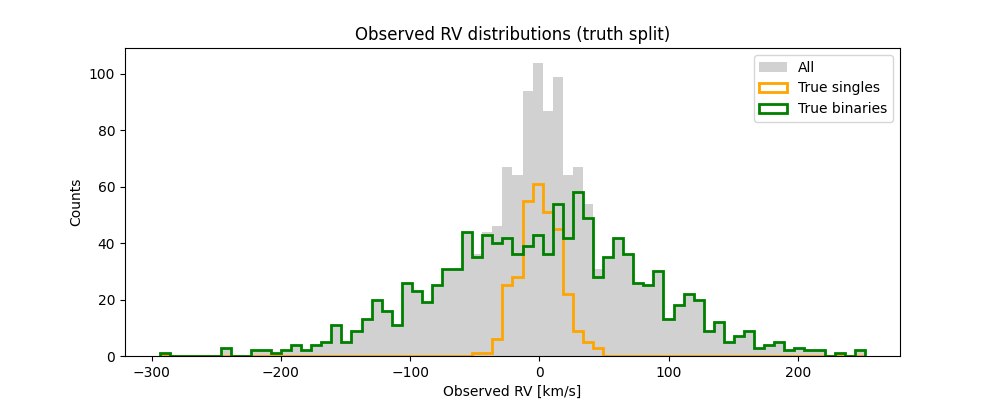

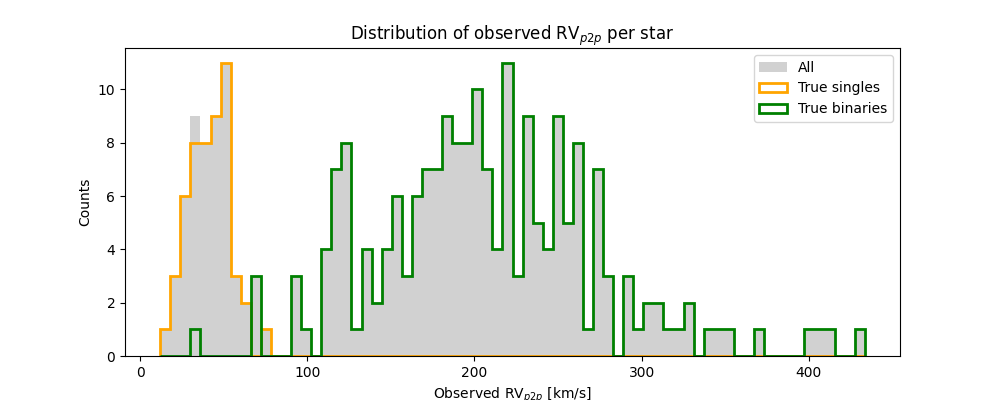

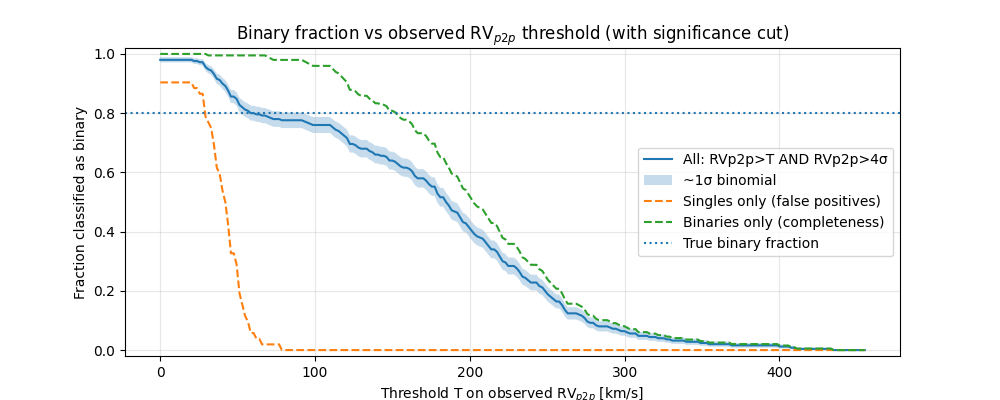

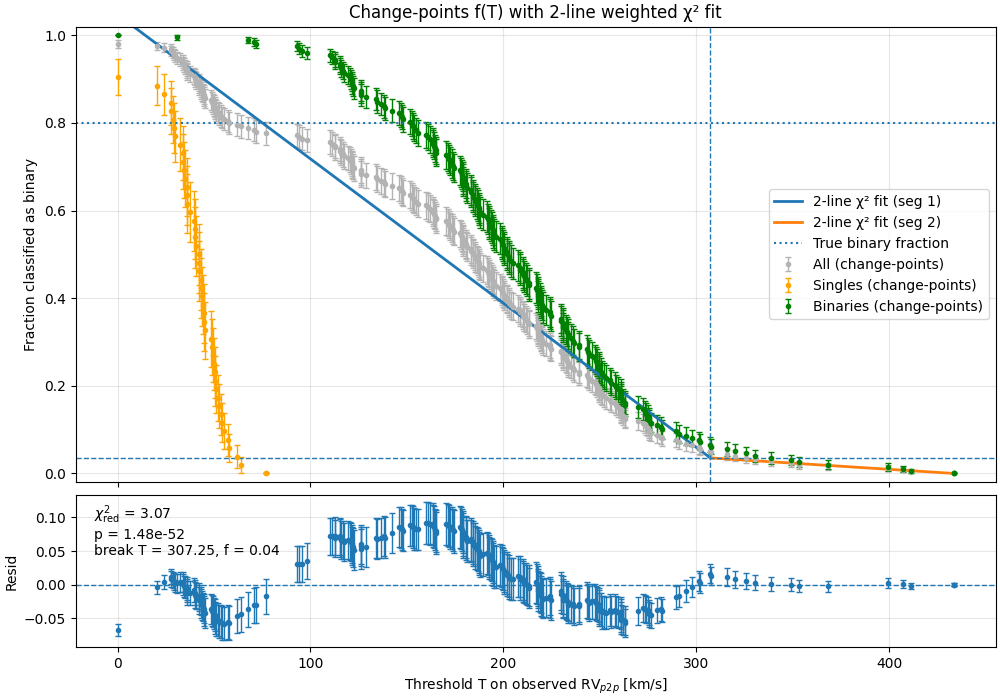

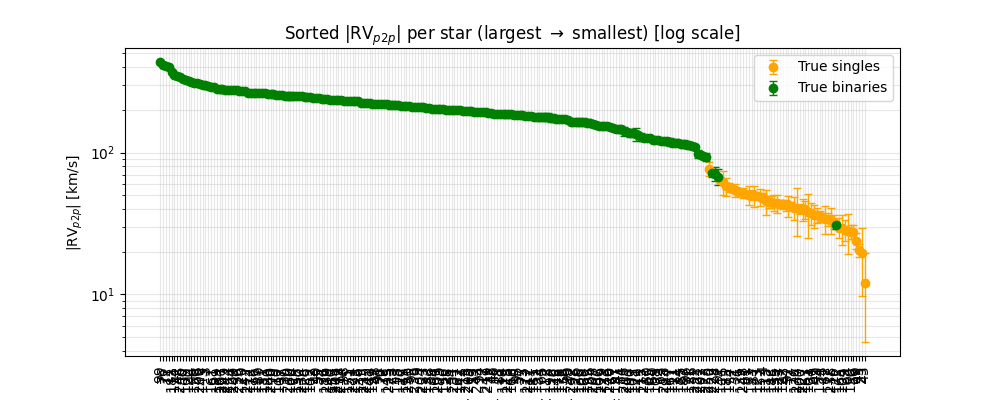

True binaries: 198 / 250 = 0.792
Fraction passing 4σ variability cut (T=0): 0.980
2-line fit: chi2=746.22, chi2_red=3.07, p=1.48e-52, break T=307.25, f=0.04


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2  # for p-value

# ============================================================
# SETTINGS (your defaults)
# ============================================================
single_dist = "gaussian"
binary_dist = "gaussian"

# Population
Nstars = 250
Nobs = 6
f_true_bin = 0.8
seed = 41

# Per-epoch uncertainty model: sigma_RV ~ |N(0,6)|
sigma_err_draw = 4.5   # km/s
sigma_floor = 0.0      # km/s
nsigma_detect = 4.0    # detection criterion: RVp2p - nsigma*sigma_p2p > 0

# True RV distributions
mu_single = 0.0
sigma_single = 15.0

mu_bin = 0.0
sigma_bin = 80.0

# Plot settings
bins_rv = 70
bins_p2p = 70
n_thr = 250

# Colors (as requested)
COL_ALL = "0.7"      # gray
COL_SINGLE = "orange"
COL_BIN = "green"


# ============================================================
# Helpers
# ============================================================
def draw_rvs(rng, n_rows, n_cols, dist, mu=0.0, sigma=1.0, low=-1.0, high=1.0):
    dist = dist.lower()
    if dist == "gaussian":
        return rng.normal(loc=mu, scale=sigma, size=(n_rows, n_cols))
    if dist == "uniform":
        return rng.uniform(low=low, high=high, size=(n_rows, n_cols))
    raise ValueError(f"Unknown dist='{dist}'. Use 'gaussian' or 'uniform'.")

def p2p_and_err(rvs_obs, rv_sigma):
    """
    RVp2p = |max - min| from observed RVs (always >= 0).
    Error propagation uses the two chosen points (epochs of max and min):
        sigma_p2p = sqrt(sigma_max^2 + sigma_min^2)
    """
    N = rvs_obs.shape[0]
    idx_max = np.argmax(rvs_obs, axis=1)
    idx_min = np.argmin(rvs_obs, axis=1)

    p2p = np.abs(rvs_obs[np.arange(N), idx_max] - rvs_obs[np.arange(N), idx_min])
    p2p_err = np.sqrt(
        rv_sigma[np.arange(N), idx_max]**2 + rv_sigma[np.arange(N), idx_min]**2
    )
    return p2p, p2p_err

def f_detected_vs_threshold(rv_p2p, sig_mask, thresholds):
    """detected = (rv_p2p > T) & sig_mask"""
    return np.array([((rv_p2p > t) & sig_mask).mean() for t in thresholds])

def change_points_curve(rv_p2p_subset, sig_mask_subset, N_for_error):
    """
    Change-points ("start of every flat") for:
        f(T) = mean( (rv_p2p > T) & sig_mask )
    Steps only change at RVp2p values of objects that pass sig_mask.
    """
    if rv_p2p_subset.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([0.0])

    p2p_sig = rv_p2p_subset[sig_mask_subset]
    if p2p_sig.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([0.0])

    u = np.sort(np.unique(p2p_sig))
    T = np.concatenate(([0.0], np.nextafter(u, np.inf), [np.nextafter(u[-1], np.inf)]))

    f = np.array([((rv_p2p_subset > t) & sig_mask_subset).mean() for t in T])
    ferr = np.sqrt(f * (1 - f) / N_for_error) if N_for_error > 0 else np.zeros_like(f)
    return T, f, ferr

def fit_two_lines_weighted(x, y, yerr, min_points_each_side=3):
    """
    Continuous 2-line (piecewise linear) model by grid-searching breakpoint x0.

    Parameterization:
        y = c + m1*x + d*max(0, x - x0)
    where for x<=x0: slope=m1, for x>=x0: slope=m2=m1+d
    """
    x = np.asarray(x)
    y = np.asarray(y)
    yerr = np.asarray(yerr)

    # avoid zero uncertainties for weights (binomial errs can be 0 at f=0 or f=1)
    err_floor = 1.0 / (2.0 * max(1, Nstars))
    yerr_fit = np.maximum(yerr, err_floor)

    x_unique = np.unique(x)
    if x_unique.size < (2 * min_points_each_side + 1):
        raise RuntimeError("Not enough distinct x points to fit two segments robustly.")

    candidates = x_unique[1:-1]

    best = None
    best_chi2 = np.inf

    for x0 in candidates:
        left = x <= x0
        right = x > x0
        if left.sum() < min_points_each_side or right.sum() < min_points_each_side:
            continue

        h = np.maximum(0.0, x - x0)
        A = np.column_stack([np.ones_like(x), x, h])  # params: [c, m1, d]

        w = 1.0 / yerr_fit
        Aw = A * w[:, None]
        yw = y * w

        beta, *_ = np.linalg.lstsq(Aw, yw, rcond=None)
        yhat = A @ beta
        chi2_val = np.sum(((y - yhat) / yerr_fit) ** 2)

        if chi2_val < best_chi2:
            best_chi2 = chi2_val
            best = (x0, beta[0], beta[1], beta[2], yhat, yerr_fit)

    if best is None:
        raise RuntimeError("No valid breakpoint candidate satisfied min_points_each_side.")

    x0, c, m1, d, yhat, yerr_fit = best
    n_params_effective = 4  # c,m1,d plus breakpoint x0
    dof = max(1, len(x) - n_params_effective)
    chi2_red = best_chi2 / dof
    pval = chi2.sf(best_chi2, dof)

    return x0, c, m1, d, best_chi2, chi2_red, pval, yhat, yerr_fit


# ============================================================
# Simulate TRUE RVs
# ============================================================
rng = np.random.default_rng(seed)

is_bin = rng.random(Nstars) < f_true_bin
is_single = ~is_bin

rvs_true = np.empty((Nstars, Nobs), dtype=float)

rvs_true[is_single] = draw_rvs(
    rng, is_single.sum(), Nobs,
    dist=single_dist, mu=mu_single, sigma=sigma_single
)

rvs_true[is_bin] = draw_rvs(
    rng, is_bin.sum(), Nobs,
    dist=binary_dist, mu=mu_bin, sigma=sigma_bin
)

# ============================================================
# Per-epoch RV uncertainties + heteroscedastic noise
# ============================================================
rv_sigma = np.abs(rng.normal(loc=0.0, scale=sigma_err_draw, size=rvs_true.shape))
if sigma_floor > 0:
    rv_sigma = np.maximum(rv_sigma, sigma_floor)

noise = rng.normal(loc=0.0, scale=rv_sigma)
rvs_obs = rvs_true + noise

# ============================================================
# Observables + detection masks
# ============================================================
all_rvs_obs = rvs_obs.ravel()

rv_p2p_obs, rv_p2p_err = p2p_and_err(rvs_obs, rv_sigma)

# significance criterion: RVp2p - nsigma*sigma_p2p > 0
sig_mask_all = (rv_p2p_obs - nsigma_detect * rv_p2p_err) > 0
sig_mask_single = sig_mask_all[is_single]
sig_mask_bin = sig_mask_all[is_bin]

# Threshold grid for smooth plot
thr_min = 0.0
thr_max = rv_p2p_obs.max() * 1.05
thresholds = np.linspace(thr_min, thr_max, n_thr)

# Fractions vs threshold using BOTH criteria:
f_obs = f_detected_vs_threshold(rv_p2p_obs, sig_mask_all, thresholds)
f_obs_err = np.sqrt(f_obs * (1 - f_obs) / Nstars)

f_single = f_detected_vs_threshold(rv_p2p_obs[is_single], sig_mask_single, thresholds) if is_single.any() else np.zeros_like(thresholds)
f_bin_only = f_detected_vs_threshold(rv_p2p_obs[is_bin], sig_mask_bin, thresholds) if is_bin.any() else np.zeros_like(thresholds)

# Change-points curves
T_all, f_all_cp, e_all_cp = change_points_curve(rv_p2p_obs, sig_mask_all, Nstars)
T_s,   f_s_cp,   e_s_cp   = change_points_curve(rv_p2p_obs[is_single], sig_mask_single, is_single.sum())
T_b,   f_b_cp,   e_b_cp   = change_points_curve(rv_p2p_obs[is_bin], sig_mask_bin, is_bin.sum())

# ============================================================
# Plot 1: Observed RV histogram (NOW split like plot 2)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 4))

all_vals = all_rvs_obs
bin_edges = np.histogram_bin_edges(all_vals, bins=bins_rv)  # edges set by ALL data

ax1.hist(all_vals, bins=bin_edges, alpha=0.6, color=COL_ALL, label="All")
ax1.hist(rvs_obs[is_single].ravel(), bins=bin_edges, histtype="step", linewidth=2,
         color=COL_SINGLE, label="True singles")
ax1.hist(rvs_obs[is_bin].ravel(), bins=bin_edges, histtype="step", linewidth=2,
         color=COL_BIN, label="True binaries")

ax1.set_title("Observed RV distributions (truth split)")
ax1.set_xlabel("Observed RV [km/s]")
ax1.set_ylabel("Counts")
ax1.legend()
plt.show()


# ============================================================
# Plot 2: Observed RVp2p histogram (truth split; colored)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(10, 4))
all_p2p = rv_p2p_obs
bin_edges_p2p = np.histogram_bin_edges(all_p2p, bins=bins_p2p)  # edges set by ALL data

ax2.hist(all_p2p, bins=bin_edges_p2p, alpha=0.6, color=COL_ALL, label="All")

if is_single.any():
    ax2.hist(rv_p2p_obs[is_single], bins=bin_edges_p2p, histtype="step", linewidth=2,
             color=COL_SINGLE, label="True singles")
if is_bin.any():
    ax2.hist(rv_p2p_obs[is_bin], bins=bin_edges_p2p, histtype="step", linewidth=2,
             color=COL_BIN, label="True binaries")

ax2.set_title("Distribution of observed RV$_{p2p}$ per star")
ax2.set_xlabel("Observed RV$_{p2p}$ [km/s]")
ax2.set_ylabel("Counts")
ax2.legend()
plt.show()

# ============================================================
# Plot 3: Binary fraction vs threshold (smooth)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(thresholds, f_obs, label=f"All: RVp2p>T AND RVp2p>{nsigma_detect:g}σ")
ax3.fill_between(thresholds, f_obs - f_obs_err, f_obs + f_obs_err, alpha=0.25, label="~1σ binomial")
ax3.plot(thresholds, f_single, linestyle="--", label="Singles only (false positives)")
ax3.plot(thresholds, f_bin_only, linestyle="--", label="Binaries only (completeness)")
ax3.axhline(f_true_bin, linestyle=":", label="True binary fraction")
ax3.set_title("Binary fraction vs observed RV$_{p2p}$ threshold (with significance cut)")
ax3.set_xlabel("Threshold T on observed RV$_{p2p}$ [km/s]")
ax3.set_ylabel("Fraction classified as binary")
ax3.set_ylim(-0.02, 1.02)
ax3.grid(True, alpha=0.3)
ax3.legend()
plt.show()

# ============================================================
# Plot 4: Change-points + 2-line chi^2 fit + residuals (WITH error bars)
# ============================================================
x_fit = T_all
y_fit = f_all_cp
yerr_fit = e_all_cp

x0, c, m1, d, chi2_val, chi2_red, pval, yhat, yerr_fit_used = fit_two_lines_weighted(
    x_fit, y_fit, yerr_fit, min_points_each_side=3
)

y0 = c + m1 * x0

x_left = np.linspace(x_fit.min(), x0, 200)
y_left = c + m1 * x_left

m2 = m1 + d
c2 = c - d * x0
x_right = np.linspace(x0, x_fit.max(), 200)
y_right = c2 + m2 * x_right

# residuals in fraction units + error bars
resid = y_fit - yhat
resid_err = yerr_fit_used

fig4, (ax4, ax4r) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True
)

# Top panel
ax4.errorbar(x_fit, y_fit, yerr=yerr_fit, fmt="o", markersize=3, capsize=2, elinewidth=1,
             color=COL_ALL, label="All (change-points)")
ax4.errorbar(T_s, f_s_cp, yerr=e_s_cp, fmt="o", markersize=3, capsize=2, elinewidth=1,
             color=COL_SINGLE, label="Singles (change-points)")
ax4.errorbar(T_b, f_b_cp, yerr=e_b_cp, fmt="o", markersize=3, capsize=2, elinewidth=1,
             color=COL_BIN, label="Binaries (change-points)")

ax4.plot(x_left, y_left, linewidth=2, label="2-line χ² fit (seg 1)")
ax4.plot(x_right, y_right, linewidth=2, label="2-line χ² fit (seg 2)")

ax4.axvline(x0, linestyle="--", linewidth=1)
ax4.axhline(y0, linestyle="--", linewidth=1)
ax4.axhline(f_true_bin, linestyle=":", label="True binary fraction")

ax4.set_title("Change-points f(T) with 2-line weighted χ² fit")
ax4.set_ylabel("Fraction classified as binary")
ax4.set_ylim(-0.02, 1.02)
ax4.grid(True, alpha=0.3)
ax4.legend()

# Residuals panel (NOW with error bars)
ax4r.axhline(0.0, linestyle="--", linewidth=1)
ax4r.errorbar(x_fit, resid, yerr=resid_err, fmt="o", markersize=3, capsize=2, elinewidth=1)
ax4r.set_xlabel("Threshold T on observed RV$_{p2p}$ [km/s]")
ax4r.set_ylabel("Resid")
ax4r.grid(True, alpha=0.3)

txt = (
    r"$\chi^2_{\rm red}$" + f" = {chi2_red:.2f}\n"
    + f"p = {pval:.3g}\n"
    + f"break T = {x0:.2f}, f = {y0:.2f}"
)
ax4r.text(0.02, 0.95, txt, transform=ax4r.transAxes, va="top")
plt.show()

# ============================================================
# Plot 5: Sorted |RVp2p| per star (log y-scale) with error bars (NOW colored)
# ============================================================
order = np.argsort(rv_p2p_obs)[::-1]
rvp_sorted = rv_p2p_obs[order]
ervp_sorted = rv_p2p_err[order]
star_ids_sorted = order + 1
x = np.arange(1, Nstars + 1)

# split indices in sorted-rank space
truth_sorted = is_bin[order]  # True where binary
idx_bin_rank = np.where(truth_sorted)[0]
idx_single_rank = np.where(~truth_sorted)[0]

fig5, ax5 = plt.subplots(figsize=(10, 4))

# Singles (orange)
ax5.errorbar(
    x[idx_single_rank], rvp_sorted[idx_single_rank], yerr=ervp_sorted[idx_single_rank],
    fmt="o", capsize=3, elinewidth=1, color=COL_SINGLE, label="True singles"
)

# Binaries (green)
ax5.errorbar(
    x[idx_bin_rank], rvp_sorted[idx_bin_rank], yerr=ervp_sorted[idx_bin_rank],
    fmt="o", capsize=3, elinewidth=1, color=COL_BIN, label="True binaries"
)

ax5.set_yscale("log")
ax5.set_title(r"Sorted |RV$_{p2p}$| per star (largest $\rightarrow$ smallest) [log scale]")
ax5.set_ylabel(r"|RV$_{p2p}$| [km/s]")
ax5.grid(True, alpha=0.3, which="both")

ax5.set_xticks(x)
ax5.set_xticklabels(star_ids_sorted, rotation=90)
ax5.set_xlabel("Star number (sorted by |RV$_{p2p}$|)")
ax5.legend()
plt.show()

# ============================================================
# Quick summary
# ============================================================
print(f"True binaries: {is_bin.sum()} / {Nstars} = {is_bin.mean():.3f}")
print(f"Fraction passing {nsigma_detect:g}σ variability cut (T=0): {sig_mask_all.mean():.3f}")
print(f"2-line fit: chi2={chi2_val:.2f}, chi2_red={chi2_red:.2f}, p={pval:.3g}, break T={x0:.2f}, f={y0:.2f}")


## Simulation using statistics of real data

In [5]:
# ============================================================
# Real-RV-driven population simulation (per emission line) — UPDATED
#   - RV draw sigma = std(RVs)
#   - Errors drawn from error-model only
#   - Plot 1/2 show ONE simulated population (counts comparable)
#   - Plot 4/5 use ALL simulated stars (Nmc_pop*Nstars_sim). Set Nmc_pop=1 for single survey.
#   - Plot 5 threshold = break from Plot 4 two-line fit
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy.stats import chi2  # p-value for chi^2 fit


# ============================================================
# SETTINGS
# ============================================================
Nstars_sim = 25     # survey size to simulate
Nobs_sim   = 6      # epochs per simulated star
Nmc_pop    = 1   # Monte-Carlo surveys for uncertainty band (f(T))
seed       = 42

nsigma_detect = 4.0

bins_rv  = 70
bins_p2p = 70
n_thr    = 250

SETTINGS_PATH = "ccf_settings_with_global_lines.json"  # adjust if needed


# ============================================================
# Load JSON
# ============================================================
with open(SETTINGS_PATH, "r") as f:
    SETTINGS = json.load(f)

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS["emission_lines_default"]
LINE_KEYS = list(LINES_DEFAULT.keys())

KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")


def is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    if ep in set(cfg.get("skip_epochs", [])):
        return True
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)):
            skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps:
            return True
    return False


def extract_full_rv(cell):
    try:
        if isinstance(cell, dict):
            return cell.get("full_RV", None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                return v.get("full_RV", None)
        if hasattr(cell, "get"):
            return cell.get("full_RV", None)
    except Exception:
        pass
    return None


def extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None:
                    return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None:
                        return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None:
                    return float(val)
    except Exception:
        pass
    return np.nan


# ============================================================
# Cache RVs: RV_CACHE[line][star] -> {"rvs": array, "errs": array}
# ============================================================
def build_rv_cache():
    stars = {sname: obs.load_star_instance(sname, to_print=False) for sname in specs.star_names}
    data = {lk: {sname: {"rvs": [], "errs": []} for sname in specs.star_names} for lk in LINE_KEYS}

    for sname, star in stars.items():
        try:
            epochs = list(star.get_all_epoch_numbers())
        except Exception:
            epochs = list(range(1, Nobs_sim + 1))

        for ep in epochs:
            try:
                RVs = star.load_property("RVs", ep, "COMBINED")
            except Exception:
                RVs = None
            if not RVs:
                continue

            for lk in LINE_KEYS:
                if is_epoch_skipped_for_line(sname, lk, ep):
                    continue
                if lk not in RVs:
                    continue

                cell = RVs[lk]
                rv = extract_full_rv(cell)
                if rv is None:
                    continue
                try:
                    rv = float(rv)
                except Exception:
                    continue

                err = extract_full_rv_err(cell)
                err = float(err) if np.isfinite(err) else np.nan

                data[lk][sname]["rvs"].append(rv)
                data[lk][sname]["errs"].append(err)

    for lk in LINE_KEYS:
        for sname in specs.star_names:
            data[lk][sname]["rvs"]  = np.asarray(data[lk][sname]["rvs"], dtype=float)
            data[lk][sname]["errs"] = np.asarray(data[lk][sname]["errs"], dtype=float)

    return data

RV_CACHE = build_rv_cache()


# ============================================================
# Build per-star model for a line:
#   mu_rv = mean(RVs), sigma_rv = std(RVs, ddof=1)
#   error model: mu_err = mean(errs), sd_err = std(errs, ddof=1)
# ============================================================
def build_star_models_for_line(line_key):
    rows = []

    for sname in specs.star_names:
        rvs = RV_CACHE[line_key][sname]["rvs"]
        ers = RV_CACHE[line_key][sname]["errs"]

        rvs_f = rvs[np.isfinite(rvs)]
        ers_f = ers[np.isfinite(ers)]

        n_rv = int(rvs_f.size)
        n_er = int(ers_f.size)

        if n_rv < 2:
            rows.append(dict(
                Star=sname, n_rv=n_rv, n_er=n_er,
                mu_rv=np.nan, sigma_rv=np.nan,
                mu_err=np.nan, sd_err=np.nan,
                p2p=np.nan, p2p_err=np.nan
            ))
            continue

        mu_rv = float(np.mean(rvs_f))
        sigma_rv = float(np.std(rvs_f, ddof=1))

        if n_er >= 1:
            mu_err = float(np.mean(ers_f))
            sd_err = float(np.std(ers_f, ddof=1)) if n_er > 1 else 0.0
        else:
            mu_err = np.nan
            sd_err = np.nan

        # observed p2p and p2p_err (from extrema errors)
        i_max = int(np.argmax(rvs_f))
        i_min = int(np.argmin(rvs_f))
        p2p = float(np.abs(rvs_f[i_max] - rvs_f[i_min]))

        ers_aligned = ers[np.isfinite(rvs)]
        err_max = ers_aligned[i_max] if ers_aligned.size > i_max else np.nan
        err_min = ers_aligned[i_min] if ers_aligned.size > i_min else np.nan
        p2p_err = float(np.sqrt(err_max**2 + err_min**2)) if (np.isfinite(err_max) and np.isfinite(err_min)) else np.nan

        rows.append(dict(
            Star=sname, n_rv=n_rv, n_er=n_er,
            mu_rv=mu_rv, sigma_rv=sigma_rv,
            mu_err=mu_err, sd_err=sd_err,
            p2p=p2p, p2p_err=p2p_err
        ))

    return pd.DataFrame(rows)


# ============================================================
# Detection: (p2p > T) AND (p2p - nsigma*p2p_err > 0)
# ============================================================
def detected_mask(p2p, p2p_err, T, nsigma=4.0):
    p2p = np.asarray(p2p, float)
    p2p_err = np.asarray(p2p_err, float)
    ok = np.isfinite(p2p) & np.isfinite(p2p_err)
    sig_ok = np.zeros_like(p2p, dtype=bool)
    sig_ok[ok] = (p2p[ok] - nsigma * p2p_err[ok]) > 0
    return (p2p > T) & sig_ok


def change_points_f(p2p, p2p_err, nsigma=4.0):
    p2p = np.asarray(p2p, float)
    p2p_err = np.asarray(p2p_err, float)
    ok = np.isfinite(p2p) & np.isfinite(p2p_err)
    p2p = p2p[ok]
    p2p_err = p2p_err[ok]
    if p2p.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([0.0])

    sig_mask = (p2p - nsigma * p2p_err) > 0
    p2p_sig = p2p[sig_mask]
    if p2p_sig.size == 0:
        return np.array([0.0]), np.array([0.0]), np.array([0.0])

    u = np.sort(np.unique(p2p_sig))
    T = np.concatenate(([0.0], np.nextafter(u, np.inf), [np.nextafter(u[-1], np.inf)]))
    N = p2p.size
    f = np.array([detected_mask(p2p, p2p_err, t, nsigma).mean() for t in T])
    ferr = np.sqrt(f * (1 - f) / max(1, N))
    return T, f, ferr


def fit_two_lines_weighted(x, y, yerr, min_points_each_side=3):
    x = np.asarray(x); y = np.asarray(y); yerr = np.asarray(yerr)

    # avoid zero weights
    err_floor = 1.0 / (2.0 * max(1, len(y)))
    yerr_fit = np.maximum(yerr, err_floor)

    x_unique = np.unique(x)
    candidates = x_unique[1:-1]  # interior
    best = None
    best_chi2 = np.inf

    for x0 in candidates:
        left = x <= x0
        right = x > x0
        if left.sum() < min_points_each_side or right.sum() < min_points_each_side:
            continue

        h = np.maximum(0.0, x - x0)
        A = np.column_stack([np.ones_like(x), x, h])  # c, m1, d

        w = 1.0 / yerr_fit
        Aw = A * w[:, None]
        yw = y * w

        beta, *_ = np.linalg.lstsq(Aw, yw, rcond=None)
        yhat = A @ beta
        chi2_val = np.sum(((y - yhat) / yerr_fit) ** 2)

        if chi2_val < best_chi2:
            best_chi2 = chi2_val
            best = (x0, beta[0], beta[1], beta[2], yhat, yerr_fit)

    if best is None:
        return None

    x0, c, m1, d, yhat, yerr_fit = best
    dof = max(1, len(x) - 4)  # c,m1,d plus x0
    chi2_red = best_chi2 / dof
    pval = chi2.sf(best_chi2, dof)

    return dict(x0=x0, c=c, m1=m1, d=d, yhat=yhat, yerr=yerr_fit,
                chi2=best_chi2, dof=dof, chi2_red=chi2_red, pval=pval)


# ============================================================
# Simulation
# ============================================================
def simulate_population_from_models(df_models):
    rng = np.random.default_rng(seed)

    m = (
        np.isfinite(df_models["mu_rv"]) &
        np.isfinite(df_models["sigma_rv"]) &
        np.isfinite(df_models["mu_err"]) &
        np.isfinite(df_models["sd_err"])
    )
    models = df_models.loc[m].copy().reset_index(drop=True)
    n_models = len(models)
    if n_models == 0:
        return None, "No usable star-models for this line (need >=2 RVs + finite errors)."

    # real usable p2p
    m_obs = np.isfinite(df_models["p2p"]) & np.isfinite(df_models["p2p_err"])
    p2p_obs = df_models.loc[m_obs, "p2p"].values.astype(float)
    p2p_err_obs = df_models.loc[m_obs, "p2p_err"].values.astype(float)

    thr_max = float(np.nanmax(p2p_obs) * 1.05) if p2p_obs.size else 100.0
    thr = np.linspace(0.0, thr_max, n_thr)

    replace = Nstars_sim > n_models
    idx = np.vstack([rng.choice(n_models, size=Nstars_sim, replace=replace) for _ in range(Nmc_pop)])

    mu_rv  = models["mu_rv"].values[idx]
    sig_rv = models["sigma_rv"].values[idx]
    mu_er  = models["mu_err"].values[idx]
    sd_er  = models["sd_err"].values[idx]

    # errors per epoch
    err_epoch = np.abs(rng.normal(loc=mu_er[..., None], scale=sd_er[..., None], size=(Nmc_pop, Nstars_sim, Nobs_sim)))

    # RVs per epoch
    rv = rng.normal(loc=mu_rv[..., None], scale=sig_rv[..., None], size=(Nmc_pop, Nstars_sim, Nobs_sim))

    # p2p
    idx_max = np.argmax(rv, axis=2)
    idx_min = np.argmin(rv, axis=2)

    rv_max = np.take_along_axis(rv, idx_max[..., None], axis=2)[..., 0]
    rv_min = np.take_along_axis(rv, idx_min[..., None], axis=2)[..., 0]
    p2p_sim = np.abs(rv_max - rv_min)

    er_max = np.take_along_axis(err_epoch, idx_max[..., None], axis=2)[..., 0]
    er_min = np.take_along_axis(err_epoch, idx_min[..., None], axis=2)[..., 0]
    p2p_err_sim = np.sqrt(er_max**2 + er_min**2)

    sig_ok = (p2p_sim - nsigma_detect * p2p_err_sim) > 0
    det = sig_ok[..., None] & (p2p_sim[..., None] > thr[None, None, :])
    frac = det.mean(axis=1)

    frac_mean = np.mean(frac, axis=0)
    frac_p16, frac_p84 = np.percentile(frac, [16, 84], axis=0)

    # ONE simulated survey (for hist counts comparable)
    rv_one = rv[0].reshape(-1)          # Nstars*Nobs points
    p2p_one = p2p_sim[0]                # Nstars points
    p2p_err_one = p2p_err_sim[0]
    idx_one = idx[0]

    # ALL simulated stars across all MC surveys (for plots 4/5)
    p2p_all = p2p_sim.reshape(-1)
    p2p_err_all = p2p_err_sim.reshape(-1)
    model_used_all = models["Star"].values[idx].reshape(-1)

    return dict(
        models=models,
        thr=thr,
        frac_mean=frac_mean, frac_p16=frac_p16, frac_p84=frac_p84,
        rv_one=rv_one,
        p2p_one=p2p_one, p2p_err_one=p2p_err_one,
        idx_one=idx_one,
        p2p_all=p2p_all, p2p_err_all=p2p_err_all, model_used_all=model_used_all,
        p2p_obs=p2p_obs, p2p_err_obs=p2p_err_obs
    ), None


# ============================================================
# UI
# ============================================================
line_selector = widgets.ToggleButtons(
    options=LINE_KEYS,
    description="Emission line:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="100%", flex_flow="row wrap")
)

out = widgets.Output()

def render(line_key):
    with out:
        clear_output(wait=True)

        df_models = build_star_models_for_line(line_key)
        sim, err = simulate_population_from_models(df_models)

        show_cols = ["Star", "n_rv", "n_er", "mu_rv", "sigma_rv", "mu_err", "sd_err", "p2p", "p2p_err"]
        display(df_models[show_cols].sort_values("p2p", ascending=False, na_position="last").reset_index(drop=True))

        if err is not None:
            print(err)
            return

        # ----------------------------
        # Plot 1: RV distribution (ONE sim survey vs real RV points)
        # ----------------------------
        real_rv_points = []
        for sname in specs.star_names:
            r = RV_CACHE[line_key][sname]["rvs"]
            if r.size:
                real_rv_points.append(r[np.isfinite(r)])
        real_rv_points = np.concatenate(real_rv_points) if len(real_rv_points) else np.array([])

        fig1, ax1 = plt.subplots(figsize=(10, 4))
        combo = sim["rv_one"] if real_rv_points.size == 0 else np.concatenate([sim["rv_one"], real_rv_points])
        edges = np.histogram_bin_edges(combo, bins=bins_rv)

        ax1.hist(sim["rv_one"], bins=edges, alpha=0.6, label=f"Sim (one survey: Nstars={Nstars_sim}, Nobs={Nobs_sim})")
        if real_rv_points.size:
            ax1.hist(real_rv_points, bins=edges, histtype="step", linewidth=2, label="Real RV points")

        ax1.set_title(f"RV distribution — {line_key}")
        ax1.set_xlabel("RV [km/s]")
        ax1.set_ylabel("Counts (epochs)")
        ax1.grid(True, alpha=0.25)
        ax1.legend()
        plt.show()

        # ----------------------------
        # Plot 2: RVp2p distribution (ONE sim survey vs real p2p)
        # ----------------------------
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        p2p_sim1 = sim["p2p_one"]
        combo2 = p2p_sim1 if sim["p2p_obs"].size == 0 else np.concatenate([p2p_sim1, sim["p2p_obs"]])
        edges2 = np.histogram_bin_edges(combo2, bins=bins_p2p)

        ax2.hist(p2p_sim1, bins=edges2, alpha=0.6, label=f"Sim (one survey: Nstars={Nstars_sim})")
        if sim["p2p_obs"].size:
            ax2.hist(sim["p2p_obs"], bins=edges2, histtype="step", linewidth=2, label="Real RVp2p (usable)")

        ax2.set_title(f"|RVp2p| distribution — {line_key}")
        ax2.set_xlabel(r"|RV$_{p2p}$| [km/s]")
        ax2.set_ylabel("Counts (stars)")
        ax2.grid(True, alpha=0.25)
        ax2.legend()
        plt.show()

        # ----------------------------
        # Plot 3: Detected fraction vs threshold (MC band + real curve)
        # ----------------------------
        thr = sim["thr"]

        fig3, ax3 = plt.subplots(figsize=(10, 4))
        ax3.fill_between(thr, sim["frac_p16"], sim["frac_p84"], alpha=0.25, label=f"Sim 16–84% band (Nmc={Nmc_pop})")
        ax3.plot(thr, sim["frac_mean"], linewidth=2, label="Sim mean")

        if sim["p2p_obs"].size:
            f_real = np.array([detected_mask(sim["p2p_obs"], sim["p2p_err_obs"], t, nsigma_detect).mean() for t in thr])
            f_real_err = np.sqrt(f_real * (1 - f_real) / max(1, sim["p2p_obs"].size))
            ax3.plot(thr, f_real, label="Real f_det(T)")
            ax3.fill_between(thr, f_real - f_real_err, f_real + f_real_err, alpha=0.2, label="~1σ binomial (real)")

        ax3.set_title(f"Detected fraction vs threshold — {line_key}\n(det: RVp2p>T AND RVp2p-4σ_p2p>0)")
        ax3.set_xlabel("Threshold T on |RVp2p| [km/s]")
        ax3.set_ylabel("Detected fraction")
        ax3.set_ylim(-0.02, 1.02)
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        plt.show()

        # ----------------------------
        # Plot 4: Change-points + 2-line chi^2 fit + residuals (ALL simulated stars)
        # ----------------------------
        T_cp, f_cp, e_cp = change_points_f(sim["p2p_all"], sim["p2p_err_all"], nsigma_detect)
        fit = fit_two_lines_weighted(T_cp, f_cp, e_cp, min_points_each_side=3) if len(T_cp) >= 7 else None

        if fit is None:
            fig4, ax4 = plt.subplots(figsize=(10, 4))
            ax4.errorbar(T_cp, f_cp, yerr=e_cp, fmt="o", capsize=2)
            ax4.set_title(f"SIM change-points of f(T) — {line_key}")
            ax4.set_xlabel("T [km/s]")
            ax4.set_ylabel("Detected fraction")
            ax4.set_ylim(-0.02, 1.02)
            ax4.grid(True, alpha=0.3)
            plt.show()
        else:
            x0, c, m1, d = fit["x0"], fit["c"], fit["m1"], fit["d"]
            y0 = c + m1 * x0
            m2 = m1 + d
            c2 = c - d * x0

            x_left = np.linspace(T_cp.min(), x0, 200)
            y_left = c + m1 * x_left
            x_right = np.linspace(x0, T_cp.max(), 200)
            y_right = c2 + m2 * x_right

            resid = f_cp - fit["yhat"]
            resid_err = fit["yerr"]

            fig4, (ax4, ax4r) = plt.subplots(
                2, 1, figsize=(10, 7), sharex=True,
                gridspec_kw={"height_ratios": [3, 1]},
                constrained_layout=True
            )

            ax4.errorbar(T_cp, f_cp, yerr=e_cp, fmt="o", capsize=2, label="Change-points (SIM all)")
            ax4.plot(x_left, y_left, linewidth=2, label="2-line fit (seg 1)")
            ax4.plot(x_right, y_right, linewidth=2, label="2-line fit (seg 2)")

            ax4.axvline(x0, linestyle="--", linewidth=1)
            ax4.axhline(y0, linestyle="--", linewidth=1)

            ax4.set_title(f"SIM change-points f(T) + 2-line weighted χ² fit — {line_key}")
            ax4.set_ylabel("Detected fraction")
            ax4.set_ylim(-0.02, 1.02)
            ax4.grid(True, alpha=0.3)
            ax4.legend()

            ax4r.axhline(0.0, linestyle="--", linewidth=1)
            ax4r.errorbar(T_cp, resid, yerr=resid_err, fmt="o", capsize=2)
            ax4r.set_xlabel("T [km/s]")
            ax4r.set_ylabel("Resid")
            ax4r.grid(True, alpha=0.3)

            txt = (
                r"$\chi^2_{\rm red}$" + f"={fit['chi2_red']:.2f}\n"
                + f"p={fit['pval']:.3g}\n"
                + f"break T={x0:.2f}, f={y0:.2f}"
            )
            ax4r.text(0.02, 0.95, txt, transform=ax4r.transAxes, va="top")
            plt.show()

        # ----------------------------
        # Plot 5: Sorted |ΔRV| like your example (ALL simulated stars),
        #         threshold = break from Plot 4
        # ----------------------------
        if (fit is not None) and np.isfinite(fit["x0"]):
            T_example = float(fit["x0"])
        else:
            T_example = 10.0  # fallback

        p2p = sim["p2p_all"]
        e   = sim["p2p_err_all"]
        lab = sim["model_used_all"]

        det = detected_mask(p2p, e, T_example, nsigma_detect)

        order = np.argsort(p2p)[::-1]
        p2p_s = p2p[order]
        e_s   = e[order]
        det_s = det[order]
        lab_s = lab[order]

        x = np.arange(len(p2p_s))

        fig5, ax5 = plt.subplots(figsize=(14, 6))

        ax5.plot(x, p2p_s, color="0.7", linewidth=2, zorder=1)

        ax5.errorbar(
            x[det_s], p2p_s[det_s], yerr=e_s[det_s],
            fmt="o", markersize=5, capsize=2,
            color="green", ecolor="green", elinewidth=1.2,
            linestyle="None", zorder=4
        )
        ax5.errorbar(
            x[~det_s], p2p_s[~det_s], yerr=e_s[~det_s],
            fmt="o", markersize=5, capsize=2,
            color="red", ecolor="red", elinewidth=1.2,
            linestyle="None", zorder=3
        )

        ax5.axhline(T_example, linestyle="--", linewidth=1.5, color="0.4")

        ax5.set_yscale("log")
        ax5.set_title(f"Peak-to-peak |ΔRV| for {line_key} (desc)", fontsize=16)
        ax5.set_xlabel("Stars (sorted)", fontsize=13)
        ax5.set_ylabel("|ΔRV| (km/s)", fontsize=13)
        ax5.grid(True, alpha=0.25, which="both")

        # show names only when Nmc_pop=1 (so it looks like your example)
        if Nmc_pop == 1:
            ax5.set_xticks(x)
            ax5.set_xticklabels(lab_s, rotation=45, ha="right")
        else:
            ax5.set_xticks([])

        plt.tight_layout()
        plt.show()


def _on_line_change(change):
    if change["name"] == "value":
        render(change["new"])

line_selector.observe(_on_line_change, names="value")

display(line_selector)
display(out)
render(line_selector.value)


ToggleButtons(description='Emission line:', layout=Layout(flex_flow='row wrap', width='100%'), options=('O V 3…

Output()

## Modeling f_bin(t) where t is RV threshold

Starting calculation on 11 cores (out of 12)...
Calculation complete in 7.60 seconds.


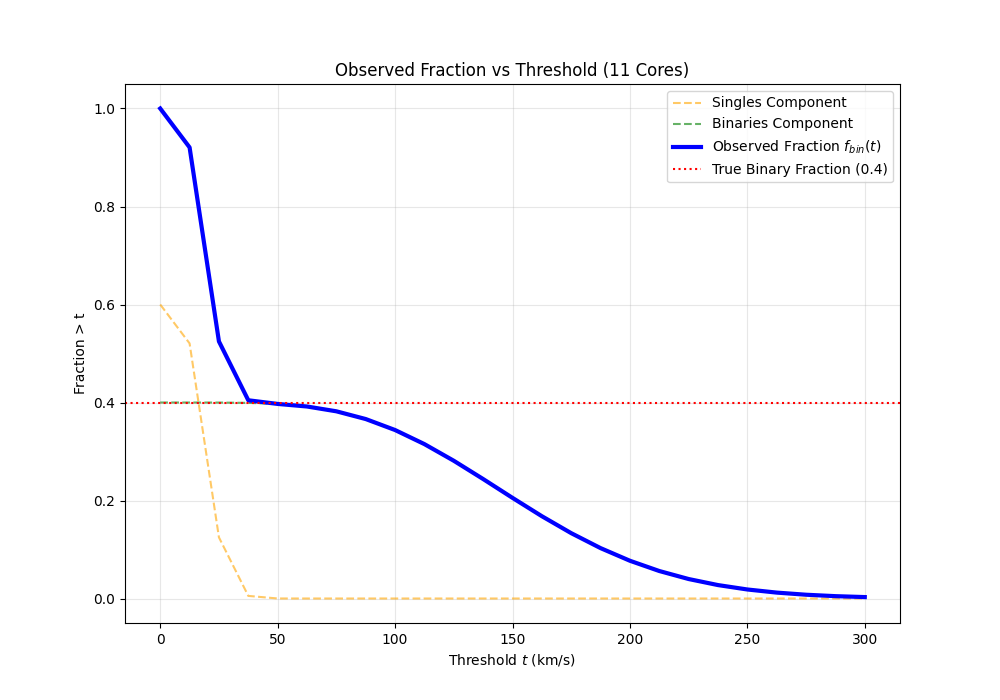

In [7]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from joblib import Parallel, delayed
import multiprocessing
import time

# --- 1. The Worker Function ---
# (Joblib handles the serialization, so this works even in Notebooks)
def calculate_survival_point(t, sigma, n):
    """
    Calculates P(Range > t) for a sample of size n.
    Returns: 1 - CDF(t)
    """
    # Inner integrand: PDF of range
    def pdf_integrand(z, w_val):
        w_norm = w_val / sigma
        return (norm.pdf(z) * norm.pdf(z + w_norm) * (norm.cdf(z + w_norm) - norm.cdf(z)) ** (n - 2))

    # Outer integrand: wrapper to integrate the PDF over z
    def outer_integrand(w):
        val, _ = quad(pdf_integrand, -np.inf, np.inf, args=(w,))
        return val

    # Integrate "unscaled PDF" from 0 to t to get CDF part
    integral_val, _ = quad(outer_integrand, 0, t)
    
    constant = n * (n - 1) / sigma
    cdf = constant * integral_val
    
    return max(0.0, min(1.0, 1 - cdf))

# --- 2. Main Execution Block ---
if __name__ == '__main__':
    # Parameters
    sigma_single = 7.8
    sigma_binary = 61.4
    f_true_binary = 0.4
    n_epochs = 6
    thresholds = np.linspace(0, 300, 25)

    # Detect cores and leave 1 free
    total_cores = multiprocessing.cpu_count()
    n_jobs = max(1, total_cores - 1)
    
    print(f"Starting calculation on {n_jobs} cores (out of {total_cores})...")
    start_time = time.time()

    # --- PARALLEL EXECUTION WITH JOBLIB ---
    # This replaces the entire Pool setup with a single readable line
    
    # 1. Calculate Singles
    results_single = Parallel(n_jobs=n_jobs)(
        delayed(calculate_survival_point)(t, sigma_single, n_epochs) for t in thresholds
    )
    
    # 2. Calculate Binaries
    results_binary = Parallel(n_jobs=n_jobs)(
        delayed(calculate_survival_point)(t, sigma_binary, n_epochs) for t in thresholds
    )

    end_time = time.time()
    print(f"Calculation complete in {end_time - start_time:.2f} seconds.")

    # Convert to arrays
    surv_single = np.array(results_single)
    surv_binary = np.array(results_binary)

    # Mixture Model
    f_obs_t = ( (1 - f_true_binary) * surv_single ) + ( f_true_binary * surv_binary )

    # --- 3. Plotting ---
    plt.figure(figsize=(10, 7))
    plt.plot(thresholds, surv_single * (1-f_true_binary), '--', color='orange', alpha=0.6, label='Singles Component')
    plt.plot(thresholds, surv_binary * f_true_binary, '--', color='green', alpha=0.6, label='Binaries Component')
    plt.plot(thresholds, f_obs_t, 'b-', lw=3, label=r'Observed Fraction $f_{bin}(t)$')
    plt.axhline(f_true_binary, color='red', linestyle=':', label=f'True Binary Fraction ({f_true_binary})')
    plt.title(f"Observed Fraction vs Threshold ({n_jobs} Cores)")
    plt.xlabel("Threshold $t$ (km/s)")
    plt.ylabel("Fraction > t")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## using the f_bin(t) data points to trace back the gaussian distributions of the single and binary stars to find the best t

Optimal Separating Threshold: 56.25 km/s


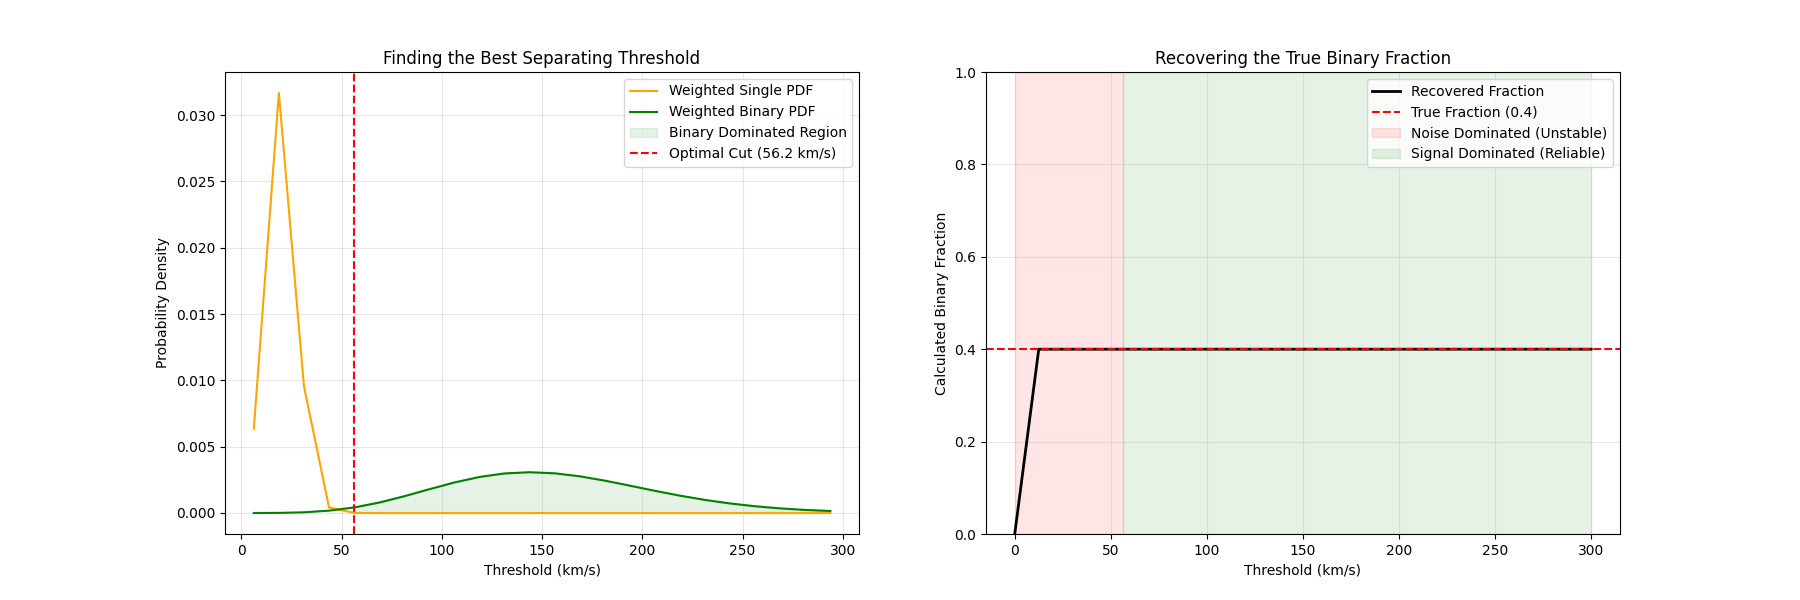

In [8]:
# --- Assuming 'surv_single', 'surv_binary', 'f_obs_t', and 'thresholds' exist from previous step ---

# 1. Calculate PDFs (Numerical Derivative of Survival Function)
# PDF ~ - (change in Survival) / (change in t)
dt = np.diff(thresholds)
pdf_single = -np.diff(surv_single) / dt
pdf_binary = -np.diff(surv_binary) / dt
mid_points = thresholds[:-1] + np.diff(thresholds)/2

# 2. Find the Intersection (Optimal Separator)
# We look for where (1-F)*PDF_s crosses F*PDF_b
weighted_pdf_s = (1 - f_true_binary) * pdf_single
weighted_pdf_b = f_true_binary * pdf_binary

# Find index where Binary curve becomes higher than Single curve
# (using argmax on the boolean array finds the first 'True')
idx_cross = np.argmax(weighted_pdf_b > weighted_pdf_s)
t_optimal = mid_points[idx_cross]

print(f"Optimal Separating Threshold: {t_optimal:.2f} km/s")

# 3. Recover the True Fraction (The 'Plateau' Method)
# Equation: F_rec = (f_obs - S_single) / (S_binary - S_single)
# We add a tiny epsilon to denominator to avoid division by zero at t=0
denominator = surv_binary - surv_single
epsilon = 1e-10
f_recovered = (f_obs_t - surv_single) / (denominator + epsilon)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: The Classifier View (Weighted PDFs)
ax1.plot(mid_points, weighted_pdf_s, color='orange', label='Weighted Single PDF')
ax1.plot(mid_points, weighted_pdf_b, color='green', label='Weighted Binary PDF')
ax1.fill_between(mid_points, weighted_pdf_s, weighted_pdf_b, 
                 where=(weighted_pdf_b > weighted_pdf_s), 
                 color='green', alpha=0.1, label='Binary Dominated Region')
ax1.axvline(t_optimal, color='red', linestyle='--', label=f'Optimal Cut ({t_optimal:.1f} km/s)')
ax1.set_title("Finding the Best Separating Threshold")
ax1.set_xlabel("Threshold (km/s)")
ax1.set_ylabel("Probability Density")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: The Estimator View (Recovered Fraction)
ax2.plot(thresholds, f_recovered, 'k-', lw=2, label='Recovered Fraction')
ax2.axhline(f_true_binary, color='red', linestyle='--', label=f'True Fraction ({f_true_binary})')

# Highlight the useful region
ax2.axvspan(0, t_optimal, color='red', alpha=0.1, label='Noise Dominated (Unstable)')
ax2.axvspan(t_optimal, thresholds.max(), color='green', alpha=0.1, label='Signal Dominated (Reliable)')

ax2.set_ylim(0, 1.0)
ax2.set_title("Recovering the True Binary Fraction")
ax2.set_xlabel("Threshold (km/s)")
ax2.set_ylabel("Calculated Binary Fraction")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Trying to now fit the model to real data with errors and get the threshold from there

1. Pre-computing Standard Curve...


<>:152: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:184: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:200: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:152: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:184: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:200: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/kk/80281pd541g60nptm46fy9hh0000gn/T/ipykernel_19763/19384

2. Extracting Real Data (C IV 5808-5812)...
3. Fitting Models...

Optimal Threshold: 45.50 km/s


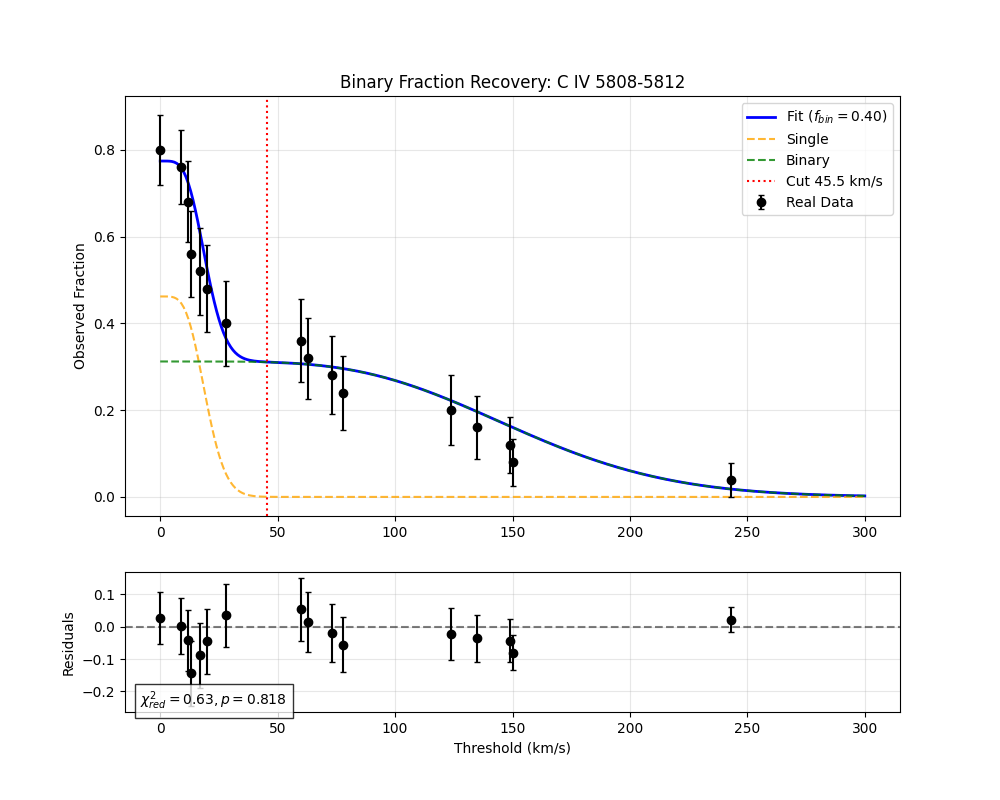

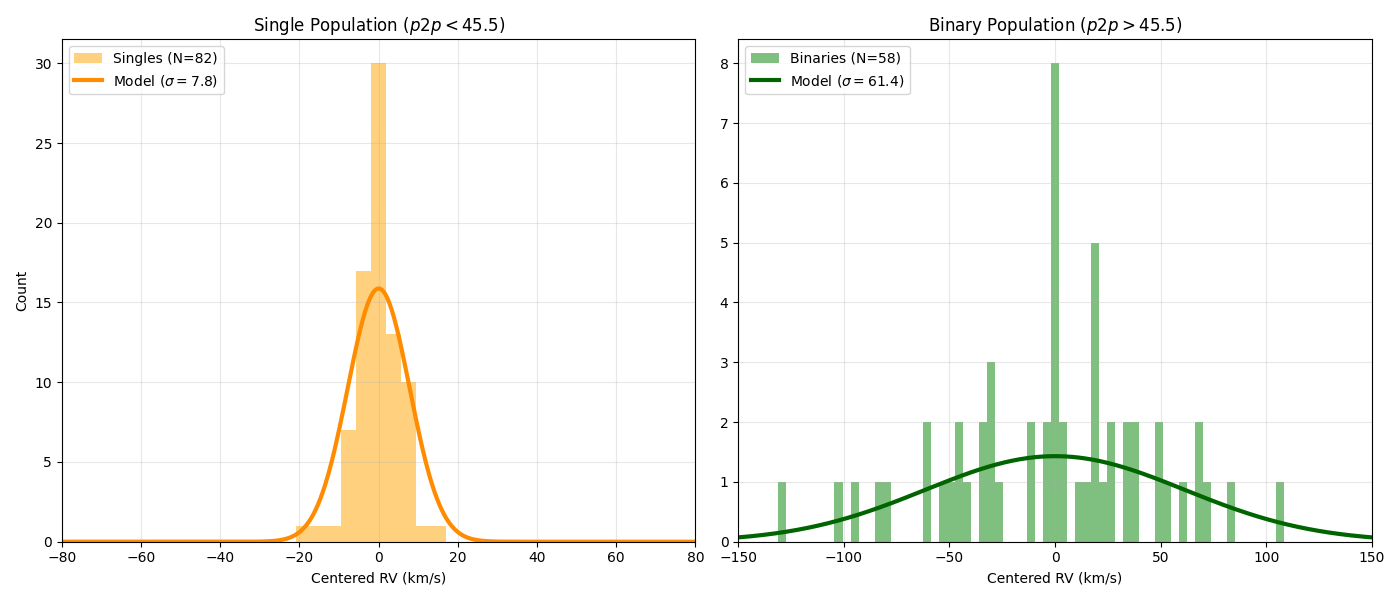

In [9]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from scipy.stats import norm, chi2
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from multiprocess import Pool, cpu_count 

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
TARGET_LINE = 'C IV 5808-5812'
# TARGET_LINE = 'He II 4686'
NSIGMA_DETECT = 4.0
N_EPOCHS_MODEL = 6 

try:
    with open(SETTINGS_PATH, "r") as f: SETTINGS = json.load(f)
    STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
except: STAR_CFG = {}

# ============================================================
# 2. PARALLEL MATH ENGINE
# ============================================================
def _worker_calc_survival_std(t):
    n = N_EPOCHS_MODEL; sigma = 1.0
    if t <= 0: return 1.0
    def pdf_integrand(z, w): return (norm.pdf(z) * norm.pdf(z + w) * (norm.cdf(z + w) - norm.cdf(z)) ** (n - 2))
    def outer_integrand(w): return quad(pdf_integrand, -np.inf, np.inf, args=(w,))[0]
    return max(0.0, min(1.0, 1 - (n * (n - 1) / sigma) * quad(outer_integrand, 0, t)[0]))

def precompute_standard_curve():
    print("1. Pre-computing Standard Curve...")
    t_grid = np.linspace(0, 10, 100) 
    try:
        with Pool(max(1, cpu_count() - 1)) as p: y_grid = p.map(_worker_calc_survival_std, t_grid)
    except: y_grid = [_worker_calc_survival_std(t) for t in t_grid]
    return interp1d(t_grid, y_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

STANDARD_SURVIVAL_FUNC = precompute_standard_curve()

# ============================================================
# 3. MODELS & EXTRACTION
# ============================================================
def model_raw(t, s_s, s_b, f):
    return (1-f)*STANDARD_SURVIVAL_FUNC(t/s_s) + f*STANDARD_SURVIVAL_FUNC(t/s_b)

def model_sig(t, s_s, s_b, f, amp):
    return amp * model_raw(t, s_s, s_b, f)

def extract_data(line_key):
    print(f"2. Extracting Real Data ({line_key})...")
    names = specs.star_names if 'specs' in globals() else list(STAR_CFG.keys())
    p2p_vals, p2p_errs, star_data = [], [], []
    for sname in names:
        try:
            star = obs.load_star_instance(sname, to_print=False)
            eps = star.get_all_epoch_numbers()
        except: continue
        r, e = [], []
        for ep in eps:
            if ep in STAR_CFG.get(sname, {}).get("skip_epochs", []): continue
            try:
                p = star.load_property("RVs", ep, "COMBINED")
                if not p or line_key not in p: continue
                v = p[line_key].get("full_RV") if isinstance(p[line_key], dict) else p[line_key].item().get("full_RV")
                er = p[line_key].get("full_RV_err") if isinstance(p[line_key], dict) else p[line_key].item().get("full_RV_err")
                if v and np.isfinite(float(v)): 
                    r.append(float(v)); e.append(float(er) if er else 10.0)
            except: continue
        if len(r) >= 2:
            r=np.array(r); e=np.array(e)
            i_max, i_min = np.argmax(r), np.argmin(r)
            val = np.abs(r[i_max]-r[i_min])
            er_val = np.sqrt(e[i_max]**2 + e[i_min]**2)
            p2p_vals.append(val); p2p_errs.append(er_val)
            star_data.append({'p2p': val, 'err': er_val, 'rvs_centered': r - np.median(r)})

    return np.array(p2p_vals), np.array(p2p_errs), star_data

# ============================================================
# 4. EXECUTION
# ============================================================
p2p, p2p_err, star_data = extract_data(TARGET_LINE)
N = len(p2p)

if N > 10:
    t_full = np.arange(0, 301, 1)
    raw_frac = np.array([np.sum(p2p > t)/N for t in t_full])
    is_sig = (p2p - NSIGMA_DETECT * p2p_err) > 0
    f_obs = np.array([np.sum(is_sig & (p2p > t))/N for t in t_full])
    sig_err = np.sqrt(f_obs * (1 - f_obs) / N) + 1e-4

    diffs = np.diff(f_obs, prepend=-999)
    mask = diffs != 0
    t_dots, f_dots, e_dots = t_full[mask], f_obs[mask], sig_err[mask]

    print("3. Fitting Models...")
    popt_raw, _ = curve_fit(model_raw, t_full, raw_frac, p0=[10, 40, 0.4], bounds=([0.1, 5, 0], [50, 300, 1]))
    p0_sig = [popt_raw[0], popt_raw[1], popt_raw[2], 0.8]
    popt_sig, pcov = curve_fit(model_sig, t_full, f_obs, sigma=sig_err, p0=p0_sig, bounds=([0.1, 5, 0, 0], [100, 300, 1, 1]))
    
    sig_s, sig_b, f_rec, amp = popt_sig
    
    # Threshold Recovery
    surv_s = STANDARD_SURVIVAL_FUNC(t_full / sig_s)
    surv_b = STANDARD_SURVIVAL_FUNC(t_full / sig_b)
    dt = np.diff(t_full)
    pdf_s = -np.diff(surv_s) / dt
    pdf_b = -np.diff(surv_b) / dt
    mid_points = t_full[:-1] + dt/2
    w_pdf_s = (1 - f_rec) * pdf_s
    w_pdf_b = f_rec * pdf_b
    idx_cross = np.argmax(w_pdf_b > w_pdf_s)
    t_optimal = mid_points[idx_cross]
    print(f"\nOptimal Threshold: {t_optimal:.2f} km/s")

    # ============================================================
    # FIGURE 1: FIT & RESIDUALS
    # ============================================================
    fig1 = plt.figure(figsize=(10, 8))
    gs = fig1.add_gridspec(2, 1, height_ratios=[3, 1])
    ax1 = fig1.add_subplot(gs[0])
    ax2 = fig1.add_subplot(gs[1], sharex=ax1)

    ax1.errorbar(t_dots, f_dots, yerr=e_dots, fmt='ko', capsize=2, label='Real Data', zorder=5)
    ax1.plot(t_full, model_sig(t_full, *popt_sig), 'b-', lw=2, label=f'Fit ($f_{{bin}}={f_rec:.2f}$)')
    ax1.plot(t_full, amp*(1-f_rec)*surv_s, '--', color='orange', alpha=0.8, label='Single')
    ax1.plot(t_full, amp*f_rec*surv_b, '--', color='green', alpha=0.8, label='Binary')
    ax1.axvline(t_optimal, color='red', linestyle=':', label=f'Cut {t_optimal:.1f} km/s')
    ax1.set_ylabel("Observed Fraction")
    ax1.set_title(f"Binary Fraction Recovery: {TARGET_LINE}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    model_at_dots = model_sig(t_dots, *popt_sig)
    res = f_dots - model_at_dots
    chisq = np.sum((res/e_dots)**2)
    dof = max(1, len(t_dots)-4)
    chisq_red = chisq/dof; p_val = chi2.sf(chisq, dof)

    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.errorbar(t_dots, res, yerr=e_dots, fmt='ko', capsize=2)
    ax2.set_xlabel("Threshold (km/s)")
    ax2.set_ylabel("Residuals")
    ax2.text(0.02, 0.05, f"$\chi^2_{{red}}={chisq_red:.2f}, p={p_val:.3g}$", transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.8))
    ax2.grid(True, alpha=0.3)
    plt.show()

    # ============================================================
    # FIGURE 2: SCALED HISTOGRAMS (COUNTS)
    # ============================================================
    fig2, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Theoretical Models (Gaussian PDFs)
    x_rv = np.linspace(-150, 150, 500)
    pdf_s_curve = norm.pdf(x_rv, 0, sig_s)
    pdf_b_curve = norm.pdf(x_rv, 0, sig_b)
    
    # 2. Classification & Counts
    rvs_s, rvs_b = [], []
    for s in star_data:
        is_sig_star = (s['p2p'] - NSIGMA_DETECT * s['err']) > 0
        if is_sig_star and (s['p2p'] > t_optimal): rvs_b.extend(s['rvs_centered'])
        else: rvs_s.extend(s['rvs_centered'])

    bins = np.linspace(-150, 150, 80)
    bin_width = bins[1] - bins[0]

    # --- PLOT LEFT: SINGLES ---
    if len(rvs_s) > 0:
        # Plot Histogram (Counts)
        ax_s.hist(rvs_s, bins=bins, color='orange', alpha=0.5, label=f'Singles (N={len(rvs_s)})')
        
        # Scale Curve: Area of histogram = N * bin_width
        # PDF integrates to 1. So we multiply PDF by (N * bin_width)
        scale_factor_s = len(rvs_s) * bin_width
        ax_s.plot(x_rv, pdf_s_curve * scale_factor_s, color='darkorange', lw=3, label=f'Model ($\sigma={sig_s:.1f}$)')
    
    ax_s.set_title(f"Single Population ($p2p < {t_optimal:.1f}$)")
    ax_s.set_xlabel("Centered RV (km/s)")
    ax_s.set_ylabel("Count")
    ax_s.legend(loc='upper left')
    ax_s.grid(True, alpha=0.3)
    ax_s.set_xlim(-80, 80)

    # --- PLOT RIGHT: BINARIES ---
    if len(rvs_b) > 0:
        # Plot Histogram (Counts)
        ax_b.hist(rvs_b, bins=bins, color='green', alpha=0.5, label=f'Binaries (N={len(rvs_b)})')
        
        # Scale Curve
        scale_factor_b = len(rvs_b) * bin_width
        ax_b.plot(x_rv, pdf_b_curve * scale_factor_b, color='darkgreen', lw=3, label=f'Model ($\sigma={sig_b:.1f}$)')

    ax_b.set_title(f"Binary Population ($p2p > {t_optimal:.1f}$)")
    ax_b.set_xlabel("Centered RV (km/s)")
    ax_b.legend(loc='upper left')
    ax_b.grid(True, alpha=0.3)
    ax_b.set_xlim(-150, 150)
    
    plt.tight_layout()
    plt.show()

else: print("Not enough data.")

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from scipy.stats import norm, chi2
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from multiprocess import Pool, cpu_count 

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
TARGET_LINE = 'C IV 5808-5812'
NSIGMA_DETECT = 4.0
N_EPOCHS_MODEL = 6 

# --- POST-FIT ADJUSTMENT ---
N_PRIOR_BINARIES = 3

try:
    with open(SETTINGS_PATH, "r") as f: SETTINGS = json.load(f)
    STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
except: STAR_CFG = {}

# ============================================================
# 2. PARALLEL MATH ENGINE
# ============================================================
def _worker_calc_survival_std(t):
    n = N_EPOCHS_MODEL; sigma = 1.0
    if t <= 0: return 1.0
    def pdf_integrand(z, w): return (norm.pdf(z) * norm.pdf(z + w) * (norm.cdf(z + w) - norm.cdf(z)) ** (n - 2))
    def outer_integrand(w): return quad(pdf_integrand, -np.inf, np.inf, args=(w,))[0]
    return max(0.0, min(1.0, 1 - (n * (n - 1) / sigma) * quad(outer_integrand, 0, t)[0]))

def precompute_standard_curve():
    print("1. Pre-computing Standard Curve...")
    t_grid = np.linspace(0, 10, 100) 
    try:
        with Pool(max(1, cpu_count() - 1)) as p: y_grid = p.map(_worker_calc_survival_std, t_grid)
    except: y_grid = [_worker_calc_survival_std(t) for t in t_grid]
    return interp1d(t_grid, y_grid, kind='cubic', bounds_error=False, fill_value=(1.0, 0.0))

STANDARD_SURVIVAL_FUNC = precompute_standard_curve()

# ============================================================
# 3. MODELS & EXTRACTION
# ============================================================
def model_raw(t, s_s, s_b, f):
    return (1-f)*STANDARD_SURVIVAL_FUNC(t/s_s) + f*STANDARD_SURVIVAL_FUNC(t/s_b)

def model_sig(t, s_s, s_b, f, amp):
    return amp * model_raw(t, s_s, s_b, f)

def extract_data(line_key):
    print(f"2. Extracting Real Data ({line_key})...")
    names = specs.star_names if 'specs' in globals() else list(STAR_CFG.keys())
    p2p_vals, p2p_errs, star_data = [], [], []
    for sname in names:
        try:
            star = obs.load_star_instance(sname, to_print=False)
            eps = star.get_all_epoch_numbers()
        except: continue
        r, e = [], []
        for ep in eps:
            if ep in STAR_CFG.get(sname, {}).get("skip_epochs", []): continue
            try:
                p = star.load_property("RVs", ep, "COMBINED")
                if not p or line_key not in p: continue
                v = p[line_key].get("full_RV") if isinstance(p[line_key], dict) else p[line_key].item().get("full_RV")
                er = p[line_key].get("full_RV_err") if isinstance(p[line_key], dict) else p[line_key].item().get("full_RV_err")
                if v and np.isfinite(float(v)): 
                    r.append(float(v)); e.append(float(er) if er else 10.0)
            except: continue
        if len(r) >= 2:
            r=np.array(r); e=np.array(e)
            i_max, i_min = np.argmax(r), np.argmin(r)
            val = np.abs(r[i_max]-r[i_min])
            er_val = np.sqrt(e[i_max]**2 + e[i_min]**2)
            p2p_vals.append(val); p2p_errs.append(er_val)
            star_data.append({'p2p': val, 'err': er_val, 'rvs_centered': r - np.median(r)})

    return np.array(p2p_vals), np.array(p2p_errs), star_data

# ============================================================
# 4. EXECUTION
# ============================================================
p2p, p2p_err, star_data = extract_data(TARGET_LINE)
N = len(p2p)

if N > 10:
    t_full = np.arange(0, 301, 1)
    
    # --- STEP A: RAW SAMPLE DATA ---
    raw_frac = np.array([np.sum(p2p > t)/N for t in t_full])
    is_sig = (p2p - NSIGMA_DETECT * p2p_err) > 0
    f_obs_sample = np.array([np.sum(is_sig & (p2p > t))/N for t in t_full])
    sig_err_sample = np.sqrt(f_obs_sample * (1 - f_obs_sample) / N) + 1e-4

    # --- STEP B: FIT THE SAMPLE ONLY ---
    print("3. Fitting Sample Model...")
    popt_raw, _ = curve_fit(model_raw, t_full, raw_frac, p0=[10, 40, 0.4], bounds=([0.1, 5, 0], [50, 300, 1]))
    p0_sig = [popt_raw[0], popt_raw[1], popt_raw[2], 0.8]
    popt_sig, pcov = curve_fit(model_sig, t_full, f_obs_sample, sigma=sig_err_sample, p0=p0_sig, bounds=([0.1, 5, 0, 0], [100, 300, 1, 1]))
    
    sig_s, sig_b, f_sample, amp = popt_sig
    
    # --- STEP C: RISE THE DOTS (GLOBAL CALCULATION) ---
    N_global = N + N_PRIOR_BINARIES
    
    # 1. Update the Data Arrays (Dots)
    # We add 3 to the count (numerator) and 3 to N (denominator)
    f_obs_global = (f_obs_sample * N + N_PRIOR_BINARIES) / N_global
    
    # 2. Update the Errors (New Binomial)
    sig_err_global = np.sqrt(f_obs_global * (1 - f_obs_global) / N_global) + 1e-4

    # 3. Update the Model Fraction
    f_global = (f_sample * N + N_PRIOR_BINARIES) / N_global
    
    print(f"\n--- RESULTS ({TARGET_LINE}) ---")
    print(f"  Sample Fit: f={f_sample:.3f} (N={N})")
    print(f"  Global Calc: f={f_global:.3f} (N={N_global})")

    # Threshold Recovery (Using Global Fraction for Physics)
    surv_s = STANDARD_SURVIVAL_FUNC(t_full / sig_s)
    surv_b = STANDARD_SURVIVAL_FUNC(t_full / sig_b)
    dt = np.diff(t_full)
    pdf_s = -np.diff(surv_s) / dt
    pdf_b = -np.diff(surv_b) / dt
    mid_points = t_full[:-1] + dt/2
    w_pdf_s = (1 - f_global) * pdf_s
    w_pdf_b = f_global * pdf_b
    idx_cross = np.argmax(w_pdf_b > w_pdf_s)
    t_optimal = mid_points[idx_cross]
    print(f"  Optimal Cut: {t_optimal:.2f} km/s")

    # Get Change Points for Global Curve
    diffs = np.diff(f_obs_global, prepend=-999)
    mask = diffs != 0
    t_dots, f_dots, e_dots = t_full[mask], f_obs_global[mask], sig_err_global[mask]

    # ============================================================
    # FIGURE 1: GLOBAL PLOT
    # ============================================================
    fig1 = plt.figure(figsize=(10, 8))
    gs = fig1.add_gridspec(2, 1, height_ratios=[3, 1])
    ax1 = fig1.add_subplot(gs[0])
    ax2 = fig1.add_subplot(gs[1], sharex=ax1)

    # A. Plot "Raised" Dots
    ax1.errorbar(t_dots, f_dots, yerr=e_dots, fmt='ko', capsize=2, label='Global Data (Raised)', zorder=5)
    
    # B. Plot "Global" Model
    # We use sample Sigmas/Amp, but Global Fraction
    y_model_global = model_sig(t_full, sig_s, sig_b, f_global, amp)
    
    ax1.plot(t_full, y_model_global, 'b-', lw=2, label=f'Global Model ($f_{{bin}}={f_global:.2f}$)')
    ax1.plot(t_full, amp*(1-f_global)*surv_s, '--', color='orange', alpha=0.8, label='Single')
    ax1.plot(t_full, amp*f_global*surv_b, '--', color='green', alpha=0.8, label='Binary')
    ax1.axvline(t_optimal, color='red', linestyle=':', label=f'Cut {t_optimal:.1f} km/s')
    
    ax1.set_ylabel("Observed Fraction (Global)")
    ax1.set_title(f"Binary Fraction Recovery: {TARGET_LINE} (+{N_PRIOR_BINARIES} priors)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Residuals (Global Data vs Global Model)
    # We calculate residuals based on the "raised" state
    y_model_at_dots = model_sig(t_dots, sig_s, sig_b, f_global, amp)
    res = f_dots - y_model_at_dots
    
    # Recalculate chi2 for this "global" comparison
    chisq = np.sum((res/e_dots)**2)
    dof = max(1, len(t_dots)-4)
    chisq_red = chisq/dof
    p_val = chi2.sf(chisq, dof)

    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.errorbar(t_dots, res, yerr=e_dots, fmt='ko', capsize=2)
    ax2.set_xlabel("Threshold (km/s)")
    ax2.set_ylabel("Residuals")
    ax2.text(0.02, 0.05, f"$\chi^2_{{red}}={chisq_red:.2f}$", transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.8))
    ax2.grid(True, alpha=0.3)
    plt.show()

    # ============================================================
    # FIGURE 2: SAMPLE HISTOGRAMS
    # ============================================================
    # Note: We still plot the Sample RVs because we don't have RVs for the 3 priors.
    fig2, (ax_s, ax_b) = plt.subplots(1, 2, figsize=(14, 6))

    x_rv = np.linspace(-150, 150, 500)
    pdf_s_curve = norm.pdf(x_rv, 0, sig_s)
    pdf_b_curve = norm.pdf(x_rv, 0, sig_b)
    
    rvs_s, rvs_b = [], []
    for s in star_data:
        is_sig_star = (s['p2p'] - NSIGMA_DETECT * s['err']) > 0
        if is_sig_star and (s['p2p'] > t_optimal): rvs_b.extend(s['rvs_centered'])
        else: rvs_s.extend(s['rvs_centered'])

    bins = np.linspace(-150, 150, 80)
    bin_width = bins[1] - bins[0]

    # SINGLES
    if len(rvs_s) > 0:
        ax_s.hist(rvs_s, bins=bins, color='orange', alpha=0.5, label=f'Singles (Sample N={len(rvs_s)})')
        scale_factor_s = len(rvs_s) * bin_width
        ax_s.plot(x_rv, pdf_s_curve * scale_factor_s, color='darkorange', lw=3, label=f'Model ($\sigma={sig_s:.1f}$)')
    
    ax_s.set_title(f"Single Population (Sample Only)")
    ax_s.set_xlabel("Centered RV (km/s)")
    ax_s.set_ylabel("Count")
    ax_s.legend(loc='upper left')
    ax_s.grid(True, alpha=0.3)
    ax_s.set_xlim(-80, 80)

    # BINARIES
    if len(rvs_b) > 0:
        ax_b.hist(rvs_b, bins=bins, color='green', alpha=0.5, label=f'Binaries (Sample N={len(rvs_b)})')
        scale_factor_b = len(rvs_b) * bin_width
        ax_b.plot(x_rv, pdf_b_curve * scale_factor_b, color='darkgreen', lw=3, label=f'Model ($\sigma={sig_b:.1f}$)')

    ax_b.set_title(f"Binary Population (Sample Only)")
    ax_b.set_xlabel("Centered RV (km/s)")
    ax_b.legend(loc='upper left')
    ax_b.grid(True, alpha=0.3)
    ax_b.set_xlim(-150, 150)
    
    plt.tight_layout()
    plt.show()

else: print("Not enough data.")

## using LMC WC4 14-10 template from POwR to simulate SB1 and calc minimum SNR needed for 3km/s certainty for each emssion line

In [ ]:
S2Ns = [1,2,3,4,5,7,10,12,14,17,20,30,40,50,100,120,150]
emission_lines = [[[3350.,3500.]],[[4560.,4800.]],[[5700.,6000.]],[[6460.,6650.]],[[7500.,7900.]],[[8100.,8400.]],[[9266.,9475]],[[3115,3230]],[[3645,3730]],[[3788,3863]],[[4415,4520]],[[5246,5326]],[[5380,5535]],[[6960,7155]],[[8800,8915]]]

In [ ]:
import multiprocess as mp
import numpy as np
# from your_simulation_module import sc  # Replace with your actual import

def process_pair(params):
    """
    Process a single pair of S2N and CrossCorRangeA.
    """
    S2N, CrossCorRangeA = params
    sim = sc(S2N=S2N, lamB=3100., lamR=9990.)
    sim.run_simulation(overwrite=False)

    temp_path = 'Data/LMC WC Temaplates/lmc-wc_14-10_line.txt'
    template_wave, template_flux = sim.load_two_column_file(temp_path)

    file_name = f'CCRA_{CrossCorRangeA}_RVs'
    try:
        results = sim.load_property(file_name)
    except:
        results = np.array(sim.run_CCF(template_wave, template_flux, CrossCorRangeA=CrossCorRangeA), dtype='float')
        sim.save_property(file_name,results)
    sigma = np.std(results[:, 0])
    return CrossCorRangeA, np.array([S2N, sigma])

def run_multiprocessing(S2Ns, emission_lines):
    # Create pairs of S2Ns and CrossCorRangeA
    params = [(S2N, line) for line in emission_lines for S2N in S2Ns]
    
    # Initialize multiprocessing pool
    with mp.Pool(processes=mp.cpu_count()) as pool:
        results = pool.map(process_pair, params)
    
    # Organize results into the desired format
    total_results = {}
    for line in emission_lines:
        total_results[str(line)] = [result[1] for result in results if result[0] == line]
    
    return total_results

# Running the multiprocessing code in Jupyter
if __name__ == "__main__":
    # S2Ns = [10, 20, 50, 100]  # Example S2N values
    # emission_lines = ['line1', 'line2', 'line3']  # Replace with actual lines
    
    # Run multiprocessing and collect results
    total_results = run_multiprocessing(S2Ns, emission_lines)
    print(total_results)


In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_template_with_snr_improved(template_wave, template_flux, total_results, threshold=3.0):
    """
    Plots the template spectrum, highlights each emission line, and annotates the required SNR
    for each line to achieve less than the given threshold in RV variation.

    Parameters:
        template_wave (array): Wavelength array of the template.
        template_flux (array): Flux array of the template.
        total_results (dict): Dictionary containing results for each emission line.
                              Keys are emission line ranges (e.g., 'start-end'),
                              values are lists of [S2N, sigma] pairs.
        threshold (float): The threshold for RV variation in km/s. Defaults to 3.0.
    """
    plt.figure(figsize=(14, 8))

    # Plot the template spectrum
    plt.plot(template_wave, template_flux, color='black', linewidth=1.5)

    # Keep track of y-coordinates to avoid overlap
    used_positions = []

    # Iterate through each emission line and annotate the required SNR
    for emission_line, results in total_results.items():
        # Convert results to NumPy array for easier manipulation
        results_array = np.array(results)
        S2Ns, sigmas = results_array[:, 0], results_array[:, 1]

        # Find the minimum SNR where the sigma is below the threshold
        valid_indices = np.where(sigmas < threshold)[0]
        if valid_indices.size > 0:
            required_snr = S2Ns[valid_indices[0]]
        else:
            required_snr = "N/A"

        # Highlight the emission line
        emission_start, emission_end = map(float, re.findall(r"[-+]?\d*\.\d+|\d+", emission_line))
        plt.axvspan(emission_start, emission_end, color='red', alpha=0.3)
        mid_point = (emission_start + emission_end) / 2

        # Determine y-coordinate for the text box
        y_position = max(template_flux) * 0.9
        while y_position in used_positions:
            y_position -= max(template_flux) * 0.05  # Adjust to avoid overlap
        used_positions.append(y_position)

        # Annotate the SNR
        plt.text(mid_point, y_position, f"SNR: {required_snr}", 
                 color='blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.8))

    # Add title, labels, and grid
    plt.title(f"Template Spectrum with Emission Lines and Required SNR for less than {threshold} km/s variability", fontsize=16)
    plt.xlabel("Wavelength (Å)", fontsize=14)
    plt.ylabel("Normalized Flux", fontsize=14)
    
    # Improve X-axis resolution
    plt.xticks(np.arange(min(template_wave)+1, max(template_wave), 250))  # 20 ticks for better resolution
    plt.grid(alpha=0.5)
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
# Replace these with your actual data
sim = sc()
temp_path = 'Data/LMC WC Temaplates/lmc-wc_14-10_line.txt'
template_wave, template_flux = sim.load_two_column_file(temp_path)
plot_template_with_snr_improved(template_wave, template_flux, total_results)


# Combing Spectra

In [ ]:
%matplotlib widget
obs = obsm()
star_name = specs.star_names[20]
star = obs.load_star_instance(star_name)
# star.list_available_properties()
# data = star.load_property('aligment_data',3,'COMBINED2')
# star.combine_fits_files(3)

In [ ]:
text = ''
for star_name in specs.star_names:
    text += f'{star_name}\n'


print(text)

In [ ]:
for star_name in specs.star_names[6:7]:
    star = obs.load_star_instance(star_name)
    epcoh_nums = [int(key[-1]) for key in specs.obs_file_names[star_name].keys()]
    for epoch_num in epcoh_nums:
        star.combine_fits_files(epoch_num=epoch_num, overwrite = True, backup = True, save = True)
        print(f'finished epoch{epoch_num}')

In [ ]:
%matplotlib widget
star_name = specs.star_names[5]
star = obs.load_star_instance(star_name)
star.plot_spectra(epoch_nums=4,bands = ['UVB','VIS','NIR'])
# star.plot_spectra(2)
# star.plot_spectra(3)
# star.plot_spectra(4)
# star.plot_spectra(5)
# star.plot_spectra(6)
# star.plot_spectra(7)

# Printing data on stars

In [ ]:
obs = obsm()

In [ ]:
star_name = specs.star_names[17]
print(star_name)
star = obs.load_star_instance(star_name)
twoD = star.load_2D_observation(3,'UVB')
twoD.print_file_info()

In [ ]:
data = star.load_property('RVs',5,'COMBINED')
print(data)

In [ ]:
data = []
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name)
    data.append([star_name, star.spectral_type, star.BAT_ID])

df = pd.DataFrame(data, columns=["Star Name", "Spectral Type", "BAT99 ID"])
print(df)

# using astroquery to get data on stars

In [ ]:
from astroquery.vizier import Vizier

# Check catalog metadata
metadata = Vizier.get_catalogs("J/ApJ/931/157")
print(metadata)
for table in metadata:
    print(table)
    print(f"Table: {table['Name']}")
    print(f"Columns: {table.colnames}")


In [ ]:
viz_res = viz.query_object(object_name = 'BAT99-52', catalog='J/ApJ/931/157')
print(viz_res)

In [ ]:
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

# Initialize results table
results = []

# Example star list from specs
BAT99_star_names = {}
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name)
    BAT99_star_names[star_name] = f'BAT99 {star.BAT_ID}'

# Vizier setup
viz = Vizier(columns=["SpType"])
vizier_catalogs = ["J/ApJ/863/181",'J/ApJ/931/157','J/ApJ/888/54','J/AJ/158/192']  # Galactic Wolf-Rayet stars catalog

# Add necessary fields to SIMBAD query
simbad = Simbad()
simbad.add_votable_fields("sptype", "ra", "dec")  # Add necessary fields

# Iterate over star names
for star_name in specs.star_names:
    star_result = {"Star Name": star_name,"BAT99 name": BAT99_star_names[star_name], "SIMBAD": None}
    star_name = BAT99_star_names[star_name]
    # Query SIMBAD
    try:
        sim_res = simbad.query_object(star_name)
        if sim_res is not None and "SP_TYPE" in sim_res.colnames:
            star_result["SIMBAD"] = sim_res["SP_TYPE"][0]  # Spectral type
    except Exception as e:
        print(f"SIMBAD query failed for {star_name}: {e}")

    # Query Vizier by name, then fallback to coordinates
    for vizier_catalog in vizier_catalogs:
        try:
            viz_res = viz.query_object(star_name, catalog=vizier_catalog)
            if viz_res is None or len(viz_res) == 0:
                # print('BAT99-' + str(star_name.split(' ')[1]))
                viz_res = viz.query_object('BAT99-' + str(star_name.split(' ')[1]), catalog=vizier_catalog)
                print(f"Vizier query by name failed for {star_name} in catalog {vizier_catalog}, attempting by coordinates...")
                # Fetch coordinates from SIMBAD
                if sim_res is not None:
                    ra, dec = sim_res["RA"][0], sim_res["DEC"][0]
                    coords = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
                    if star_name == 'BAT99 52':
                        print(f'RA: {ra}')
                        print(f'DEC: {dec}')
                        print(f'coords: {coords}')
                    viz_res = viz.query_region(coords, radius=5000 * u.arcsec, catalog=vizier_catalog)
            if viz_res is not None and len(viz_res) > 0:
                table = viz_res[0]
                if "SpType" in table.colnames:
                    star_result[vizier_catalog] = table["SpType"][0]  # Spectral type
            else:
                print(f'Didnt find {star_name} in vizier catalog {vizier_catalog}')
        except Exception as e:
            print(f"Vizier query failed for {star_name}: {e}")

    # Append results
    results.append(star_result)

# Convert results to DataFrame
df = pd.DataFrame(results)

# Display table
from tabulate import tabulate
print(tabulate(df, headers="keys", tablefmt="pretty"))


# Extracting data form fits files 

## X-SHOOTER

In [ ]:
obs = obsm()
star_name = specs.star_names[0]
star = obs.load_star_instance(star_name)

In [ ]:
fits_file = star.load_observation(1,'NIR')
wave = fits_file.data['WAVE'][0]
reduced_flux = fits_file.data['FLUX_REDUCED'][0]
print(len(wave))
print(len(reduced_flux))
print(reduced_flux)

In [ ]:
%matplotlib widget
plt.clf()
plt.plot(wave,reduced_flux)
plt.show()

In [ ]:
test = fits_file.data

In [ ]:
print(test)

In [ ]:
fits_file.print_file_info()

In [ ]:
print(star_name)
data = star.load_property('normalized_flux',1,'COMBINED')
flux = data['normalized_flux']
wave = data['wavelengths']
for f, w in zip(flux, wave):
    print(f"{w:.17e}  {f:.55e}")      # 17‑digit scientific notation


### Barycentric table for stars vs epochs

In [ ]:
results = {}
band = 'NIR'
for star_name in specs.star_names:
    if star_name not in results:
        results[star_name] = {}
    star = obs.load_star_instance(star_name,to_print = False)
    epochs = star.get_all_epoch_numbers()
    for epoch_num in epochs:
        if epoch_num not in results[star_name]:
            results[star_name][epoch_num] = []
        fits_file = star.load_observation(epoch_num,band)
        bary = fits_file.header['ESO QC VRAD BARYCOR']
        results[star_name][epoch_num].append(bary)

In [ ]:
import pandas as pd

# Flatten the results dict into records
records = []
for star_name, epochs in results.items():
    for epoch_num, bary_list in epochs.items():
        bary = bary_list[0] if bary_list else None
        records.append((star_name, epoch_num, bary))

# Create the DataFrame
df = pd.DataFrame(records, columns=["Star", "Epoch", "Barycentric_Velocity_kms"])

# Pivot: wide format
df_wide = df.pivot(index="Star", columns="Epoch", values="Barycentric_Velocity_kms")

# ✅ Preserve star order based on `results` dict
df_wide = df_wide.loc[list(results.keys())]

# ✅ Preserve epoch order based on first occurrence in your dict
# (collect all unique epoch numbers in order of appearance)
epoch_order = []
for star_epochs in results.values():
    for ep in star_epochs:
        if ep not in epoch_order:
            epoch_order.append(ep)
df_wide = df_wide[epoch_order]

# Optional: clean up display
df_wide.columns.name = None  # remove "Epoch" label
df_wide.index.name = None    # remove "Star" label
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 100)

# Show the final ordered table
print(df_wide)


In [ ]:
star.star_name
RVs = star.load_property('RVs',3,'COMBINED')
print(RVs['C IV 5808-5812'].item()['full_RV'])

## NRES

In [ ]:
star_name = 'WR17'
star = obs.load_star_instance(star_name)
fits_file = star.load_observation(1,1)
data = fits_file.data
print(data['wavelength'][0][30:40])